In [178]:
import sys

print(sys.executable)
print(sys.version)

g:\Android-Software-Trust\.venv\Scripts\python.exe
3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)]


In [179]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.3
NumPy version: 2.2.6


In [180]:
drebin_path = "../data/raw/drebin_dataset.csv"

drebin = pd.read_csv(drebin_path)

print("Dataset loaded successfully!")
print("Rows:", drebin.shape[0])
print("Columns:", drebin.shape[1])

Dataset loaded successfully!
Rows: 15036
Columns: 216


C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\1139072828.py:3: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  drebin = pd.read_csv(drebin_path)


In [181]:
# Basic structure of the DREBIN dataset

print("Shape:", drebin.shape)

print("\nColumn names:")
for i, col in enumerate(drebin.columns):
    print(i, "→", col)

Shape: (15036, 216)

Column names:
0 → transact
1 → onServiceConnected
2 → bindService
3 → attachInterface
4 → ServiceConnection
5 → android.os.Binder
6 → SEND_SMS
7 → Ljava.lang.Class.getCanonicalName
8 → Ljava.lang.Class.getMethods
9 → Ljava.lang.Class.cast
10 → Ljava.net.URLDecoder
11 → android.content.pm.Signature
12 → android.telephony.SmsManager
13 → READ_PHONE_STATE
14 → getBinder
15 → ClassLoader
16 → Landroid.content.Context.registerReceiver
17 → Ljava.lang.Class.getField
18 → Landroid.content.Context.unregisterReceiver
19 → GET_ACCOUNTS
20 → RECEIVE_SMS
21 → Ljava.lang.Class.getDeclaredField
22 → READ_SMS
23 → getCallingUid
24 → Ljavax.crypto.spec.SecretKeySpec
25 → android.intent.action.BOOT_COMPLETED
26 → USE_CREDENTIALS
27 → MANAGE_ACCOUNTS
28 → android.content.pm.PackageInfo
29 → KeySpec
30 → TelephonyManager.getLine1Number
31 → DexClassLoader
32 → HttpGet.init
33 → SecretKey
34 → Ljava.lang.Class.getMethod
35 → System.loadLibrary
36 → android.intent.action.SEND
37 → Ljav

In [182]:
print("\nData types:")
print(drebin.dtypes.value_counts())


Data types:
int64     214
object      2
Name: count, dtype: int64


In [183]:
print("\nPotential label columns:")
for col in drebin.columns:
    unique_count = drebin[col].nunique(dropna=False)
    
    if unique_count <= 20:
        print(f"{col}: {unique_count} unique values")


Potential label columns:
transact: 2 unique values
onServiceConnected: 2 unique values
bindService: 2 unique values
attachInterface: 2 unique values
ServiceConnection: 2 unique values
android.os.Binder: 2 unique values
SEND_SMS: 2 unique values
Ljava.lang.Class.getCanonicalName: 2 unique values
Ljava.lang.Class.getMethods: 2 unique values
Ljava.lang.Class.cast: 2 unique values
Ljava.net.URLDecoder: 2 unique values
android.content.pm.Signature: 2 unique values
android.telephony.SmsManager: 2 unique values
READ_PHONE_STATE: 2 unique values
getBinder: 2 unique values
ClassLoader: 2 unique values
Landroid.content.Context.registerReceiver: 2 unique values
Ljava.lang.Class.getField: 2 unique values
Landroid.content.Context.unregisterReceiver: 2 unique values
GET_ACCOUNTS: 2 unique values
RECEIVE_SMS: 2 unique values
Ljava.lang.Class.getDeclaredField: 2 unique values
READ_SMS: 2 unique values
getCallingUid: 2 unique values
Ljavax.crypto.spec.SecretKeySpec: 2 unique values
android.intent.acti

In [184]:
# Inspect the class/ground-truth label

print("Class values:")
print(drebin["class"].value_counts())

print("\nClass proportions:")
print(drebin["class"].value_counts(normalize=True))

print("\nClass data type:")
print(drebin["class"].dtype)

Class values:
class
B    9476
S    5560
Name: count, dtype: int64

Class proportions:
class
B    0.630221
S    0.369779
Name: proportion, dtype: float64

Class data type:
object


In [185]:
# Investigate the non-binary feature that triggered the dtype warning

col = "TelephonyManager.getSimCountryIso"

print("Data type:", drebin[col].dtype)
print("\nUnique values:")
print(drebin[col].value_counts(dropna=False))

print("\nExample values:")
print(drebin[col].head(20).tolist())

Data type: object

Unique values:
TelephonyManager.getSimCountryIso
0    6994
0    5514
1    1330
1    1193
?       5
Name: count, dtype: int64

Example values:
['0', '0', '0', '0', '0', '0', '0', '0', '1', '0', '1', '1', '0', '0', '0', '0', '0', '1', '0', '0']


In [186]:
missing = drebin.isnull().sum()

print("Total missing values:", missing.sum())

print("\nColumns containing missing values:")
print(missing[missing > 0])

Total missing values: 0

Columns containing missing values:
Series([], dtype: int64)


In [187]:
duplicate_count = drebin.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Percentage duplicated:",
    round((duplicate_count / len(drebin)) * 100, 2),
    "%"
)

Duplicate rows: 6865
Percentage duplicated: 45.66 %


The DREBIN-derived dataset contains 9,476 benign and 5,560 suspicious samples, so we account for moderate class imbalance and avoid using accuracy as the sole evaluation metric.

In [188]:
# Investigate duplicate feature vectors while excluding the class label

feature_cols = [col for col in drebin.columns if col != "class"]

duplicate_feature_rows = drebin.duplicated(
    subset=feature_cols,
    keep=False
)

print("Rows involved in duplicate feature vectors:",
      duplicate_feature_rows.sum())

print("Percentage:",
      round(duplicate_feature_rows.mean() * 100, 2), "%")

Rows involved in duplicate feature vectors: 8910
Percentage: 59.26 %


In [189]:
# Check whether identical feature vectors ever have different labels

label_variation = (
    drebin.groupby(feature_cols, dropna=False)["class"]
    .nunique()
)

conflicting_vectors = (label_variation > 1).sum()

print("Feature vectors with conflicting labels:",
      conflicting_vectors)

print("Total unique feature vectors:",
      label_variation.shape[0])

Feature vectors with conflicting labels: 2
Total unique feature vectors: 8169


| Finding                       | Result | Meaning                                                               |
| ----------------------------- | -----: | --------------------------------------------------------------------- |
| Total rows                    | 15,036 | Original dataset size                                                 |
| Duplicate feature-vector rows |  8,910 | **59.26%** share an identical feature representation with another row |
| Unique feature vectors        |  8,169 | Many applications collapse to the same static representation          |
| Conflicting feature vectors   |  **2** | Only 2 feature vectors occur with different labels                    |

59.26% of rows have a feature representation that occurs more than once, but only 2 feature vectors have conflicting labels.

In [190]:
# Find feature vectors that occur with both B and S labels

label_counts = (
    drebin.groupby(feature_cols)["class"]
    .nunique()
)

conflicting_vectors = label_counts[label_counts > 1]

print("Number of conflicting vectors:", len(conflicting_vectors))

print("\nConflicting feature vectors:")
print(conflicting_vectors)

Number of conflicting vectors: 2

Conflicting feature vectors:
transact  onServiceConnected  bindService  attachInterface  ServiceConnection  android.os.Binder  SEND_SMS  Ljava.lang.Class.getCanonicalName  Ljava.lang.Class.getMethods  Ljava.lang.Class.cast  Ljava.net.URLDecoder  android.content.pm.Signature  android.telephony.SmsManager  READ_PHONE_STATE  getBinder  ClassLoader  Landroid.content.Context.registerReceiver  Ljava.lang.Class.getField  Landroid.content.Context.unregisterReceiver  GET_ACCOUNTS  RECEIVE_SMS  Ljava.lang.Class.getDeclaredField  READ_SMS  getCallingUid  Ljavax.crypto.spec.SecretKeySpec  android.intent.action.BOOT_COMPLETED  USE_CREDENTIALS  MANAGE_ACCOUNTS  android.content.pm.PackageInfo  KeySpec  TelephonyManager.getLine1Number  DexClassLoader  HttpGet.init  SecretKey  Ljava.lang.Class.getMethod  System.loadLibrary  android.intent.action.SEND  Ljavax.crypto.Cipher  WRITE_SMS  READ_SYNC_SETTINGS  AUTHENTICATE_ACCOUNTS  android.telephony.gsm.SmsManager  WRITE_HIS

In [191]:
# Display the actual rows corresponding to the conflicting vectors

conflict_index = conflicting_vectors.index

conflict_rows = (
    drebin.set_index(feature_cols)
    .loc[conflict_index]
    .reset_index()
)

print(conflict_rows[["class"]])

C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

    class
0       S
1       S
2       S
3       S
4       S
..    ...
107     B
108     B
109     S
110     S
111     B

[112 rows x 1 columns]


C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2194480630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

In [192]:
# Separate benign and suspicious samples
benign = drebin[drebin["class"] == "B"]
suspicious = drebin[drebin["class"] == "S"]

# Binary feature columns only
binary_features = []

for col in feature_cols:
    values = set(drebin[col].dropna().astype(str).str.strip().unique())
    
    if values.issubset({"0", "1"}):
        binary_features.append(col)

print("Binary security features:", len(binary_features))

Binary security features: 214


In [193]:
# Calculate how frequently each feature appears in each class

evidence_stats = pd.DataFrame({
    "Benign_%": benign[binary_features].apply(
        lambda x: pd.to_numeric(x, errors="coerce").mean() * 100
    ),
    "Suspicious_%": suspicious[binary_features].apply(
        lambda x: pd.to_numeric(x, errors="coerce").mean() * 100
    )
})

evidence_stats["Difference"] = (
    evidence_stats["Suspicious_%"] -
    evidence_stats["Benign_%"]
)

evidence_stats["Abs_Difference"] = evidence_stats["Difference"].abs()

evidence_stats.sort_values(
    "Abs_Difference",
    ascending=False
).head(20)

,Benign_%,Suspicious_%,Difference,Abs_Difference
transact,64.246518,5.827338,-58.419179,58.419179
onServiceConnected,66.029970,8.237410,-57.792560,57.792560
bindService,65.533981,8.021583,-57.512398,57.512398
ServiceConnection,65.723934,8.309353,-57.414582,57.414582
android.os.Binder,69.892360,12.553957,-57.338403,57.338403
attachInterface,62.125369,5.863309,-56.262060,56.262060
SEND_SMS,5.899114,53.938849,48.039735,48.039735
Ljava.lang.Class.getCanonicalName,49.936682,4.352518,-45.584164,45.584164
Ljava.net.URLDecoder,57.587590,12.338129,-45.249460,45.249460
android.content.pm.Signature,51.604052,8.363309,-43.240743,43.240743


A simple and interpretable starting point is the log-odds ratio.

For a binary feature \(f\):

$$ LR_f = \frac{P(f=1|S)}{P(f=1|B)} $$

If:

LR > 1

the feature is more associated with suspicious applications.

If:

LR < 1

it's more associated with benign applications.

Then:

$$ \log(LR_f) $$

gives us a symmetric evidence-strength scale.

In [194]:
# Estimate the discriminative strength of each binary feature

eps = 1e-6

p_feature_s = (
    suspicious[binary_features]
    .apply(lambda x: pd.to_numeric(x, errors="coerce").mean())
)

p_feature_b = (
    benign[binary_features]
    .apply(lambda x: pd.to_numeric(x, errors="coerce").mean())
)

evidence_strength = pd.DataFrame({
    "P(feature|Suspicious)": p_feature_s,
    "P(feature|Benign)": p_feature_b
})

evidence_strength["Likelihood_Ratio"] = (
    (evidence_strength["P(feature|Suspicious)"] + eps) /
    (evidence_strength["P(feature|Benign)"] + eps)
)

evidence_strength["Log_Likelihood_Ratio"] = np.log(
    evidence_strength["Likelihood_Ratio"]
)

evidence_strength["Absolute_Evidence"] = (
    evidence_strength["Log_Likelihood_Ratio"].abs()
)

evidence_strength.sort_values(
    "Absolute_Evidence",
    ascending=False
).head(20)

,P(feature|Suspicious),P(feature|Benign),Likelihood_Ratio,Log_Likelihood_Ratio,Absolute_Evidence
BIND_REMOTEVIEWS,0.00000,0.059097,0.000017,-10.986947,10.986947
READ_PROFILE,0.00000,0.055403,0.000018,-10.922409,10.922409
READ_CALL_LOG,0.00000,0.025749,0.000039,-10.156200,10.156200
android.intent.action.PACKAGE_DATA_CLEARED,0.00000,0.016885,0.000059,-9.734226,9.734226
WRITE_CALL_LOG,0.00000,0.015407,0.000065,-9.642665,9.642665
WRITE_USER_DICTIONARY,0.00000,0.012875,0.000078,-9.463092,9.463092
WRITE_PROFILE,0.00000,0.011503,0.000087,-9.350428,9.350428
READ_SOCIAL_STREAM,0.00000,0.010131,0.000099,-9.223440,9.223440
WRITE_SOCIAL_STREAM,0.00000,0.007809,0.000128,-8.963186,8.963186
MessengerService,0.00000,0.006332,0.000158,-8.753495,8.753495


In [195]:
# Smoothed feature-level evidence

alpha = 1.0

n_s = suspicious[binary_features].apply(
    lambda x: pd.to_numeric(x, errors="coerce").sum()
)

n_b = benign[binary_features].apply(
    lambda x: pd.to_numeric(x, errors="coerce").sum()
)

N_s = len(suspicious)
N_b = len(benign)

p_s_smoothed = (n_s + alpha) / (N_s + 2 * alpha)
p_b_smoothed = (n_b + alpha) / (N_b + 2 * alpha)

smoothed_evidence = pd.DataFrame({
    "P(feature|S)": p_s_smoothed,
    "P(feature|B)": p_b_smoothed
})

smoothed_evidence["Log_LR"] = np.log(
    smoothed_evidence["P(feature|S)"] /
    smoothed_evidence["P(feature|B)"]
)

smoothed_evidence["Abs_Log_LR"] = (
    smoothed_evidence["Log_LR"].abs()
)

smoothed_evidence.sort_values(
    "Abs_Log_LR",
    ascending=False
).head(20)

,P(feature|S),P(feature|B),Log_LR,Abs_Log_LR
BIND_REMOTEVIEWS,0.000180,0.059190,-5.796705,5.796705
READ_PROFILE,0.000180,0.055497,-5.732286,5.732286
AUTHENTICATE_ACCOUNTS,0.000360,0.102131,-5.649069,5.649069
USE_CREDENTIALS,0.000719,0.160160,-5.405839,5.405839
NFC,0.000360,0.065309,-5.201943,5.201943
READ_SYNC_STATS,0.000360,0.054864,-5.027666,5.027666
READ_CALL_LOG,0.000180,0.025849,-4.968243,4.968243
android.intent.action.TIMEZONE_CHANGED,0.000360,0.047795,-4.889729,4.889729
getCallingUid,0.001618,0.192235,-4.777450,4.777450
createSubprocess,0.055376,0.000528,4.653677,4.653677


# Android Software Trust — Research & Implementation Plan

## 1. Project Vision

### Working Direction

Develop and experimentally validate a framework for **dynamic software trust assessment** using heterogeneous cybersecurity evidence.

The proposed system will investigate whether static, behavioural, and network-level evidence can be transformed into an evolving trust state that supports explainable and graduated autonomous security decisions.

The project is intended to produce both:

1. A credible research contribution suitable for a conference paper.
2. A working software prototype/interface demonstrating the proposed framework.

---

# 2. Core Research Idea

Traditional malware detection generally produces a classification such as:

> Benign / Malware

Our proposed direction investigates a richer representation:

```text
Security Evidence
       ↓
Evidence Strength
       ↓
Evidence Fusion
       ↓
Software Trust State
       ↓
Trust Evolution
       ↓
Security Decision
       ↓
Explainable Response

## 2. Leakage-Safe Baseline

In [196]:
# Create a separate copy for modelling.
# We keep the original `drebin` dataframe untouched.

model_df = drebin.copy()

print("Original shape:", model_df.shape)
print("Columns:", model_df.shape[1])

Original shape: (15036, 216)
Columns: 216


In [197]:
# The `class` column is the ground-truth label.
# It must NOT be given to the classifier as an input feature.

X_raw = model_df.drop(columns=["class"])
y = model_df["class"]

print("Feature matrix shape:", X_raw.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (15036, 215)
Target shape: (15036,)

Target distribution:
class
B    9476
S    5560
Name: count, dtype: int64


In [198]:
# Convert all feature values to numeric.
# Whitespace is removed from string representations.
# Invalid values such as '?' become NaN.

X = X_raw.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.strip(),
        errors="coerce"
    )
)

print("Feature matrix shape:", X.shape)

print("\nMissing values after conversion:",
      X.isna().sum().sum())

print("\nUnique values across the feature matrix:")
print(sorted(X.stack().dropna().unique()))

Feature matrix shape: (15036, 215)

Missing values after conversion: 5

Unique values across the feature matrix:
[np.float64(0.0), np.float64(1.0)]


In [199]:
problem_feature = "TelephonyManager.getSimCountryIso"

print("Problematic values:")
print(X_raw[problem_feature][
    ~X_raw[problem_feature].astype(str).str.strip().isin(["0", "1"])
])

print("\nCorresponding labels:")
print(
    model_df.loc[
        ~X_raw[problem_feature].astype(str).str.strip().isin(["0", "1"]),
        ["class", problem_feature]
    ]
)

Problematic values:
176     ?
1971    ?
2109    ?
2950    ?
5174    ?
Name: TelephonyManager.getSimCountryIso, dtype: object

Corresponding labels:
     class TelephonyManager.getSimCountryIso
176      S                                 ?
1971     S                                 ?
2109     S                                 ?
2950     S                                 ?
5174     S                                 ?


In [200]:
problem_rows = ~X_raw[problem_feature].astype(str).str.strip().isin(["0", "1"])

print("Problematic rows:", problem_rows.sum())
print("Percentage:", round(problem_rows.mean() * 100, 4), "%")

print("\nClass distribution among problematic rows:")
print(model_df.loc[problem_rows, "class"].value_counts())

print("\nOverall class distribution:")
print(model_df["class"].value_counts())

Problematic rows: 5
Percentage: 0.0333 %

Class distribution among problematic rows:
class
S    5
Name: count, dtype: int64

Overall class distribution:
class
B    9476
S    5560
Name: count, dtype: int64


In [201]:
# Remove the feature containing ambiguous '?' values.
# The original dataframe remains unchanged.

X_clean = X.drop(
    columns=["TelephonyManager.getSimCountryIso"]
)

print("Clean feature matrix:", X_clean.shape)

print("Total missing values:",
      X_clean.isna().sum().sum())

print("Unique values:",
      sorted(X_clean.stack().unique()))

Clean feature matrix: (15036, 214)
Total missing values: 0
Unique values: [np.int64(0), np.int64(1)]


In [202]:
# Identify the two feature vectors that occur with both B and S labels

feature_label_counts = (
    model_df.groupby(list(X_clean.columns), sort=False)["class"]
    .nunique()
)

conflicting_vectors = feature_label_counts[
    feature_label_counts > 1
]

print("Conflicting feature vectors:", len(conflicting_vectors))
print("Records represented by them:")

conflict_mask = model_df["class"].notna()

for vector in conflicting_vectors.index:
    mask = pd.Series(True, index=model_df.index)

    for col, value in zip(X_clean.columns, vector):
        mask &= X_clean[col].eq(value)

    print("\nLabels:")
    print(model_df.loc[mask, "class"].value_counts())
    print("Number of records:", mask.sum())

Conflicting feature vectors: 3
Records represented by them:

Labels:
class
B    377
S     12
Name: count, dtype: int64
Number of records: 389

Labels:
class
S    1
B    1
Name: count, dtype: int64
Number of records: 2

Labels:
class
B    9
S    2
Name: count, dtype: int64
Number of records: 11


In [203]:
# Calculate how many records belong to conflicting feature-vector groups

conflicting_group_mask = pd.Series(False, index=model_df.index)

for vector in conflicting_vectors.index:
    mask = pd.Series(True, index=model_df.index)

    for col, value in zip(X_clean.columns, vector):
        mask &= X_clean[col].eq(value)

    conflicting_group_mask |= mask

print("Records in conflicting groups:",
      conflicting_group_mask.sum())

print(
    "Percentage of dataset:",
    round(conflicting_group_mask.mean() * 100, 4),
    "%"
)

print("\nClass distribution:")
print(model_df.loc[conflicting_group_mask, "class"].value_counts())

Records in conflicting groups: 402
Percentage of dataset: 2.6736 %

Class distribution:
class
B    387
S     15
Name: count, dtype: int64


In [204]:
# Create a unique group ID for every identical 214-feature representation.

X_strings = X_clean.astype(str)

group_id = pd.util.hash_pandas_object(
    X_strings,
    index=False
)

print("Total records:", len(group_id))
print("Unique feature-vector groups:", group_id.nunique())

Total records: 15036
Unique feature-vector groups: 7247


In [205]:
group_sizes = group_id.value_counts()

print("Largest group:", group_sizes.max())
print("Smallest group:", group_sizes.min())
print("Average group size:", round(group_sizes.mean(), 2))

print("\nGroup size distribution:")
print(group_sizes.describe())

Largest group: 389
Smallest group: 1
Average group size: 2.07

Group size distribution:
count    7247.000000
mean        2.074790
std         7.192279
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       389.000000
Name: count, dtype: float64


In [206]:
from sklearn.model_selection import GroupShuffleSplit

# Group-aware train/test split.
# All identical feature vectors stay in the same partition.

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_clean,
        y,
        groups=group_id
    )
)

X_train = X_clean.iloc[train_idx]
X_test = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = group_id.iloc[train_idx]
groups_test = group_id.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining groups:", groups_train.nunique())
print("Testing groups:", groups_test.nunique())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 12408
Testing samples: 2628

Training groups: 5797
Testing groups: 1450

Training class distribution:
class
B    0.626531
S    0.373469
Name: proportion, dtype: float64

Testing class distribution:
class
B    0.647641
S    0.352359
Name: proportion, dtype: float64


In [207]:
# Verify that no identical feature-vector group appears in both partitions.

overlap = set(groups_train) & set(groups_test)

print("Groups appearing in both train and test:", len(overlap))

Groups appearing in both train and test: 0


In [208]:
from sklearn.ensemble import RandomForestClassifier

# Conventional static malware-classification baseline

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [209]:
# Generate predictions for the unseen test set

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

Predictions generated.
Number of predictions: 2628


In [210]:
print("Model classes:", rf.classes_)

Model classes: ['B' 'S']


In [211]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, pos_label="S"))

print("Recall:",
      recall_score(y_test, y_pred, pos_label="S"))

print("F1:",
      f1_score(y_test, y_pred, pos_label="S"))

print("ROC-AUC:",
      roc_auc_score(
          (y_test == "S").astype(int),
          y_prob
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Suspicious"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.978310502283105
Precision: 0.9876543209876543
Recall: 0.9503239740820735
F1: 0.9686296092460099
ROC-AUC: 0.9961923845152317

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98      1702
  Suspicious       0.99      0.95      0.97       926

    accuracy                           0.98      2628
   macro avg       0.98      0.97      0.98      2628
weighted avg       0.98      0.98      0.98      2628


Confusion Matrix:
[[1691   11]
 [  46  880]]


## DREBIN Baseline Result

A Random Forest classifier was trained using 214 binary static security features.

The dataset was partitioned using a feature-vector group-aware 80/20 split, ensuring that identical feature representations did not occur in both training and testing partitions.

Results:

- Accuracy: 97.83%
- Precision: 98.77%
- Recall: 95.03%
- F1-score: 96.86%
- ROC-AUC: 99.62%

Confusion matrix:

| | Predicted Benign | Predicted Suspicious |
|---|---:|---:|
| Actual Benign | 1691 | 11 |
| Actual Suspicious | 46 | 880 |

The results demonstrate that static DREBIN features provide strong discriminative capability. Therefore, the proposed research should not be framed as replacing conventional malware classification, but as investigating whether heterogeneous and temporally evolving evidence can provide additional trust and decision-making capabilities beyond static classification.

In [212]:
# Identify suspicious samples incorrectly classified as benign

false_negatives = (
    (y_test == "S") &
    (y_pred == "B")
)

X_fn = X_test.loc[false_negatives]

print("False negatives:", len(X_fn))

print("\nFalse-negative feature density:")
print(
    X_fn.mean()
    .sort_values(ascending=False)
    .head(20)
)

False negatives: 46

False-negative feature density:
INTERNET                            0.869565
android.os.IBinder                  0.739130
Binder                              0.739130
IBinder                             0.739130
onBind                              0.695652
Ljava.lang.Object.getClass          0.673913
ACCESS_NETWORK_STATE                0.673913
WRITE_EXTERNAL_STORAGE              0.652174
mount                               0.630435
android.content.pm.PackageInfo      0.630435
HttpUriRequest                      0.521739
Runtime.getRuntime                  0.521739
KeySpec                             0.500000
READ_PHONE_STATE                    0.478261
Ljavax.crypto.Cipher                0.456522
SecretKey                           0.456522
Runtime.exec                        0.456522
HttpPost.init                       0.456522
Ljavax.crypto.spec.SecretKeySpec    0.434783
HttpGet.init                        0.413043
dtype: float64


In [213]:
# Compare false negatives with correctly detected suspicious samples

true_positives = (
    (y_test == "S") &
    (y_pred == "S")
)

X_tp = X_test.loc[true_positives]

comparison = pd.DataFrame({
    "False_Negative_%": X_fn.mean() * 100,
    "True_Positive_%": X_tp.mean() * 100
})

comparison["Difference"] = (
    comparison["False_Negative_%"] -
    comparison["True_Positive_%"]
)

comparison["Abs_Difference"] = comparison["Difference"].abs()

print(
    comparison.sort_values(
        "Abs_Difference",
        ascending=False
    ).head(20)
)

                                      False_Negative_%  True_Positive_%  \
READ_PHONE_STATE                             47.826087        86.022727   
SEND_SMS                                      4.347826        40.909091   
transact                                     34.782609         2.159091   
attachInterface                              34.782609         2.159091   
TelephonyManager.getDeviceId                 41.304348        68.636364   
android.intent.action.BOOT_COMPLETED         39.130435        65.000000   
bindService                                  34.782609        10.454545   
onServiceConnected                           34.782609        10.795455   
ServiceConnection                            34.782609        10.795455   
android.os.Binder                            36.956522        14.318182   
TelephonyManager.getNetworkOperator          13.043478        35.568182   
WRITE_SMS                                     6.521739        28.977273   
Ljava.lang.Class.getField

## 3. CICMalDroid2020 — Behavioural Evidence Audit

In [214]:
cicmal_path = "../data/raw/cic_andmal_2020_dataset.csv"

cicmal = pd.read_csv(
    cicmal_path,
    low_memory=False
)

print("Dataset loaded successfully!")
print("Rows:", cicmal.shape[0])
print("Columns:", cicmal.shape[1])

Dataset loaded successfully!
Rows: 11598
Columns: 471


In [215]:
print("Shape:", cicmal.shape)

print("\nFirst 20 columns:")
for i, col in enumerate(cicmal.columns[:20]):
    print(i, "→", col)

print("\nData types:")
print(cicmal.dtypes.value_counts())

Shape: (11598, 471)

First 20 columns:
0 → ACCESS_PERSONAL_INFO___
1 → ALTER_PHONE_STATE___
2 → ANTI_DEBUG_____
3 → CREATE_FOLDER_____
4 → CREATE_PROCESS`_____
5 → CREATE_THREAD_____
6 → DEVICE_ACCESS_____
7 → EXECUTE_____
8 → FS_ACCESS____
9 → FS_ACCESS()____
10 → FS_ACCESS(CREATE)____
11 → FS_ACCESS(CREATE__APPEND)__
12 → FS_ACCESS(CREATE__READ)__
13 → FS_ACCESS(CREATE__READ__WRITE)
14 → FS_ACCESS(CREATE__WRITE)__
15 → FS_ACCESS(CREATE__WRITE__APPEND)
16 → FS_ACCESS(READ)____
17 → FS_ACCESS(READ__WRITE)__
18 → FS_ACCESS(WRITE)____
19 → FS_PIPE_ACCESS___

Data types:
int64    471
Name: count, dtype: int64


In [216]:
print("\nPotential label columns:")

for col in cicmal.columns:
    unique_count = cicmal[col].nunique(dropna=False)

    if unique_count <= 20:
        print(f"{col}: {unique_count} unique values")


Potential label columns:
ALTER_PHONE_STATE___: 4 unique values
ANTI_DEBUG_____: 17 unique values
FS_ACCESS(CREATE__APPEND)__: 11 unique values
FS_ACCESS(READ__WRITE)__: 2 unique values
FS_PIPE_ACCESS()___: 6 unique values
NETWORK_ACCESS(READ)____: 2 unique values
NETWORK_ACCESS(READ__WRITE__): 3 unique values
NETWORK_ACCESS(WRITE__)__: 16 unique values
SMS_SEND____: 10 unique values
accept: 4 unique values
add: 2 unique values
addAccountExplicitly: 2 unique values
addClient: 3 unique values
addPeriodicSync: 2 unique values
addStatusChangeListener: 2 unique values
addToDisplayWithoutInputChannel: 7 unique values
addWithoutInputChannel: 2 unique values
attachEngine: 2 unique values
beginRestoreSession: 2 unique values
cancelAllNotifications: 8 unique values
cancelSync: 2 unique values
cancelToast: 3 unique values
cancelVibrate: 3 unique values
capset: 2 unique values
chdir: 14 unique values
checkOperation: 5 unique values
checkPackage: 16 unique values
checkSignatures: 11 unique values


In [217]:
print("Class distribution:")
print(cicmal["Class"].value_counts())

print("\nClass proportions:")
print(cicmal["Class"].value_counts(normalize=True))

print("\nClass values:")
print(sorted(cicmal["Class"].unique()))

Class distribution:
Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64

Class proportions:
Class
3    0.336610
4    0.219521
2    0.181066
5    0.154768
1    0.108036
Name: proportion, dtype: float64

Class values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [218]:
print("\nMissing values:")
missing_cic = cicmal.isnull().sum()

print("Total missing:", missing_cic.sum())

print("\nColumns with missing values:")
print(missing_cic[missing_cic > 0])


Missing values:
Total missing: 0

Columns with missing values:
Series([], dtype: int64)


In [219]:
print("\nDuplicate rows:", cicmal.duplicated().sum())

print(
    "Duplicate percentage:",
    round(cicmal.duplicated().mean() * 100, 2),
    "%"
)


Duplicate rows: 72
Duplicate percentage: 0.62 %


In [220]:
# Inspect a few rows to understand how the dataset is organized

display(cicmal.head())

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [221]:
# Look for metadata-like columns that may identify samples,
# applications, families, or classes.

for col in cicmal.columns:
    name = str(col).lower()

    if any(term in name for term in [
        "class", "label", "family", "malware",
        "app", "package", "name", "id", "type"
    ]):
        print(col)

FS_ACCESS(CREATE__APPEND)__
FS_ACCESS(CREATE__WRITE__APPEND)
checkPackage
currentToCanonicalPackageNames
getActivePhoneType
getAllProviders
getAppWidgetIds
getAppWidgetInfo
getApplicationEnabledSetting
getApplicationInfo
getApplicationRestrictions
getAuthenticatorTypes
getBestProvider
getCurrentInputMethodSubtype
getCurrentModeType
getCurrentSpellCheckerSubtype
getDataNetworkType
getDeviceId
getDisplayIds
getEnabledInputMethodSubtypeList
getGroupIdLevel1
getInputDeviceIds
getInstalledApplications
getInstalledPackages
getInstalledProviders
getInstallerPackageName
getLastInputMethodSubtype
getNameForUid
getPackageGids
getPackageInfo
getPackageSizeInfo
getPackagesForUid
getPreferredPackages
getProviderInfo
getProviderProperties
getProviders
getSubscriberId
getSystemSharedLibraryNames
getWidthHint
getWifiDisplayStatus
getegid32
geteuid32
getgid32
getpeername
getpgid
getpid
getppid
getresgid32
getresuid32
getsockname
gettid
getuid32
hasNamedWallpaper
hideSoftInput
isPackageAvailable
isProvi

In [222]:
# Check whether any feature is actually constant or nearly constant

feature_nunique = cicmal.nunique()

print("Constant columns:")
print(feature_nunique[feature_nunique == 1])

print("\nColumns with <= 5 unique values:")
print(feature_nunique[feature_nunique <= 5].sort_values())

Constant columns:
Series([], dtype: int64)

Columns with <= 5 unique values:
FS_ACCESS(READ__WRITE)__    2
NETWORK_ACCESS(READ)____    2
addAccountExplicitly        2
add                         2
attachEngine                2
                           ..
rt_sigprocmask              5
setitimer                   5
setCallback                 5
showSoftInput               5
Class                       5
Length: 210, dtype: int64


In [223]:
print("Total columns:", cicmal.shape[1])
print("Feature columns:", cicmal.drop(columns=["Class"]).shape[1])
print("Label column: Class")

Total columns: 471
Feature columns: 470
Label column: Class


In [224]:
feature_types = cicmal.drop(columns=["Class"]).dtypes

print("Feature data types:")
print(feature_types.value_counts())

print("\nNegative values:")
print((cicmal.drop(columns=["Class"]) < 0).sum().sum())

print("\nMaximum feature value:")
print(cicmal.drop(columns=["Class"]).max().max())

Feature data types:
int64    470
Name: count, dtype: int64

Negative values:
0

Maximum feature value:
3697410


## 4. CICMalDroid2020 — Behavioural Baseline

In [225]:
class_mapping = {
    1: "Adware",
    2: "Banking",
    3: "SMS",
    4: "Riskware",
    5: "Benign"
}

cicmal["Category"] = cicmal["Class"].map(class_mapping)

print(cicmal[["Class", "Category"]].drop_duplicates().sort_values("Class"))

      Class  Category
0         1    Adware
1253      2   Banking
3353      3       SMS
7257      4  Riskware
9803      5    Benign


In [226]:
print("Mapped category distribution:")
print(cicmal["Category"].value_counts())

print("\nMissing category mappings:",
      cicmal["Category"].isna().sum())

Mapped category distribution:
Category
SMS         3904
Riskware    2546
Banking     2100
Benign      1795
Adware      1253
Name: count, dtype: int64

Missing category mappings: 0


In [227]:
# Separate behavioural features from the labels

X_cic = cicmal.drop(columns=["Class", "Category"])
y_cic = cicmal["Category"]

print("Feature matrix:", X_cic.shape)
print("Labels:", y_cic.shape)

print("\nFeature values:")
print("Minimum:", X_cic.min().min())
print("Maximum:", X_cic.max().max())

Feature matrix: (11598, 470)
Labels: (11598,)

Feature values:
Minimum: 0
Maximum: 3697410


In [228]:
# Examine the distribution of behavioural feature values

feature_stats = pd.DataFrame({
    "mean": X_cic.mean(),
    "median": X_cic.median(),
    "max": X_cic.max(),
    "nonzero_%": (X_cic != 0).mean() * 100
})

print("Summary of behavioural features:")
display(feature_stats.describe())

print("\nTop 20 features by maximum observed value:")
display(
    feature_stats
    .sort_values("max", ascending=False)
    .head(20)
)

Summary of behavioural features:


,mean,median,max,nonzero_%
count,470.000000,470.000000,4.700000e+02,470.000000
mean,101.786251,10.459574,2.884615e+04,21.766207
std,861.849643,70.324124,2.294467e+05,35.751655
min,0.000086,0.000000,1.000000e+00,0.008622
25%,0.001121,0.000000,2.000000e+00,0.051733
50%,0.034575,0.000000,2.500000e+01,0.862218
75%,1.540697,0.000000,3.317500e+02,28.918779
max,17103.524573,1227.000000,3.697410e+06,99.698224



Top 20 features by maximum observed value:


,mean,median,max,nonzero_%
sched_yield,674.762114,2.0,3697410,78.625625
gettimeofday,2297.242283,63.0,2571852,99.663735
writev,1039.598034,44.0,1301356,99.224004
clock_gettime,17103.524573,1227.0,1280783,99.663735
read,2882.256165,543.5,644392,99.663735
write,1071.197362,256.0,490069,99.689602
epoll_wait,2959.879290,202.0,410669,99.155027
getpid,2151.317727,94.5,407515,99.663735
getuid32,2630.008277,122.0,407482,99.672357
futex,3403.121659,427.0,365447,99.663735


In [229]:
# How sparse is the behavioural representation?

total_values = X_cic.shape[0] * X_cic.shape[1]
zero_values = (X_cic == 0).sum().sum()

print("Total feature values:", total_values)
print("Zero-valued entries:", zero_values)
print(
    "Overall zero percentage:",
    round(zero_values / total_values * 100, 2),
    "%"
)

Total feature values: 5451060
Zero-valued entries: 4264571
Overall zero percentage: 78.23 %


In [230]:
# Check whether duplicate behavioural representations have conflicting labels

feature_cols_cic = X_cic.columns.tolist()

cic_group_labels = (
    cicmal.groupby(feature_cols_cic, sort=False)["Category"]
    .nunique()
)

cic_conflicting_groups = cic_group_labels[
    cic_group_labels > 1
]

print("Conflicting behavioural feature vectors:",
      len(cic_conflicting_groups))

Conflicting behavioural feature vectors: 3


In [231]:
# Number of records belonging to conflicting groups

cic_conflict_mask = pd.Series(False, index=cicmal.index)

for vector in cic_conflicting_groups.index:
    mask = pd.Series(True, index=cicmal.index)

    for col, value in zip(feature_cols_cic, vector):
        mask &= X_cic[col].eq(value)

    cic_conflict_mask |= mask

print("Records in conflicting groups:",
      cic_conflict_mask.sum())

print(
    "Percentage:",
    round(cic_conflict_mask.mean() * 100, 4),
    "%"
)

Records in conflicting groups: 39
Percentage: 0.3363 %


In [232]:
# Create a unique group identifier for each identical
# behavioural feature vector.

cic_group_id = pd.util.hash_pandas_object(
    X_cic.astype(str),
    index=False
)

print("Total records:", len(cic_group_id))
print("Unique behavioural representations:",
      cic_group_id.nunique())

Total records: 11598
Unique behavioural representations: 11521


In [233]:
# Create a unique group identifier for each identical
# behavioural feature vector.

cic_group_id = pd.util.hash_pandas_object(
    X_cic.astype(str),
    index=False
)

print("Total records:", len(cic_group_id))
print("Unique behavioural representations:",
      cic_group_id.nunique())

Total records: 11598
Unique behavioural representations: 11521


In [234]:
from sklearn.model_selection import GroupShuffleSplit

cic_gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

cic_train_idx, cic_test_idx = next(
    cic_gss.split(
        X_cic,
        y_cic,
        groups=cic_group_id
    )
)

X_cic_train = X_cic.iloc[cic_train_idx]
X_cic_test = X_cic.iloc[cic_test_idx]

y_cic_train = y_cic.iloc[cic_train_idx]
y_cic_test = y_cic.iloc[cic_test_idx]

cic_groups_train = cic_group_id.iloc[cic_train_idx]
cic_groups_test = cic_group_id.iloc[cic_test_idx]

print("Training samples:", len(X_cic_train))
print("Testing samples:", len(X_cic_test))

print("\nTraining groups:", cic_groups_train.nunique())
print("Testing groups:", cic_groups_test.nunique())

print("\nTraining class distribution:")
print(y_cic_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_cic_test.value_counts(normalize=True).sort_index())

print(
    "\nGroups appearing in both train/test:",
    len(set(cic_groups_train) & set(cic_groups_test))
)

Training samples: 9247
Testing samples: 2351

Training groups: 9216
Testing groups: 2305

Training class distribution:
Category
Adware      0.108468
Banking     0.180058
Benign      0.156267
Riskware    0.220720
SMS         0.334487
Name: proportion, dtype: float64

Testing class distribution:
Category
Adware      0.106338
Banking     0.185028
Benign      0.148873
Riskware    0.214802
SMS         0.344960
Name: proportion, dtype: float64

Groups appearing in both train/test: 0


In [235]:
from sklearn.ensemble import RandomForestClassifier

cic_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cic_rf.fit(X_cic_train, y_cic_train)

print("CICMalDroid 5-class Random Forest training complete.")

CICMalDroid 5-class Random Forest training complete.


In [236]:
y_cic_pred = cic_rf.predict(X_cic_test)

print("Predictions generated:", len(y_cic_pred))

Predictions generated: 2351


In [237]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score
)

print("Accuracy:",
      accuracy_score(y_cic_test, y_cic_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_cic_test, y_cic_pred))

print("Macro F1:",
      f1_score(
          y_cic_test,
          y_cic_pred,
          average="macro"
      ))

print("Weighted F1:",
      f1_score(
          y_cic_test,
          y_cic_pred,
          average="weighted"
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_cic_test,
        y_cic_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_cic_test,
        y_cic_pred
    )
)

Accuracy: 0.9332199064227988
Balanced Accuracy: 0.926057394433812
Macro F1: 0.9266470350553346
Weighted F1: 0.9327429712777816

Classification Report:
              precision    recall  f1-score   support

      Adware       0.89      0.95      0.92       250
     Banking       0.97      0.86      0.91       435
      Benign       0.91      0.93      0.92       350
    Riskware       0.95      0.90      0.92       505
         SMS       0.93      0.99      0.96       811

    accuracy                           0.93      2351
   macro avg       0.93      0.93      0.93      2351
weighted avg       0.93      0.93      0.93      2351


Confusion Matrix:
[[237   0   6   5   2]
 [ 12 375  12   7  29]
 [  1   1 327   8  13]
 [ 17   8  13 453  14]
 [  0   3   1   5 802]]


In [238]:
cicmal["Binary_Label"] = cicmal["Category"].apply(
    lambda x: "Benign" if x == "Benign" else "Suspicious"
)

y_cic_binary = cicmal["Binary_Label"]

print(y_cic_binary.value_counts())
print("\nProportions:")
print(y_cic_binary.value_counts(normalize=True))

Binary_Label
Suspicious    9803
Benign        1795
Name: count, dtype: int64

Proportions:
Binary_Label
Suspicious    0.845232
Benign        0.154768
Name: proportion, dtype: float64


In [239]:
from sklearn.model_selection import GroupShuffleSplit

binary_gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

bin_train_idx, bin_test_idx = next(
    binary_gss.split(
        X_cic,
        y_cic_binary,
        groups=cic_group_id
    )
)

X_bin_train = X_cic.iloc[bin_train_idx]
X_bin_test = X_cic.iloc[bin_test_idx]

y_bin_train = y_cic_binary.iloc[bin_train_idx]
y_bin_test = y_cic_binary.iloc[bin_test_idx]

bin_groups_train = cic_group_id.iloc[bin_train_idx]
bin_groups_test = cic_group_id.iloc[bin_test_idx]

print("Training samples:", len(X_bin_train))
print("Testing samples:", len(X_bin_test))

print("\nTraining distribution:")
print(y_bin_train.value_counts())
print(y_bin_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_bin_test.value_counts())
print(y_bin_test.value_counts(normalize=True))

print(
    "\nGroups appearing in both:",
    len(set(bin_groups_train) & set(bin_groups_test))
)

Training samples: 9247
Testing samples: 2351

Training distribution:
Binary_Label
Suspicious    7802
Benign        1445
Name: count, dtype: int64
Binary_Label
Suspicious    0.843733
Benign        0.156267
Name: proportion, dtype: float64

Testing distribution:
Binary_Label
Suspicious    2001
Benign         350
Name: count, dtype: int64
Binary_Label
Suspicious    0.851127
Benign        0.148873
Name: proportion, dtype: float64

Groups appearing in both: 0


In [240]:
from sklearn.ensemble import RandomForestClassifier

cic_binary_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cic_binary_rf.fit(X_bin_train, y_bin_train)

print("Binary behavioural Random Forest trained.")

Binary behavioural Random Forest trained.


In [241]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_bin_pred = cic_binary_rf.predict(X_bin_test)

print("Accuracy:",
      accuracy_score(y_bin_test, y_bin_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_bin_test, y_bin_pred))

print("\nSuspicious Precision:",
      precision_score(
          y_bin_test,
          y_bin_pred,
          pos_label="Suspicious"
      ))

print("Suspicious Recall:",
      recall_score(
          y_bin_test,
          y_bin_pred,
          pos_label="Suspicious"
      ))

print("Suspicious F1:",
      f1_score(
          y_bin_test,
          y_bin_pred,
          pos_label="Suspicious"
      ))

print("Macro F1:",
      f1_score(
          y_bin_test,
          y_bin_pred,
          average="macro"
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_bin_test,
        y_bin_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_bin_test,
        y_bin_pred
    )
)

Accuracy: 0.9774564015312633
Balanced Accuracy: 0.9372513743128436

Suspicious Precision: 0.9793307086614174
Suspicious Recall: 0.9945027486256871
Suspicious F1: 0.9868584180510787
Macro F1: 0.9538178487863764

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.88      0.92       350
  Suspicious       0.98      0.99      0.99      2001

    accuracy                           0.98      2351
   macro avg       0.97      0.94      0.95      2351
weighted avg       0.98      0.98      0.98      2351


Confusion Matrix:
[[ 308   42]
 [  11 1990]]


In [242]:
print("Model classes:", cic_binary_rf.classes_)

Model classes: ['Benign' 'Suspicious']


## 5. CIC-AndMal2017 — Network Evidence Audit

In [243]:
andmal_path = "../data/raw/CIC-AndMal2017_preprocess_v2.csv"

andmal = pd.read_csv(
    andmal_path,
    low_memory=False
)

print("Dataset loaded successfully!")
print("Shape:", andmal.shape)

Dataset loaded successfully!
Shape: (426735, 81)


In [244]:
print("Columns:")
for i, col in enumerate(andmal.columns):
    print(i, "→", col)

Columns:
0 → Source Port
1 → Destination Port
2 → Protocol
3 → Flow Duration
4 → Total Fwd Packets
5 → Total Backward Packets
6 → Total Length of Fwd Packets
7 → Total Length of Bwd Packets
8 → Fwd Packet Length Max
9 → Fwd Packet Length Min
10 → Fwd Packet Length Mean
11 → Fwd Packet Length Std
12 → Bwd Packet Length Max
13 → Bwd Packet Length Min
14 → Bwd Packet Length Mean
15 → Bwd Packet Length Std
16 → Flow Bytes/s
17 → Flow Packets/s
18 → Flow IAT Mean
19 → Flow IAT Std
20 → Flow IAT Max
21 → Flow IAT Min
22 → Fwd IAT Total
23 → Fwd IAT Mean
24 → Fwd IAT Std
25 → Fwd IAT Max
26 → Fwd IAT Min
27 → Bwd IAT Total
28 → Bwd IAT Mean
29 → Bwd IAT Std
30 → Bwd IAT Max
31 → Bwd IAT Min
32 → Fwd PSH Flags
33 → Bwd PSH Flags
34 → Fwd URG Flags
35 → Bwd URG Flags
36 → Fwd Header Length
37 → Bwd Header Length
38 → Fwd Packets/s
39 → Bwd Packets/s
40 → Min Packet Length
41 → Max Packet Length
42 → Packet Length Mean
43 → Packet Length Std
44 → Packet Length Variance
45 → FIN Flag Count
46 → S

In [245]:
print("\nData types:")
print(andmal.dtypes.value_counts())

print("\nPotential label columns:")

for col in andmal.columns:
    if andmal[col].nunique(dropna=False) <= 10:
        print(
            col,
            "→",
            andmal[col].nunique(dropna=False),
            "unique values"
        )


Data types:
float64    80
int64       1
Name: count, dtype: int64

Potential label columns:
Bwd PSH Flags → 1 unique values
Fwd URG Flags → 1 unique values
Bwd URG Flags → 1 unique values
RST Flag Count → 1 unique values
CWE Flag Count → 1 unique values
ECE Flag Count → 1 unique values
Fwd Avg Bytes/Bulk → 1 unique values
Fwd Avg Packets/Bulk → 1 unique values
Fwd Avg Bulk Rate → 1 unique values
Bwd Avg Bytes/Bulk → 1 unique values
Bwd Avg Packets/Bulk → 1 unique values
Bwd Avg Bulk Rate → 1 unique values
Binary_Label → 2 unique values


In [246]:
print("Network label distribution:")
print(andmal["Binary_Label"].value_counts())

print("\nNetwork label proportions:")
print(andmal["Binary_Label"].value_counts(normalize=True))

Network label distribution:
Binary_Label
0    276353
1    150382
Name: count, dtype: int64

Network label proportions:
Binary_Label
0    0.647599
1    0.352401
Name: proportion, dtype: float64


In [247]:
print("Total missing values:",
      andmal.isnull().sum().sum())

print("\nColumns with missing values:")
print(
    andmal.isnull().sum()[
        andmal.isnull().sum() > 0
    ]
)

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [248]:
print("Duplicate rows:",
      andmal.duplicated().sum())

print(
    "Duplicate percentage:",
    round(andmal.duplicated().mean() * 100, 4),
    "%"
)

Duplicate rows: 5
Duplicate percentage: 0.0012 %


In [249]:
import numpy as np

numeric_cols = andmal.select_dtypes(
    include=np.number
).columns

inf_count = np.isinf(
    andmal[numeric_cols]
).sum().sum()

print("Infinite values:", inf_count)

Infinite values: 0


In [250]:
print("NaN values:",
      andmal[numeric_cols].isna().sum().sum())

NaN values: 0


In [251]:
network_features = andmal.drop(
    columns=["Binary_Label"]
)

network_stats = pd.DataFrame({
    "min": network_features.min(),
    "median": network_features.median(),
    "mean": network_features.mean(),
    "max": network_features.max()
})

display(
    network_stats.sort_values(
        "max",
        ascending=False
    ).head(20)
)

,min,median,mean,max
min_seg_size_forward,-278.210431,-0.001076,0.001277,180.436528
Fwd Header Length,-286.782090,-0.002400,0.001183,168.329548
Fwd Header Length.1,-286.782090,-0.002400,0.001183,168.329548
Bwd Header Length,-298.139431,-0.001742,0.000418,160.993984
Flow Packets/s,-1.418286,-0.117328,0.000657,43.245578
FIN Flag Count,-0.146299,-0.123153,-0.001462,9.828967
Active Std,-0.159484,-0.132663,0.000466,8.769970
Idle Std,-0.182492,-0.156963,0.000404,7.051440
Down/Up Ratio,-1.094606,0.744583,0.001046,4.430553
Fwd PSH Flags,-0.301889,-0.289258,0.000878,4.151289


In [252]:
network_features = andmal.drop(columns=["Binary_Label"])

network_stats = pd.DataFrame({
    "mean": network_features.mean(),
    "std": network_features.std(),
    "min": network_features.min(),
    "max": network_features.max()
})

print("Feature mean summary:")
print(network_stats["mean"].describe())

print("\nFeature std summary:")
print(network_stats["std"].describe())

print("\nFirst 20 feature statistics:")
display(network_stats.head(20))

Feature mean summary:
count    80.000000
mean      0.000912
std       0.001379
min      -0.002732
25%       0.000000
50%       0.000840
75%       0.002093
max       0.003438
Name: mean, dtype: float64

Feature std summary:
count    80.000000
mean      0.848195
std       0.358699
min       0.000000
25%       0.998812
50%       1.000225
75%       1.000753
max       1.006430
Name: std, dtype: float64

First 20 feature statistics:


,mean,std,min,max
Source Port,-0.001421,1.000177,-2.247816,1.495806
Destination Port,0.000726,1.000242,-6.112003,2.104958
Protocol,-0.001477,0.998233,-6.516362,1.861389
Flow Duration,0.000642,1.000250,-2.324594,1.941816
Total Fwd Packets,0.002293,1.001018,-1.181317,2.233160
Total Backward Packets,0.002836,1.000992,-1.272942,2.270114
Total Length of Fwd Packets,0.001803,1.000428,-1.108014,2.801025
Total Length of Bwd Packets,0.002446,1.000643,-0.982742,2.262950
Fwd Packet Length Max,0.001933,1.000485,-1.116892,2.199383
Fwd Packet Length Min,-0.002618,0.998477,-0.620826,1.856435


In [253]:
print(andmal["Binary_Label"].unique())

print("\nMean feature values by label:")
display(
    andmal.groupby("Binary_Label")
    .mean(numeric_only=True)
    .T
    .head(20)
)

[0 1]

Mean feature values by label:


Binary_Label,0,1
Source Port,-0.002949,0.001386
Destination Port,0.001134,-0.000023
Protocol,-0.002611,0.000607
Flow Duration,0.000357,0.001166
Total Fwd Packets,0.002590,0.001746
Total Backward Packets,0.004309,0.000130
Total Length of Fwd Packets,0.001577,0.002217
Total Length of Bwd Packets,0.002715,0.001952
Fwd Packet Length Max,0.001490,0.002747
Fwd Packet Length Min,-0.002939,-0.002027


In [254]:
network_features = andmal.drop(columns=["Binary_Label"])

constant_network_features = [
    col for col in network_features.columns
    if network_features[col].nunique() <= 1
]

print("Constant features:", len(constant_network_features))
print("\nConstant feature names:")
print(constant_network_features)

Constant features: 12

Constant feature names:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [255]:
print("Non-constant features:",
      network_features.shape[1] - len(constant_network_features))

Non-constant features: 68


In [256]:
print(andmal["Binary_Label"].value_counts())

Binary_Label
0    276353
1    150382
Name: count, dtype: int64


In [257]:
# Remove the 12 constant network features

network_constant_features = [
    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags',
    'RST Flag Count',
    'CWE Flag Count',
    'ECE Flag Count',
    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate'
]

X_network = andmal.drop(
    columns=["Binary_Label"] + network_constant_features
)

y_network = andmal["Binary_Label"]

print("Clean network feature matrix:", X_network.shape)
print("Target shape:", y_network.shape)

print("\nRemaining missing values:",
      X_network.isnull().sum().sum())

print("Remaining constant features:",
      (X_network.nunique() <= 1).sum())

Clean network feature matrix: (426735, 68)
Target shape: (426735,)



Remaining missing values: 0
Remaining constant features: 0


In [258]:
print("Columns that may identify flows/sessions/apps:")

for col in andmal.columns:
    name = str(col).lower()

    if any(term in name for term in [
        "id", "flow", "app", "package", "name",
        "session", "ip", "address", "label"
    ]):
        print(col)

Columns that may identify flows/sessions/apps:
Flow Duration
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Subflow Fwd Packets
Subflow Fwd Bytes
Subflow Bwd Packets
Subflow Bwd Bytes
Idle Mean
Idle Std
Idle Max
Idle Min
Binary_Label


In [259]:
from sklearn.model_selection import train_test_split

X_net_train, X_net_test, y_net_train, y_net_test = train_test_split(
    X_network,
    y_network,
    test_size=0.20,
    random_state=42,
    stratify=y_network
)

print("Training samples:", len(X_net_train))
print("Testing samples:", len(X_net_test))

print("\nTraining distribution:")
print(y_net_train.value_counts())
print(y_net_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_net_test.value_counts())
print(y_net_test.value_counts(normalize=True))

Training samples: 341388
Testing samples: 85347

Training distribution:
Binary_Label
0    221082
1    120306
Name: count, dtype: int64
Binary_Label
0    0.647597
1    0.352403
Name: proportion, dtype: float64

Testing distribution:
Binary_Label
0    55271
1    30076
Name: count, dtype: int64
Binary_Label
0    0.647603
1    0.352397
Name: proportion, dtype: float64


In [260]:
from sklearn.ensemble import RandomForestClassifier

network_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

network_rf.fit(X_net_train, y_net_train)

print("Network Random Forest training complete.")

Network Random Forest training complete.


In [261]:
y_net_pred = network_rf.predict(X_net_test)

print("Predictions generated:", len(y_net_pred))
print("Model classes:", network_rf.classes_)

Predictions generated: 85347
Model classes: [0 1]


In [262]:
y_net_pred = network_rf.predict(X_net_test)

print("Predictions generated:", len(y_net_pred))
print("Model classes:", network_rf.classes_)

Predictions generated: 85347
Model classes: [0 1]


In [263]:
y_net_prob = network_rf.predict_proba(X_net_test)[:, 1]

print("ROC-AUC:",
      roc_auc_score(y_net_test, y_net_prob))

print("\nClassification Report:")
print(
    classification_report(
        y_net_test,
        y_net_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_net_test,
        y_net_pred
    )
)

ROC-AUC: 0.9979409706419191

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55271
           1       0.98      0.97      0.98     30076

    accuracy                           0.98     85347
   macro avg       0.98      0.98      0.98     85347
weighted avg       0.98      0.98      0.98     85347


Confusion Matrix:
[[54639   632]
 [  811 29265]]


In [264]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_net_test, y_net_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_net_test, y_net_pred))

print("Precision:",
      precision_score(y_net_test, y_net_pred, pos_label=1))

print("Recall:",
      recall_score(y_net_test, y_net_pred, pos_label=1))

print("F1:",
      f1_score(y_net_test, y_net_pred, pos_label=1))

print("ROC-AUC:",
      roc_auc_score(y_net_test, y_net_prob))

print("\nClassification Report:")
print(
    classification_report(
        y_net_test,
        y_net_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_net_test,
        y_net_pred
    )
)

Accuracy: 0.9830925515835355
Balanced Accuracy: 0.9808002050995156
Precision: 0.978860755259725


Recall: 0.9730349780555925
F1: 0.9759391726276825
ROC-AUC: 0.9979409706419191

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55271
           1       0.98      0.97      0.98     30076

    accuracy                           0.98     85347
   macro avg       0.98      0.98      0.98     85347
weighted avg       0.98      0.98      0.98     85347


Confusion Matrix:
[[54639   632]
 [  811 29265]]


## 6. Evidence Fusion and Trust Prototype

In [265]:
import numpy as np

def evidence_to_trust(suspicious_probability):
    """
    Convert suspiciousness probability into benign-oriented trust.
    """
    return 1.0 - suspicious_probability


def fuse_evidence(trust_scores):
    """
    Fuse all available evidence sources using equal weighting.
    Missing evidence is ignored.
    """
    available = [
        score for score in trust_scores
        if score is not None
    ]

    if len(available) == 0:
        return None, None

    overall_trust = np.mean(available)

    disagreement = np.mean(
        [(score - overall_trust) ** 2 for score in available]
    )

    return overall_trust, disagreement

In [266]:
static_p = 0.20
behaviour_p = 0.70
network_p = 0.90

static_t = evidence_to_trust(static_p)
behaviour_t = evidence_to_trust(behaviour_p)
network_t = evidence_to_trust(network_p)

trust, disagreement = fuse_evidence([
    static_t,
    behaviour_t,
    network_t
])

print("Static trust:", static_t)
print("Behavioural trust:", behaviour_t)
print("Network trust:", network_t)

print("\nOverall trust:", trust)
print("Evidence disagreement:", disagreement)

Static trust: 0.8
Behavioural trust: 0.30000000000000004
Network trust: 0.09999999999999998

Overall trust: 0.4000000000000001
Evidence disagreement: 0.08666666666666668


In [267]:
trust, disagreement = fuse_evidence([
    0.9,
    0.85,
    0.92
])

print("Agreement example")
print("Trust:", trust)
print("Disagreement:", disagreement)

Agreement example
Trust: 0.89
Disagreement: 0.0008666666666666683


In [268]:
trust, disagreement = fuse_evidence([
    0.9,
    0.85,
    0.10
])

print("Conflict example")
print("Trust:", trust)
print("Disagreement:", disagreement)

Conflict example
Trust: 0.6166666666666667
Disagreement: 0.1338888888888889


In [269]:
def final_trust(overall_trust, disagreement):
    consistency = 1.0 - disagreement
    return overall_trust * consistency

In [270]:
# Agreement
trust, disagreement = fuse_evidence([0.90, 0.85, 0.92])

print(
    "Agreement final trust:",
    final_trust(trust, disagreement)
)

# Conflict
trust, disagreement = fuse_evidence([0.90, 0.85, 0.10])

print(
    "Conflict final trust:",
    final_trust(trust, disagreement)
)

Agreement final trust: 0.8892286666666667
Conflict final trust: 0.5341018518518519


In [271]:
trust, disagreement = fuse_evidence([0.80, 0.30, 0.10])

print(
    "Mixed evidence final trust:",
    final_trust(trust, disagreement)
)

Mixed evidence final trust: 0.3653333333333334


## 7. Controlled Trust-Fusion Validation

In [272]:
import pandas as pd

scenarios = {
    "Strong agreement - safe": [0.90, 0.90, 0.90],
    "Moderate agreement - safe": [0.80, 0.82, 0.78],
    "Strong conflict": [0.90, 0.85, 0.10],
    "Uncertain": [0.50, 0.55, 0.48],
    "Mixed conflict": [0.20, 0.30, 0.90],
    "Strong agreement - risky": [0.10, 0.12, 0.08]
}

results = []

for name, scores in scenarios.items():

    trust, disagreement = fuse_evidence(scores)
    final = final_trust(trust, disagreement)

    results.append({
        "Scenario": name,
        "Static_Trust": scores[0],
        "Behaviour_Trust": scores[1],
        "Network_Trust": scores[2],
        "Mean_Trust": trust,
        "Disagreement": disagreement,
        "Final_Trust": final
    })

trust_results = pd.DataFrame(results)

display(trust_results.round(4))

,Scenario,Static_Trust,Behaviour_Trust,Network_Trust,Mean_Trust,Disagreement,Final_Trust
0,Strong agreement - safe,0.9,0.90,0.90,0.9000,0.0000,0.9000
1,Moderate agreement - safe,0.8,0.82,0.78,0.8000,0.0003,0.7998
2,Strong conflict,0.9,0.85,0.10,0.6167,0.1339,0.5341
3,Uncertain,0.5,0.55,0.48,0.5100,0.0009,0.5096
4,Mixed conflict,0.2,0.30,0.90,0.4667,0.0956,0.4221
5,Strong agreement - risky,0.1,0.12,0.08,0.1000,0.0003,0.1000


In [273]:
def trust_state(trust):
    if trust >= 0.70:
        return "Trusted"
    elif trust >= 0.40:
        return "Review"
    else:
        return "High Risk"


trust_results["Trust_State"] = (
    trust_results["Final_Trust"]
    .apply(trust_state)
)

display(trust_results.round(4))

,Scenario,Static_Trust,Behaviour_Trust,Network_Trust,Mean_Trust,Disagreement,Final_Trust,Trust_State
0,Strong agreement - safe,0.9,0.90,0.90,0.9000,0.0000,0.9000,Trusted
1,Moderate agreement - safe,0.8,0.82,0.78,0.8000,0.0003,0.7998,Trusted
2,Strong conflict,0.9,0.85,0.10,0.6167,0.1339,0.5341,Review
3,Uncertain,0.5,0.55,0.48,0.5100,0.0009,0.5096,Review
4,Mixed conflict,0.2,0.30,0.90,0.4667,0.0956,0.4221,Review
5,Strong agreement - risky,0.1,0.12,0.08,0.1000,0.0003,0.1000,High Risk


In [274]:
print("Final trust values:")
for _, row in trust_results.iterrows():
    print(
        f"{row['Scenario']:<30} "
        f"→ {row['Final_Trust']:.4f} "
        f"({row['Trust_State']})"
    )

Final trust values:
Strong agreement - safe        → 0.9000 (Trusted)
Moderate agreement - safe      → 0.7998 (Trusted)
Strong conflict                → 0.5341 (Review)
Uncertain                      → 0.5096 (Review)
Mixed conflict                 → 0.4221 (Review)
Strong agreement - risky       → 0.1000 (High Risk)


In [275]:
print("Available probability variables:")

for name in [
    "y_net_prob",
    "y_bin_prob",
    "y_drebin_prob",
    "y_static_prob",
    "y_cic_prob"
]:
    print(name, "→", name in globals())

Available probability variables:
y_net_prob → True
y_bin_prob → False
y_drebin_prob → True
y_static_prob → False
y_cic_prob → True


In [276]:
[name for name in globals()
 if "rf" in name.lower() or "drebin" in name.lower()]

['drebin_path',
 'drebin',
 'rf',
 'cic_rf',
 'cic_binary_rf',
 'network_rf',
 'y_drebin_prob',
 'y_drebin_binary',
 'drebin_brier',
 'drebin_true',
 'drebin_frac',
 'drebin_pred',
 'ece_drebin',
 'drebin_cal_split',
 'drebin_sub_idx',
 'drebin_cal_idx',
 'X_drebin_sub',
 'y_drebin_sub',
 'X_drebin_cal',
 'y_drebin_cal',
 'drebin_cal_rf',
 'drebin_cal_raw',
 'drebin_test_raw',
 'drebin_calibrator',
 'drebin_test_calibrated',
 'drebin_test_true',
 'drebin_raw_brier',
 'drebin_cal_brier',
 'drebin_raw_ece',
 'drebin_cal_ece',
 'cic_cal_rf',
 'network_cal_rf',
 'drebin_extra',
 'drebin_extra_brier',
 'drebin_extra_ece',
 'drebin_lr',
 'drebin_histgb',
 'X_drebin_model_train',
 'X_drebin_calib',
 'y_drebin_model_train',
 'y_drebin_calib',
 'drebin_extra_calib_base',
 'drebin_extra_calibrated',
 'drebin_histgb_calib_base',
 'drebin_histgb_calibrated']

In [277]:
[name for name in globals()
 if "cic" in name.lower() or "rf" in name.lower()]

['rf',
 'cicmal_path',
 'cicmal',
 'missing_cic',
 'X_cic',
 'y_cic',
 'feature_cols_cic',
 'cic_group_labels',
 'cic_conflicting_groups',
 'cic_conflict_mask',
 'cic_group_id',
 'cic_gss',
 'cic_train_idx',
 'cic_test_idx',
 'X_cic_train',
 'X_cic_test',
 'y_cic_train',
 'y_cic_test',
 'cic_groups_train',
 'cic_groups_test',
 'cic_rf',
 'y_cic_pred',
 'y_cic_binary',
 'cic_binary_rf',
 'network_rf',
 'y_cic_prob',
 'y_cic_binary_test',
 'cic_brier',
 'cic_true',
 'cic_frac',
 'cic_pred',
 'ece_cic',
 'drebin_cal_rf',
 'cic_binary_groups_train',
 'cic_cal_split',
 'cic_sub_idx',
 'cic_cal_idx',
 'X_cic_sub',
 'y_cic_sub',
 'X_cic_cal',
 'y_cic_cal',
 'cic_cal_rf',
 'cic_cal_raw',
 'cic_test_raw',
 'cic_calibrator',
 'cic_test_calibrated',
 'cic_test_true',
 'cic_raw_brier',
 'cic_cal_brier',
 'cic_raw_ece',
 'cic_cal_ece',
 'network_cal_rf',
 'cic_extra',
 'y_cic_extra_pred',
 'y_cic_extra_prob',
 'y_cic_test_binary',
 'cic_labels',
 'cic_extra_prob_5class',
 'y_cic_extra_binary_prob',

In [278]:
y_drebin_prob = rf.predict_proba(X_test)[:, 1]

print("DREBIN probabilities:", len(y_drebin_prob))
print(
    "Range:",
    y_drebin_prob.min(),
    "to",
    y_drebin_prob.max()
)

DREBIN probabilities: 2628
Range: 0.0 to 1.0


In [279]:
print("DREBIN model classes:", rf.classes_)

DREBIN model classes: ['B' 'S']


In [280]:
y_cic_prob = cic_binary_rf.predict_proba(
    X_bin_test
)[:, 1]

print("CICMalDroid probabilities:", len(y_cic_prob))
print(
    "Range:",
    y_cic_prob.min(),
    "to",
    y_cic_prob.max()
)

print("CICMalDroid model classes:",
      cic_binary_rf.classes_)

CICMalDroid probabilities: 2351
Range: 0.0 to 1.0
CICMalDroid model classes: ['Benign' 'Suspicious']


In [281]:
print("Network model classes:", network_rf.classes_)
print(
    "Network probability range:",
    y_net_prob.min(),
    "to",
    y_net_prob.max()
)

Network model classes: [0 1]
Network probability range: 0.0 to 1.0


In [282]:
prob_summary = pd.DataFrame({
    "DREBIN_Static": [
        len(y_drebin_prob),
        y_drebin_prob.mean(),
        np.median(y_drebin_prob),
        (y_drebin_prob < 0.1).mean(),
        (y_drebin_prob > 0.9).mean()
    ],
    "CICMalDroid_Behaviour": [
        len(y_cic_prob),
        y_cic_prob.mean(),
        np.median(y_cic_prob),
        (y_cic_prob < 0.1).mean(),
        (y_cic_prob > 0.9).mean()
    ],
    "CICAndMal_Network": [
        len(y_net_prob),
        y_net_prob.mean(),
        np.median(y_net_prob),
        (y_net_prob < 0.1).mean(),
        (y_net_prob > 0.9).mean()
    ]
}, index=[
    "Test samples",
    "Mean probability",
    "Median probability",
    "P < 0.1",
    "P > 0.9"
])

display(prob_summary.round(4))

,DREBIN_Static,CICMalDroid_Behaviour,CICAndMal_Network
Test samples,2628.0000,2351.0000,85347.0000
Mean probability,0.3471,0.8559,0.3521
Median probability,0.0700,1.0000,0.0000
P < 0.1,0.5358,0.0770,0.6174
P > 0.9,0.2416,0.7767,0.3231


In [283]:
from sklearn.metrics import brier_score_loss

y_drebin_binary = (y_test == "S").astype(int)

drebin_brier = brier_score_loss(
    y_drebin_binary,
    y_drebin_prob
)

print("DREBIN Brier score:", drebin_brier)

DREBIN Brier score: 0.02394596909004915


In [284]:
y_cic_binary_test = (
    y_bin_test == "Suspicious"
).astype(int)

cic_brier = brier_score_loss(
    y_cic_binary_test,
    y_cic_prob
)

print("CICMalDroid Brier score:", cic_brier)

CICMalDroid Brier score: 0.01995107519258944


In [285]:
network_brier = brier_score_loss(
    y_net_test,
    y_net_prob
)

print("CIC-AndMal Brier score:", network_brier)

CIC-AndMal Brier score: 0.013353214524236353


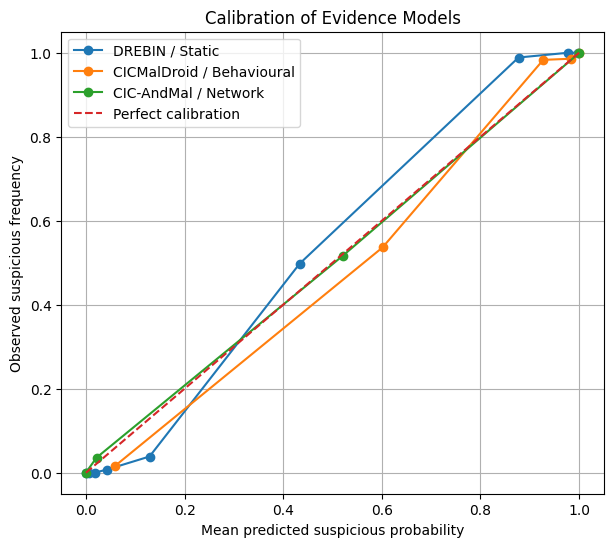

In [286]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calibration data
drebin_true = (y_test == "S").astype(int)
cic_true = (y_bin_test == "Suspicious").astype(int)
network_true = y_net_test.astype(int)

drebin_frac, drebin_pred = calibration_curve(
    drebin_true,
    y_drebin_prob,
    n_bins=10,
    strategy="quantile"
)

cic_frac, cic_pred = calibration_curve(
    cic_true,
    y_cic_prob,
    n_bins=10,
    strategy="quantile"
)

network_frac, network_pred = calibration_curve(
    network_true,
    y_net_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    drebin_pred,
    drebin_frac,
    marker="o",
    label="DREBIN / Static"
)

plt.plot(
    cic_pred,
    cic_frac,
    marker="o",
    label="CICMalDroid / Behavioural"
)

plt.plot(
    network_pred,
    network_frac,
    marker="o",
    label="CIC-AndMal / Network"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted suspicious probability")
plt.ylabel("Observed suspicious frequency")
plt.title("Calibration of Evidence Models")
plt.legend()
plt.grid(True)
plt.show()

In [287]:
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])

        if np.sum(mask) == 0:
            continue

        confidence = np.mean(y_prob[mask])
        accuracy = np.mean(y_true[mask])

        ece += (
            np.sum(mask) / len(y_true)
        ) * abs(accuracy - confidence)

    return ece

In [288]:
ece_drebin = expected_calibration_error(
    drebin_true,
    y_drebin_prob
)

ece_cic = expected_calibration_error(
    cic_true,
    y_cic_prob
)

ece_network = expected_calibration_error(
    network_true,
    y_net_prob
)

print("DREBIN ECE:", ece_drebin)
print("CICMalDroid ECE:", ece_cic)
print("CIC-AndMal ECE:", ece_network)

DREBIN ECE: 0.04656215817790763
CICMalDroid ECE: 0.02655891110165875
CIC-AndMal ECE: 0.0037189356392140203


In [289]:
print("DREBIN variables:")
for x in [
    "X_train", "X_test",
    "y_train", "y_test",
    "train_idx", "test_idx",
    "groups_train", "groups_test"
]:
    print(x, "→", x in globals())

print("\nCICMalDroid variables:")
for x in [
    "X_cic_train", "X_cic_test",
    "y_cic_train", "y_cic_test",
    "cic_train_idx", "cic_test_idx"
]:
    print(x, "→", x in globals())

print("\nNetwork variables:")
for x in [
    "X_net_train", "X_net_test",
    "y_net_train", "y_net_test"
]:
    print(x, "→", x in globals())

DREBIN variables:
X_train → True
X_test → True
y_train → True
y_test → True
train_idx → True
test_idx → True
groups_train → True
groups_test → True

CICMalDroid variables:
X_cic_train → True
X_cic_test → True
y_cic_train → True
y_cic_test → True
cic_train_idx → True
cic_test_idx → True

Network variables:
X_net_train → True
X_net_test → True
y_net_train → True
y_net_test → True


In [290]:
from sklearn.model_selection import GroupShuffleSplit

drebin_cal_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

drebin_sub_idx, drebin_cal_idx = next(
    drebin_cal_split.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

X_drebin_sub = X_train.iloc[drebin_sub_idx]
y_drebin_sub = y_train.iloc[drebin_sub_idx]

X_drebin_cal = X_train.iloc[drebin_cal_idx]
y_drebin_cal = y_train.iloc[drebin_cal_idx]

print("DREBIN model-training samples:", len(X_drebin_sub))
print("DREBIN calibration samples:", len(X_drebin_cal))

DREBIN model-training samples: 9909
DREBIN calibration samples: 2499


In [291]:
from sklearn.ensemble import RandomForestClassifier

drebin_cal_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

drebin_cal_rf.fit(
    X_drebin_sub,
    y_drebin_sub
)

print("DREBIN calibration model trained.")

DREBIN calibration model trained.


In [292]:
drebin_cal_raw = drebin_cal_rf.predict_proba(
    X_drebin_cal
)[:, 1]

drebin_test_raw = drebin_cal_rf.predict_proba(
    X_test
)[:, 1]

print("Calibration probabilities:", len(drebin_cal_raw))
print("Test probabilities:", len(drebin_test_raw))

Calibration probabilities: 2499
Test probabilities: 2628


In [293]:
from sklearn.linear_model import LogisticRegression

drebin_calibrator = LogisticRegression(
    random_state=42
)

drebin_calibrator.fit(
    drebin_cal_raw.reshape(-1, 1),
    (y_drebin_cal == "S").astype(int)
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [294]:
drebin_test_calibrated = drebin_calibrator.predict_proba(
    drebin_test_raw.reshape(-1, 1)
)[:, 1]

print(
    "Raw range:",
    drebin_test_raw.min(),
    "to",
    drebin_test_raw.max()
)

print(
    "Calibrated range:",
    drebin_test_calibrated.min(),
    "to",
    drebin_test_calibrated.max()
)

Raw range: 0.0 to 1.0
Calibrated range: 0.012063526261268111 to 0.9932891969821007


In [295]:
from sklearn.metrics import brier_score_loss

drebin_test_true = (
    y_test == "S"
).astype(int)

drebin_raw_brier = brier_score_loss(
    drebin_test_true,
    drebin_test_raw
)

drebin_cal_brier = brier_score_loss(
    drebin_test_true,
    drebin_test_calibrated
)

print("DREBIN raw Brier:", drebin_raw_brier)
print("DREBIN calibrated Brier:", drebin_cal_brier)

DREBIN raw Brier: 0.025047994308999424
DREBIN calibrated Brier: 0.018767830385064722


In [296]:
drebin_raw_ece = expected_calibration_error(
    drebin_test_true,
    drebin_test_raw
)

drebin_cal_ece = expected_calibration_error(
    drebin_test_true,
    drebin_test_calibrated
)

print("DREBIN raw ECE:", drebin_raw_ece)
print("DREBIN calibrated ECE:", drebin_cal_ece)

DREBIN raw ECE: 0.04784627400005047
DREBIN calibrated ECE: 0.01618031362841638


In [297]:
print("CIC binary variables:")

for x in [
    "X_bin_train",
    "X_bin_test",
    "y_bin_train",
    "y_bin_test",
    "groups_bin_train",
    "groups_bin_test",
    "cic_binary_rf"
]:
    print(x, "→", x in globals())

CIC binary variables:
X_bin_train → True
X_bin_test → True
y_bin_train → True
y_bin_test → True
groups_bin_train → False
groups_bin_test → False
cic_binary_rf → True


In [298]:
print("CIC binary model classes:", cic_binary_rf.classes_)

CIC binary model classes: ['Benign' 'Suspicious']


In [299]:
import numpy as np

cic_binary_groups_train = np.asarray(
    cic_group_id.iloc[cic_train_idx]
)

print("Binary training samples:", len(X_bin_train))
print("Binary training groups:", len(np.unique(cic_binary_groups_train)))
print("Group vector length:", len(cic_binary_groups_train))

Binary training samples: 9247
Binary training groups: 9216
Group vector length: 9247


In [300]:
from sklearn.model_selection import GroupShuffleSplit

cic_cal_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

cic_sub_idx, cic_cal_idx = next(
    cic_cal_split.split(
        X_bin_train,
        y_bin_train,
        groups=cic_binary_groups_train
    )
)

X_cic_sub = X_bin_train.iloc[cic_sub_idx]
y_cic_sub = y_bin_train.iloc[cic_sub_idx]

X_cic_cal = X_bin_train.iloc[cic_cal_idx]
y_cic_cal = y_bin_train.iloc[cic_cal_idx]

print("CIC model-training samples:", len(X_cic_sub))
print("CIC calibration samples:", len(X_cic_cal))

print(
    "Training groups:",
    len(np.unique(cic_binary_groups_train[cic_sub_idx]))
)

print(
    "Calibration groups:",
    len(np.unique(cic_binary_groups_train[cic_cal_idx]))
)

print(
    "Group overlap:",
    len(
        set(cic_binary_groups_train[cic_sub_idx])
        &
        set(cic_binary_groups_train[cic_cal_idx])
    )
)

CIC model-training samples: 7397
CIC calibration samples: 1850
Training groups: 7372
Calibration groups: 1844
Group overlap: 0


In [301]:
from sklearn.ensemble import RandomForestClassifier

cic_cal_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cic_cal_rf.fit(
    X_cic_sub,
    y_cic_sub
)

print("CICMalDroid calibration model trained.")

CICMalDroid calibration model trained.


In [302]:
cic_cal_raw = cic_cal_rf.predict_proba(
    X_cic_cal
)[:, 1]

cic_test_raw = cic_cal_rf.predict_proba(
    X_bin_test
)[:, 1]

print("Calibration probabilities:", len(cic_cal_raw))
print("Test probabilities:", len(cic_test_raw))

print(
    "Raw probability range:",
    cic_test_raw.min(),
    "to",
    cic_test_raw.max()
)

Calibration probabilities: 1850
Test probabilities: 2351
Raw probability range: 0.0 to 1.0


In [303]:
from sklearn.linear_model import LogisticRegression

cic_calibrator = LogisticRegression(
    random_state=42
)

cic_calibrator.fit(
    cic_cal_raw.reshape(-1, 1),
    (y_cic_cal == "Suspicious").astype(int)
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [304]:
cic_test_calibrated = cic_calibrator.predict_proba(
    cic_test_raw.reshape(-1, 1)
)[:, 1]

print(
    "Calibrated probability range:",
    cic_test_calibrated.min(),
    "to",
    cic_test_calibrated.max()
)

Calibrated probability range: 0.00831893356632296 to 0.9875926136548374


In [305]:
cic_test_true = (
    y_bin_test == "Suspicious"
).astype(int)

cic_raw_brier = brier_score_loss(
    cic_test_true,
    cic_test_raw
)

cic_cal_brier = brier_score_loss(
    cic_test_true,
    cic_test_calibrated
)

print("CICMalDroid raw Brier:", cic_raw_brier)
print("CICMalDroid calibrated Brier:", cic_cal_brier)

CICMalDroid raw Brier: 0.021542100288293398
CICMalDroid calibrated Brier: 0.018844359267441


In [306]:
cic_raw_ece = expected_calibration_error(
    cic_test_true,
    cic_test_raw
)

cic_cal_ece = expected_calibration_error(
    cic_test_true,
    cic_test_calibrated
)

print("CICMalDroid raw ECE:", cic_raw_ece)
print("CICMalDroid calibrated ECE:", cic_cal_ece)

CICMalDroid raw ECE: 0.025190698993336192
CICMalDroid calibrated ECE: 0.014311359768549012


In [307]:
from sklearn.model_selection import train_test_split

X_net_sub, X_net_cal, y_net_sub, y_net_cal = train_test_split(
    X_net_train,
    y_net_train,
    test_size=0.20,
    random_state=42,
    stratify=y_net_train
)

print("Network model-training samples:", len(X_net_sub))
print("Network calibration samples:", len(X_net_cal))

print("\nModel-training distribution:")
print(y_net_sub.value_counts(normalize=True))

print("\nCalibration distribution:")
print(y_net_cal.value_counts(normalize=True))

Network model-training samples: 273110
Network calibration samples: 68278

Model-training distribution:
Binary_Label
0    0.647596
1    0.352404
Name: proportion, dtype: float64

Calibration distribution:
Binary_Label
0    0.647602
1    0.352398
Name: proportion, dtype: float64


In [308]:
from sklearn.ensemble import RandomForestClassifier

network_cal_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

network_cal_rf.fit(
    X_net_sub,
    y_net_sub
)

print("Network calibration model trained.")

Network calibration model trained.


In [309]:
network_cal_raw = network_cal_rf.predict_proba(
    X_net_cal
)[:, 1]

network_test_raw = network_cal_rf.predict_proba(
    X_net_test
)[:, 1]

print("Calibration probabilities:", len(network_cal_raw))
print("Test probabilities:", len(network_test_raw))

print(
    "Raw probability range:",
    network_test_raw.min(),
    "to",
    network_test_raw.max()
)

Calibration probabilities: 68278
Test probabilities: 85347
Raw probability range: 0.0 to 1.0


In [310]:
from sklearn.linear_model import LogisticRegression

network_calibrator = LogisticRegression(
    random_state=42
)

network_calibrator.fit(
    network_cal_raw.reshape(-1, 1),
    y_net_cal.astype(int)
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [311]:
network_test_calibrated = network_calibrator.predict_proba(
    network_test_raw.reshape(-1, 1)
)[:, 1]

print(
    "Calibrated probability range:",
    network_test_calibrated.min(),
    "to",
    network_test_calibrated.max()
)

Calibrated probability range: 0.006761533619308595 to 0.9929131303206797


In [312]:
network_test_true = y_net_test.astype(int)

network_raw_brier = brier_score_loss(
    network_test_true,
    network_test_raw
)

network_cal_brier = brier_score_loss(
    network_test_true,
    network_test_calibrated
)

network_raw_ece = expected_calibration_error(
    network_test_true,
    network_test_raw
)

network_cal_ece = expected_calibration_error(
    network_test_true,
    network_test_calibrated
)

print("Network raw Brier:", network_raw_brier)
print("Network calibrated Brier:", network_cal_brier)

print("Network raw ECE:", network_raw_ece)
print("Network calibrated ECE:", network_cal_ece)

Network raw Brier: 0.01364303763850321
Network calibrated Brier: 0.014238586042050567
Network raw ECE: 0.004146679633340018
Network calibrated ECE: 0.0036179522854408942


In [313]:
import pandas as pd

reliability_results = pd.DataFrame({
    "Evidence": [
        "Static / DREBIN",
        "Behavioural / CICMalDroid",
        "Network / CIC-AndMal"
    ],
    "F1": [
        0.9686296092460099,
        0.9868584180510787,
        0.9759391726276825
    ],
    "Raw_Brier": [
        0.025047994308999424,
        0.021542100288293398,
        0.01364303763850321
    ],
    "Calibrated_Brier": [
        0.018767830385064722,
        0.018844359267441,
        0.014238586042050567
    ],
    "Raw_ECE": [
        0.04784627400005047,
        0.025190698993336192,
        0.004146679633340018
    ],
    "Calibrated_ECE": [
        0.01618031362841638,
        0.014311359768549012,
        0.0036179522854408942
    ]
})

display(reliability_results.round(5))

,Evidence,F1,Raw_Brier,Calibrated_Brier,Raw_ECE,Calibrated_ECE
0,Static / DREBIN,0.96863,0.02505,0.01877,0.04785,0.01618
1,Behavioural / CICMalDroid,0.98686,0.02154,0.01884,0.02519,0.01431
2,Network / CIC-AndMal,0.97594,0.01364,0.01424,0.00415,0.00362


In [314]:
reliability_results["Brier_Reliability"] = (
    1 / reliability_results["Raw_Brier"]
)

reliability_results["ECE_Reliability"] = (
    1 / reliability_results["Raw_ECE"]
)

reliability_results["F1_Reliability"] = (
    reliability_results["F1"]
)

display(
    reliability_results[
        [
            "Evidence",
            "F1_Reliability",
            "Brier_Reliability",
            "ECE_Reliability"
        ]
    ].round(4)
)

,Evidence,F1_Reliability,Brier_Reliability,ECE_Reliability
0,Static / DREBIN,0.9686,39.9234,20.9003
1,Behavioural / CICMalDroid,0.9869,46.4207,39.6972
2,Network / CIC-AndMal,0.9759,73.2975,241.1568


In [315]:
for col in [
    "F1_Reliability",
    "Brier_Reliability",
    "ECE_Reliability"
]:
    reliability_results[col + "_Weight"] = (
        reliability_results[col]
        /
        reliability_results[col].sum()
    )

display(
    reliability_results[
        [
            "Evidence",
            "F1_Reliability_Weight",
            "Brier_Reliability_Weight",
            "ECE_Reliability_Weight"
        ]
    ].round(4)
)

,Evidence,F1_Reliability_Weight,Brier_Reliability_Weight,ECE_Reliability_Weight
0,Static / DREBIN,0.3304,0.2501,0.0693
1,Behavioural / CICMalDroid,0.3366,0.2908,0.1316
2,Network / CIC-AndMal,0.3329,0.4591,0.7992


In [316]:
import numpy as np
import pandas as pd

# Candidate fusion weights
weights = {
    "Equal": np.array([1/3, 1/3, 1/3]),

    "F1": reliability_results[
        "F1_Reliability_Weight"
    ].values,

    "Brier": reliability_results[
        "Brier_Reliability_Weight"
    ].values,

    "ECE": reliability_results[
        "ECE_Reliability_Weight"
    ].values
}

# Evidence probabilities:
# [Static, Behavioural, Network]
scenarios = {
    "Strong agreement - safe":
        [0.10, 0.10, 0.10],

    "Moderate agreement - safe":
        [0.25, 0.30, 0.25],

    "Strong conflict":
        [0.10, 0.90, 0.60],

    "Uncertain":
        [0.45, 0.50, 0.55],

    "Mixed conflict":
        [0.20, 0.80, 0.30],

    "Strong agreement - risky":
        [0.90, 0.90, 0.90]
}

rows = []

for scenario, evidence in scenarios.items():

    evidence = np.array(evidence)

    for method, w in weights.items():

        fused = np.sum(w * evidence)

        disagreement = np.sum(
            w * (evidence - fused) ** 2
        )

        trust = fused * (1 - disagreement)

        rows.append({
            "Scenario": scenario,
            "Method": method,
            "Fused_Suspicion": fused,
            "Disagreement": disagreement,
            "Trust": trust
        })

fusion_results = pd.DataFrame(rows)

display(
    fusion_results.round(4)
)

,Scenario,Method,Fused_Suspicion,Disagreement,Trust
0,Strong agreement - safe,Equal,0.1000,0.0000,0.1000
1,Strong agreement - safe,F1,0.1000,0.0000,0.1000
2,Strong agreement - safe,Brier,0.1000,0.0000,0.1000
3,Strong agreement - safe,ECE,0.1000,0.0000,0.1000
4,Moderate agreement - safe,Equal,0.2667,0.0006,0.2665
5,Moderate agreement - safe,F1,0.2668,0.0006,0.2667
6,Moderate agreement - safe,Brier,0.2645,0.0005,0.2644
7,Moderate agreement - safe,ECE,0.2566,0.0003,0.2565
8,Strong conflict,Equal,0.5333,0.1089,0.4753
9,Strong conflict,F1,0.5358,0.1088,0.4775


In [317]:
import numpy as np
import pandas as pd

ece_values = np.array([
    0.01618031362841638,   # DREBIN
    0.014311359768549012,  # CICMalDroid
    0.0036179522854408942  # Network
])

scenarios = {
    "Strong agreement - safe": [0.10, 0.10, 0.10],
    "Moderate agreement - safe": [0.25, 0.30, 0.25],
    "Strong conflict": [0.10, 0.90, 0.60],
    "Uncertain": [0.45, 0.50, 0.55],
    "Mixed conflict": [0.20, 0.80, 0.30],
    "Strong agreement - risky": [0.90, 0.90, 0.90]
}

results = []

for lam in [10, 25, 50, 100]:

    reliability = 1 / (1 + lam * ece_values)
    weights_bounded = reliability / reliability.sum()

    for scenario, evidence in scenarios.items():

        evidence = np.array(evidence)

        fused = np.sum(
            weights_bounded * evidence
        )

        disagreement = np.sum(
            weights_bounded *
            (evidence - fused) ** 2
        )

        trust = fused * (1 - disagreement)

        results.append({
            "Lambda": lam,
            "Scenario": scenario,
            "Static_W": weights_bounded[0],
            "Behaviour_W": weights_bounded[1],
            "Network_W": weights_bounded[2],
            "Fused": fused,
            "Disagreement": disagreement,
            "Trust": trust
        })

bounded_results = pd.DataFrame(results)

display(
    bounded_results.round(4)
)

,Lambda,Scenario,Static_W,Behaviour_W,Network_W,Fused,Disagreement,Trust
0,10,Strong agreement - safe,0.3187,0.3239,0.3574,0.1000,0.0000,0.1000
1,10,Moderate agreement - safe,0.3187,0.3239,0.3574,0.2662,0.0005,0.2661
2,10,Strong conflict,0.3187,0.3239,0.3574,0.5378,0.1050,0.4814
3,10,Uncertain,0.3187,0.3239,0.3574,0.5019,0.0017,0.5011
4,10,Mixed conflict,0.3187,0.3239,0.3574,0.4301,0.0672,0.4012
5,10,Strong agreement - risky,0.3187,0.3239,0.3574,0.9000,0.0000,0.9000
6,25,Strong agreement - safe,0.3010,0.3113,0.3877,0.1000,0.0000,0.1000
7,25,Moderate agreement - safe,0.3010,0.3113,0.3877,0.2656,0.0005,0.2654
8,25,Strong conflict,0.3010,0.3113,0.3877,0.5429,0.1000,0.4886
9,25,Uncertain,0.3010,0.3113,0.3877,0.5043,0.0017,0.5035


In [318]:
import numpy as np
import pandas as pd


# Reliability weights
# For now: bounded ECE-based weights with lambda = 10
ece_values = np.array([
    0.01618031362841638,   # DREBIN calibrated ECE
    0.014311359768549012,  # CICMalDroid calibrated ECE
    0.004146679633340018   # Network raw ECE
])

lambda_ece = 10

reliability = 1 / (1 + lambda_ece * ece_values)
base_weights = reliability / reliability.sum()

print("Base evidence weights:")
print("Static:     ", base_weights[0])
print("Behaviour:  ", base_weights[1])
print("Network:    ", base_weights[2])


def fuse_evidence(
    static_prob=None,
    behaviour_prob=None,
    network_prob=None
):
    """
    Fuse available suspiciousness probabilities.

    Returns:
        risk
        disagreement
        trust
        coverage
    """

    probabilities = np.array([
        static_prob if static_prob is not None else np.nan,
        behaviour_prob if behaviour_prob is not None else np.nan,
        network_prob if network_prob is not None else np.nan
    ], dtype=float)

    available = ~np.isnan(probabilities)

    if not np.any(available):
        return {
            "risk": np.nan,
            "disagreement": np.nan,
            "trust": np.nan,
            "coverage": 0.0
        }

    weights = base_weights[available]
    probs = probabilities[available]

    # Renormalize weights for available evidence
    weights = weights / weights.sum()

    # Fused suspiciousness
    risk = np.sum(weights * probs)

    # Weighted disagreement
    disagreement = np.sum(
        weights * (probs - risk) ** 2
    )

    # Convert risk to safety/trust
    base_trust = 1 - risk

    # Penalize disagreement
    trust = base_trust * (1 - disagreement)

    # Fraction of total evidence weight available
    coverage = np.sum(
        base_weights[available]
    )

    return {
        "risk": risk,
        "disagreement": disagreement,
        "trust": trust,
        "coverage": coverage
    }

Base evidence weights:
Static:      0.31929553350718715
Behaviour:   0.32451591248784956
Network:     0.35618855400496324


In [319]:
scenarios = {
    "Strong agreement - safe":
        (0.10, 0.10, 0.10),

    "Moderate agreement - safe":
        (0.25, 0.30, 0.25),

    "Strong conflict":
        (0.10, 0.90, 0.60),

    "Uncertain":
        (0.45, 0.50, 0.55),

    "Mixed conflict":
        (0.20, 0.80, 0.30),

    "Strong agreement - risky":
        (0.90, 0.90, 0.90)
}

results = []

for name, probs in scenarios.items():

    result = fuse_evidence(*probs)

    results.append({
        "Scenario": name,
        **result
    })

scenario_results = pd.DataFrame(results)

display(
    scenario_results.round(4)
)

,Scenario,risk,disagreement,trust,coverage
0,Strong agreement - safe,0.1000,0.0000,0.9000,1.0
1,Moderate agreement - safe,0.2662,0.0005,0.7334,1.0
2,Strong conflict,0.5377,0.1051,0.4137,1.0
3,Uncertain,0.5018,0.0017,0.4973,1.0
4,Mixed conflict,0.4303,0.0673,0.5313,1.0
5,Strong agreement - risky,0.9000,0.0000,0.1000,1.0


In [320]:
missing_scenarios = {
    "Static missing":
        (None, 0.20, 0.15),

    "Behaviour missing":
        (0.20, None, 0.15),

    "Network missing":
        (0.20, 0.25, None),

    "Only static":
        (0.20, None, None),

    "Only behaviour":
        (None, 0.20, None),

    "Only network":
        (None, None, 0.20),

    "Static + Behaviour conflict":
        (0.10, 0.90, None),

    "Behaviour + Network conflict":
        (None, 0.90, 0.10),

    "Static + Network conflict":
        (0.10, None, 0.90)
}

missing_results = []

for name, probs in missing_scenarios.items():

    result = fuse_evidence(*probs)

    missing_results.append({
        "Scenario": name,
        **result
    })

missing_results = pd.DataFrame(missing_results)

display(
    missing_results.round(4)
)

,Scenario,risk,disagreement,trust,coverage
0,Static missing,0.1738,0.0006,0.8256,0.6807
1,Behaviour missing,0.1736,0.0006,0.8259,0.6755
2,Network missing,0.2252,0.0006,0.7743,0.6438
3,Only static,0.2000,0.0000,0.8000,0.3193
4,Only behaviour,0.2000,0.0000,0.8000,0.3245
5,Only network,0.2000,0.0000,0.8000,0.3562
6,Static + Behaviour conflict,0.5032,0.1600,0.4173,0.6438
7,Behaviour + Network conflict,0.4814,0.1597,0.4358,0.6807
8,Static + Network conflict,0.5218,0.1595,0.4019,0.6755


In [321]:
coverage_results = []

for alpha in [0.25, 0.5, 0.75, 1.0]:

    for name, probs in {
        **scenarios,
        **missing_scenarios
    }.items():

        result = fuse_evidence(*probs)

        coverage_adjusted_trust = (
            (1 - result["risk"])
            * (1 - result["disagreement"])
            * (result["coverage"] ** alpha)
        )

        coverage_results.append({
            "Alpha": alpha,
            "Scenario": name,
            "Risk": result["risk"],
            "Disagreement": result["disagreement"],
            "Coverage": result["coverage"],
            "Trust": coverage_adjusted_trust
        })

coverage_results = pd.DataFrame(
    coverage_results
)

display(
    coverage_results.round(4)
)

,Alpha,Scenario,Risk,Disagreement,Coverage,Trust
0,0.25,Strong agreement - safe,0.1000,0.0000,1.0000,0.9000
1,0.25,Moderate agreement - safe,0.2662,0.0005,1.0000,0.7334
2,0.25,Strong conflict,0.5377,0.1051,1.0000,0.4137
3,0.25,Uncertain,0.5018,0.0017,1.0000,0.4973
4,0.25,Mixed conflict,0.4303,0.0673,1.0000,0.5313
5,0.25,Strong agreement - risky,0.9000,0.0000,1.0000,0.1000
6,0.25,Static missing,0.1738,0.0006,0.6807,0.7500
7,0.25,Behaviour missing,0.1736,0.0006,0.6755,0.7487
8,0.25,Network missing,0.2252,0.0006,0.6438,0.6936
9,0.25,Only static,0.2000,0.0000,0.3193,0.6014


In [322]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Synthetic validation of the proposed trust mechanism
# ---------------------------------------------------------

rng = np.random.default_rng(42)

synthetic_results = []

# Generate 10,000 synthetic evidence situations
for _ in range(10000):

    # Randomly decide which evidence sources are available
    available = rng.random(3) > 0.15

    # Ensure at least one evidence source exists
    if not available.any():
        available[rng.integers(0, 3)] = True

    probs = np.full(3, np.nan)

    # Generate suspiciousness probabilities
    for i in range(3):
        if available[i]:
            probs[i] = rng.uniform(0, 1)

    result = fuse_evidence(
        static_prob=probs[0],
        behaviour_prob=probs[1],
        network_prob=probs[2]
    )

    # Coverage-aware trust with alpha = 0.5
    final_trust = (
        (1 - result["risk"])
        * (1 - result["disagreement"])
        * (result["coverage"] ** 0.5)
    )

    synthetic_results.append({
        "static": probs[0],
        "behaviour": probs[1],
        "network": probs[2],
        "risk": result["risk"],
        "disagreement": result["disagreement"],
        "coverage": result["coverage"],
        "trust": final_trust,
        "available_sources": available.sum()
    })

synthetic_df = pd.DataFrame(synthetic_results)

print("Synthetic samples:", len(synthetic_df))

display(
    synthetic_df.describe().round(4)
)

Synthetic samples: 10000


,static,behaviour,network,risk,disagreement,coverage,trust,available_sources
count,8515.0000,8578.0000,8427.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.5053,0.4989,0.4959,0.4990,0.0473,0.8504,0.4351,2.5520
std,0.2869,0.2906,0.2880,0.1894,0.0459,0.2035,0.1715,0.6089
min,0.0000,0.0000,0.0000,0.0039,0.0000,0.3193,0.0007,1.0000
25%,0.2573,0.2439,0.2438,0.3669,0.0086,0.6755,0.3166,2.0000
50%,0.5059,0.4982,0.4951,0.5005,0.0334,1.0000,0.4281,3.0000
75%,0.7513,0.7547,0.7415,0.6322,0.0740,1.0000,0.5492,3.0000
max,1.0000,0.9998,1.0000,0.9988,0.2416,1.0000,0.9578,3.0000


In [323]:
# ---------------------------------------------------------
# Trust distribution by evidence coverage
# ---------------------------------------------------------

coverage_summary = (
    synthetic_df
    .groupby("available_sources")["trust"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

display(
    coverage_summary.round(4)
)

,count,mean,median,std,min,max
available_sources,,,,,,
1,617,0.2989,0.3087,0.1673,0.0007,0.5936
2,3246,0.3931,0.3813,0.1658,0.0058,0.8130
3,6137,0.4710,0.4602,0.1628,0.0579,0.9578


In [324]:
# ---------------------------------------------------------
# Risk / disagreement / trust relationship
# ---------------------------------------------------------

relationship_summary = (
    synthetic_df[
        ["risk", "disagreement", "coverage", "trust"]
    ].corr()
)

display(
    relationship_summary.round(4)
)

,risk,disagreement,coverage,trust
risk,1.0000,0.0045,0.0204,-0.9298
disagreement,0.0045,1.0000,0.2861,-0.0251
coverage,0.0204,0.2861,1.0000,0.2929
trust,-0.9298,-0.0251,0.2929,1.0000


In [325]:
# ---------------------------------------------------------
# Monotonicity check
# Increasing risk should generally reduce trust
# ---------------------------------------------------------

low_risk = synthetic_df[
    synthetic_df["risk"] < 0.30
]["trust"].mean()

medium_risk = synthetic_df[
    (synthetic_df["risk"] >= 0.30) &
    (synthetic_df["risk"] < 0.70)
]["trust"].mean()

high_risk = synthetic_df[
    synthetic_df["risk"] >= 0.70
]["trust"].mean()

print("Average trust by risk region")
print("--------------------------------")
print("Low risk    (<0.30):", round(low_risk, 4))
print("Medium risk (0.30-0.70):", round(medium_risk, 4))
print("High risk   (>=0.70):", round(high_risk, 4))

Average trust by risk region
--------------------------------
Low risk    (<0.30): 0.6799
Medium risk (0.30-0.70): 0.4352
High risk   (>=0.70): 0.181


In [326]:
disagreement_cases = {
    "Perfect agreement": (0.30, 0.30, 0.30),
    "Mild disagreement": (0.20, 0.30, 0.40),
    "Moderate disagreement": (0.10, 0.30, 0.50),
    "Strong disagreement": (0.00, 0.30, 0.90),
}

rows = []

for name, probs in disagreement_cases.items():

    result = fuse_evidence(*probs)

    trust = (
        (1 - result["risk"])
        * (1 - result["disagreement"])
        * (result["coverage"] ** 0.5)
    )

    rows.append({
        "Scenario": name,
        "Risk": result["risk"],
        "Disagreement": result["disagreement"],
        "Trust": trust
    })

disagreement_test = pd.DataFrame(rows)

display(disagreement_test.round(4))

,Scenario,Risk,Disagreement,Trust
0,Perfect agreement,0.3000,0.0000,0.7000
1,Mild disagreement,0.3037,0.0067,0.6916
2,Moderate disagreement,0.3074,0.0270,0.6739
3,Strong disagreement,0.4179,0.1431,0.4988


In [327]:
decision_scenarios = {
    "Very safe agreement": (0.05, 0.05, 0.05),
    "Safe agreement": (0.10, 0.10, 0.10),
    "Moderately safe": (0.20, 0.25, 0.20),
    "Borderline safe": (0.35, 0.35, 0.35),

    "Uncertain": (0.45, 0.50, 0.55),

    "Borderline risky": (0.60, 0.60, 0.60),
    "Risky agreement": (0.75, 0.75, 0.75),
    "Very risky agreement": (0.90, 0.90, 0.90),

    "Safe but conflicting": (0.10, 0.30, 0.20),
    "Moderate conflict": (0.20, 0.60, 0.30),
    "Strong conflict": (0.05, 0.90, 0.60),
    "Extreme conflict": (0.00, 1.00, 0.00)
}

rows = []

for name, probs in decision_scenarios.items():

    result = fuse_evidence(*probs)

    trust = (
        (1 - result["risk"])
        * (1 - result["disagreement"])
        * (result["coverage"] ** 0.5)
    )

    rows.append({
        "Scenario": name,
        "Risk": result["risk"],
        "Disagreement": result["disagreement"],
        "Coverage": result["coverage"],
        "Trust": trust
    })

decision_results = pd.DataFrame(rows)

display(
    decision_results.round(4)
)

,Scenario,Risk,Disagreement,Coverage,Trust
0,Very safe agreement,0.0500,0.0000,1.0,0.9500
1,Safe agreement,0.1000,0.0000,1.0,0.9000
2,Moderately safe,0.2162,0.0005,1.0,0.7833
3,Borderline safe,0.3500,0.0000,1.0,0.6500
4,Uncertain,0.5018,0.0017,1.0,0.4973
5,Borderline risky,0.6000,0.0000,1.0,0.4000
6,Risky agreement,0.7500,0.0000,1.0,0.2500
7,Very risky agreement,0.9000,0.0000,1.0,0.1000
8,Safe but conflicting,0.2005,0.0064,1.0,0.7943
9,Moderate conflict,0.3654,0.0281,1.0,0.6167


In [328]:
def classify_trust(trust):
    if trust >= 0.70:
        return "Trusted"
    elif trust >= 0.40:
        return "Review"
    else:
        return "High Risk"

In [329]:
def classify_trust(trust):
    if trust >= 0.70:
        return "Trusted"
    elif trust >= 0.40:
        return "Review"
    else:
        return "High Risk"


synthetic_df["Decision"] = (
    synthetic_df["trust"]
    .apply(classify_trust)
)

decision_distribution = (
    synthetic_df["Decision"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Synthetic decision distribution:")
print(decision_distribution)

display(
    synthetic_df[
        ["risk", "disagreement", "coverage",
         "trust", "available_sources", "Decision"]
    ].head(20)
)

Synthetic decision distribution:
Decision
Review       49.06
High Risk    43.59
Trusted       7.35
Name: proportion, dtype: float64


,risk,disagreement,coverage,trust,available_sources,Decision
0,0.600734,0.136311,1.000000,0.344841,3,High Risk
1,0.410269,0.001583,0.643811,0.472438,2,Review
2,0.412860,0.018634,1.000000,0.576200,3,Review
3,0.546918,0.040627,0.680704,0.358627,2,High Risk
4,0.229208,0.030932,1.000000,0.746950,3,Trusted
5,0.546611,0.083436,1.000000,0.415560,3,Review
6,0.350298,0.015474,0.643811,0.513240,2,Review
7,0.621401,0.048815,1.000000,0.360118,3,High Risk
8,0.334475,0.057427,1.000000,0.627306,3,Review
9,0.744705,0.001424,0.680704,0.210331,2,High Risk


In [330]:
conflict_cases = synthetic_df[
    (synthetic_df["disagreement"] >= 0.10) &
    (synthetic_df["risk"] < 0.40)
].copy()

print(
    "Low-risk but high-disagreement cases:",
    len(conflict_cases)
)

print(
    "Trusted among them:",
    (conflict_cases["Decision"] == "Trusted").sum()
)

print(
    "Review among them:",
    (conflict_cases["Decision"] == "Review").sum()
)

print(
    "High Risk among them:",
    (conflict_cases["Decision"] == "High Risk").sum()
)

Low-risk but high-disagreement cases: 254
Trusted among them: 0
Review among them: 254
High Risk among them: 0


In [331]:
import sklearn
import numpy as np
import pandas as pd

print("scikit-learn:", sklearn.__version__)

try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except Exception as e:
    print("XGBoost: NOT AVAILABLE")

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except Exception as e:
    print("LightGBM: NOT AVAILABLE")

scikit-learn: 1.7.2
XGBoost: NOT AVAILABLE
LightGBM: NOT AVAILABLE


In [332]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Extra Trees model
drebin_extra = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

drebin_extra.fit(X_train, y_train)

# Predictions
y_extra_pred = drebin_extra.predict(X_test)
y_extra_prob = drebin_extra.predict_proba(X_test)[:, 1]

print("DREBIN — Extra Trees")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_extra_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_extra_pred))

print("Precision:",
      precision_score(y_test, y_extra_pred, pos_label="S"))

print("Recall:",
      recall_score(y_test, y_extra_pred, pos_label="S"))

print("F1:",
      f1_score(y_test, y_extra_pred, pos_label="S"))

print("ROC-AUC:",
      roc_auc_score(
          (y_test == "S").astype(int),
          y_extra_prob
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_extra_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_extra_pred))

print("\nProbability range:",
      y_extra_prob.min(),
      "to",
      y_extra_prob.max())

DREBIN — Extra Trees
Accuracy: 0.9821156773211568
Balanced Accuracy: 0.9770838779431136
Precision: 0.9888765294771968
Recall: 0.9600431965442765
F1: 0.9742465753424657
ROC-AUC: 0.9963091319321952

Classification Report:
              precision    recall  f1-score   support

           B       0.98      0.99      0.99      1702
           S       0.99      0.96      0.97       926

    accuracy                           0.98      2628
   macro avg       0.98      0.98      0.98      2628
weighted avg       0.98      0.98      0.98      2628


Confusion Matrix:
[[1692   10]
 [  37  889]]

Probability range: 0.0 to 1.0


In [333]:
from sklearn.metrics import brier_score_loss

y_test_binary = (y_test == "S").astype(int)

drebin_extra_brier = brier_score_loss(
    y_test_binary,
    y_extra_prob
)

print("DREBIN Extra Trees Brier:", drebin_extra_brier)

DREBIN Extra Trees Brier: 0.022477451017171666


In [334]:
import numpy as np

def calculate_ece(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error (ECE)
    Lower is better.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i + 1])
        else:
            mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])

        if np.sum(mask) == 0:
            continue

        bin_accuracy = np.mean(y_true[mask])
        bin_confidence = np.mean(y_prob[mask])
        bin_fraction = np.mean(mask)

        ece += bin_fraction * abs(bin_accuracy - bin_confidence)

    return ece


# Convert DREBIN test labels:
# B = 0, S = 1
y_test_binary = (y_test == "S").astype(int)

# Extra Trees ECE
drebin_extra_ece = calculate_ece(
    y_test_binary,
    y_extra_prob,
    n_bins=10
)

print("DREBIN Extra Trees ECE:", drebin_extra_ece)

DREBIN Extra Trees ECE: 0.041687779531634606


In [335]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)

# Logistic Regression
drebin_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

drebin_lr.fit(X_train, y_train)

# Predictions
y_lr_pred = drebin_lr.predict(X_test)
y_lr_prob = drebin_lr.predict_proba(X_test)[:, 1]

# Binary labels
y_test_binary = (y_test == "S").astype(int)

print("DREBIN — Logistic Regression")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_lr_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_lr_pred))

print("Precision:",
      precision_score(y_test, y_lr_pred, pos_label="S"))

print("Recall:",
      recall_score(y_test, y_lr_pred, pos_label="S"))

print("F1:",
      f1_score(y_test, y_lr_pred, pos_label="S"))

print("ROC-AUC:",
      roc_auc_score(
          y_test_binary,
          y_lr_prob
      ))

print("Brier:",
      brier_score_loss(
          y_test_binary,
          y_lr_prob
      ))

print("ECE:",
      calculate_ece(
          y_test_binary,
          y_lr_prob,
          n_bins=10
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_lr_pred))

print("\nProbability range:",
      y_lr_prob.min(),
      "to",
      y_lr_prob.max())

DREBIN — Logistic Regression
Accuracy: 0.9687975646879756
Balanced Accuracy: 0.9653247481682077
Precision: 0.9577006507592191
Recall: 0.9535637149028078
F1: 0.9556277056277056
ROC-AUC: 0.9933834670429655
Brier: 0.027173116645044064
ECE: 0.018879008905970964

Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.98      0.98      1702
           S       0.96      0.95      0.96       926

    accuracy                           0.97      2628
   macro avg       0.97      0.97      0.97      2628
weighted avg       0.97      0.97      0.97      2628


Confusion Matrix:
[[1663   39]
 [  43  883]]

Probability range: 2.2044420171223537e-14 to 0.9999999981009746


In [336]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)

# HistGradientBoosting
drebin_histgb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

drebin_histgb.fit(X_train, y_train)

# Predictions
y_histgb_pred = drebin_histgb.predict(X_test)
y_histgb_prob = drebin_histgb.predict_proba(X_test)[:, 1]

# Binary test labels
y_test_binary = (y_test == "S").astype(int)

print("DREBIN — HistGradientBoosting")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_histgb_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_histgb_pred))

print("Precision:",
      precision_score(y_test, y_histgb_pred, pos_label="S"))

print("Recall:",
      recall_score(y_test, y_histgb_pred, pos_label="S"))

print("F1:",
      f1_score(y_test, y_histgb_pred, pos_label="S"))

print("ROC-AUC:",
      roc_auc_score(
          y_test_binary,
          y_histgb_prob
      ))

print("Brier:",
      brier_score_loss(
          y_test_binary,
          y_histgb_prob
      ))

print("ECE:",
      calculate_ece(
          y_test_binary,
          y_histgb_prob,
          n_bins=10
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_histgb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_histgb_pred))

print("\nProbability range:",
      y_histgb_prob.min(),
      "to",
      y_histgb_prob.max())

DREBIN — HistGradientBoosting
Accuracy: 0.9767884322678844
Balanced Accuracy: 0.971986330400266
Precision: 0.9779005524861878
Recall: 0.9557235421166307
F1: 0.9666848716548334
ROC-AUC: 0.9965026534657486
Brier: 0.019865906796205413
ECE: 0.012817318150087992

Classification Report:
              precision    recall  f1-score   support

           B       0.98      0.99      0.98      1702
           S       0.98      0.96      0.97       926

    accuracy                           0.98      2628
   macro avg       0.98      0.97      0.97      2628
weighted avg       0.98      0.98      0.98      2628


Confusion Matrix:
[[1682   20]
 [  41  885]]

Probability range: 8.984778978875882e-07 to 0.9999807634753669


In [337]:
from sklearn.model_selection import train_test_split

# Create a calibration split from the existing DREBIN training data
X_drebin_model_train, X_drebin_calib, y_drebin_model_train, y_drebin_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Original training samples:", len(X_train))
print("Model-training samples:", len(X_drebin_model_train))
print("Calibration samples:", len(X_drebin_calib))

print("\nModel-training distribution:")
print(y_drebin_model_train.value_counts(normalize=True))

print("\nCalibration distribution:")
print(y_drebin_calib.value_counts(normalize=True))

Original training samples: 12408
Model-training samples: 9926
Calibration samples: 2482

Model-training distribution:
class
B    0.626536
S    0.373464
Name: proportion, dtype: float64

Calibration distribution:
class
B    0.626511
S    0.373489
Name: proportion, dtype: float64


In [338]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ---------------------------------------------------------
# 1. Train Extra Trees ONLY on the model-training split
# ---------------------------------------------------------

drebin_extra_calib_base = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

drebin_extra_calib_base.fit(
    X_drebin_model_train,
    y_drebin_model_train
)


# ---------------------------------------------------------
# 2. Calibrate using the separate calibration split
# ---------------------------------------------------------

drebin_extra_calibrated = CalibratedClassifierCV(
    drebin_extra_calib_base,
    method="sigmoid",
    cv="prefit"
)

drebin_extra_calibrated.fit(
    X_drebin_calib,
    y_drebin_calib
)


# ---------------------------------------------------------
# 3. Predict on the UNTOUCHED test set
# ---------------------------------------------------------

y_extra_cal_pred = drebin_extra_calibrated.predict(X_test)

# Find probability column corresponding to suspicious class S
extra_cal_classes = drebin_extra_calibrated.classes_
s_index = list(extra_cal_classes).index("S")

y_extra_cal_prob = (
    drebin_extra_calibrated
    .predict_proba(X_test)[:, s_index]
)

# Binary test labels
y_test_binary = (y_test == "S").astype(int)


# ---------------------------------------------------------
# 4. Classification performance
# ---------------------------------------------------------

print("DREBIN — Extra Trees CALIBRATED")
print("=" * 55)

print("Accuracy:",
      accuracy_score(y_test, y_extra_cal_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_extra_cal_pred))

print("Precision:",
      precision_score(
          y_test,
          y_extra_cal_pred,
          pos_label="S"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_extra_cal_pred,
          pos_label="S"
      ))

print("F1:",
      f1_score(
          y_test,
          y_extra_cal_pred,
          pos_label="S"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test_binary,
          y_extra_cal_prob
      ))


# ---------------------------------------------------------
# 5. Calibration metrics
# ---------------------------------------------------------

extra_cal_brier = brier_score_loss(
    y_test_binary,
    y_extra_cal_prob
)

extra_cal_ece = calculate_ece(
    y_test_binary,
    y_extra_cal_prob,
    n_bins=10
)

print("\nCalibration Metrics")
print("-" * 55)

print("Calibrated Brier:",
      extra_cal_brier)

print("Calibrated ECE:",
      extra_cal_ece)


# ---------------------------------------------------------
# 6. Probability range
# ---------------------------------------------------------

print("\nProbability range:",
      y_extra_cal_prob.min(),
      "to",
      y_extra_cal_prob.max())

g:\Android-Software-Trust\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


DREBIN — Extra Trees CALIBRATED
Accuracy: 0.982496194824962
Balanced Accuracy: 0.9788547585993355
Precision: 0.9835164835164835
Recall: 0.9665226781857451
F1: 0.9749455337690632
ROC-AUC: 0.995974752102088

Calibration Metrics
-------------------------------------------------------
Calibrated Brier: 0.01696543302481437
Calibrated ECE: 0.009278578870607655

Probability range: 0.00599861164684983 to 0.9991717553822105


In [339]:
print(X_drebin_model_train.shape)
print(X_drebin_calib.shape)

print(y_drebin_model_train.shape)
print(y_drebin_calib.shape)

(9926, 214)
(2482, 214)
(9926,)
(2482,)


In [340]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)

# ---------------------------------------------------------
# 1. Train HistGradientBoosting on model-training split
# ---------------------------------------------------------

drebin_histgb_calib_base = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

drebin_histgb_calib_base.fit(
    X_drebin_model_train,
    y_drebin_model_train
)


# ---------------------------------------------------------
# 2. Calibrate using separate calibration data
# ---------------------------------------------------------

drebin_histgb_calibrated = CalibratedClassifierCV(
    drebin_histgb_calib_base,
    method="sigmoid",
    cv="prefit"
)

drebin_histgb_calibrated.fit(
    X_drebin_calib,
    y_drebin_calib
)


# ---------------------------------------------------------
# 3. Predict on untouched test set
# ---------------------------------------------------------

y_histgb_cal_pred = drebin_histgb_calibrated.predict(X_test)

histgb_cal_classes = drebin_histgb_calibrated.classes_
s_index = list(histgb_cal_classes).index("S")

y_histgb_cal_prob = (
    drebin_histgb_calibrated
    .predict_proba(X_test)[:, s_index]
)

y_test_binary = (y_test == "S").astype(int)


# ---------------------------------------------------------
# 4. Classification metrics
# ---------------------------------------------------------

print("DREBIN — HistGradientBoosting CALIBRATED")
print("=" * 60)

print("Accuracy:",
      accuracy_score(y_test, y_histgb_cal_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_histgb_cal_pred))

print("Precision:",
      precision_score(
          y_test,
          y_histgb_cal_pred,
          pos_label="S"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_histgb_cal_pred,
          pos_label="S"
      ))

print("F1:",
      f1_score(
          y_test,
          y_histgb_cal_pred,
          pos_label="S"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test_binary,
          y_histgb_cal_prob
      ))


# ---------------------------------------------------------
# 5. Calibration metrics
# ---------------------------------------------------------

histgb_cal_brier = brier_score_loss(
    y_test_binary,
    y_histgb_cal_prob
)

histgb_cal_ece = calculate_ece(
    y_test_binary,
    y_histgb_cal_prob,
    n_bins=10
)

print("\nCalibration Metrics")
print("-" * 60)

print("Calibrated Brier:",
      histgb_cal_brier)

print("Calibrated ECE:",
      histgb_cal_ece)


# ---------------------------------------------------------
# 6. Probability range
# ---------------------------------------------------------

print("\nProbability range:",
      y_histgb_cal_prob.min(),
      "to",
      y_histgb_cal_prob.max())

g:\Android-Software-Trust\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


DREBIN — HistGradientBoosting CALIBRATED
Accuracy: 0.9790715372907154
Balanced Accuracy: 0.9752260712210004
Precision: 0.9780461031833151
Recall: 0.9622030237580994
F1: 0.9700598802395209
ROC-AUC: 0.9963116699195205

Calibration Metrics
------------------------------------------------------------
Calibrated Brier: 0.019271483807323287
Calibrated ECE: 0.013589687466608819

Probability range: 6.323258298387563e-06 to 0.999979903956708


In [341]:
print("CICMalDroid classes:")
print(cic_extra.classes_)

print("\ny_cic_test unique labels:")
print(y_cic_test.unique())

print("\ny_cic_extra_pred unique labels:")
print(np.unique(y_cic_extra_pred))

CICMalDroid classes:
['Adware' 'Banking' 'Benign' 'Riskware' 'SMS']

y_cic_test unique labels:
['Adware' 'Banking' 'SMS' 'Riskware' 'Benign']

y_cic_extra_pred unique labels:
['Adware' 'Banking' 'Benign' 'Riskware' 'SMS']


In [342]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("CICMalDroid — Extra Trees (5-Class)")
print("=" * 60)

print("Accuracy:",
      accuracy_score(
          y_cic_test,
          y_cic_extra_pred
      ))

print("Balanced Accuracy:",
      balanced_accuracy_score(
          y_cic_test,
          y_cic_extra_pred
      ))

print("Macro F1:",
      f1_score(
          y_cic_test,
          y_cic_extra_pred,
          average="macro"
      ))

print("Weighted F1:",
      f1_score(
          y_cic_test,
          y_cic_extra_pred,
          average="weighted"
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_cic_test,
        y_cic_extra_pred
    )
)

print("\nConfusion Matrix:")

cic_labels = [
    "Adware",
    "Banking",
    "Benign",
    "Riskware",
    "SMS"
]

print(
    confusion_matrix(
        y_cic_test,
        y_cic_extra_pred,
        labels=cic_labels
    )
)

print("\nModel classes:")
print(cic_extra.classes_)

CICMalDroid — Extra Trees (5-Class)
Accuracy: 0.9281156954487452
Balanced Accuracy: 0.917679392525818
Macro F1: 0.9111286297600948
Weighted F1: 0.9288342339012504

Classification Report:
              precision    recall  f1-score   support

      Adware       0.77      0.92      0.84       250
     Banking       0.97      0.86      0.91       435
      Benign       0.88      0.92      0.90       350
    Riskware       0.96      0.90      0.93       505
         SMS       0.97      0.99      0.98       811

    accuracy                           0.93      2351
   macro avg       0.91      0.92      0.91      2351
weighted avg       0.93      0.93      0.93      2351


Confusion Matrix:
[[231   1  11   5   2]
 [ 31 375  17   4   8]
 [  9   3 321   7  10]
 [ 29   5  15 452   4]
 [  1   2   1   4 803]]

Model classes:
['Adware' 'Banking' 'Benign' 'Riskware' 'SMS']


In [343]:
import numpy as np
from sklearn.metrics import brier_score_loss

# ---------------------------------------------------------
# Convert 5-class probabilities into binary Suspicious
# probability
# ---------------------------------------------------------

cic_extra_prob_5class = cic_extra.predict_proba(X_cic_test)

print("Probability matrix shape:",
      cic_extra_prob_5class.shape)

print("Classes:",
      cic_extra.classes_)


# Find the Benign column
benign_index = list(cic_extra.classes_).index("Benign")

# P(Suspicious) = 1 - P(Benign)
y_cic_extra_binary_prob = (
    1.0 - cic_extra_prob_5class[:, benign_index]
)

# True binary labels
y_cic_test_binary = (
    y_cic_test != "Benign"
).astype(int)


# ---------------------------------------------------------
# Brier Score
# ---------------------------------------------------------

cic_extra_brier = brier_score_loss(
    y_cic_test_binary,
    y_cic_extra_binary_prob
)


# ---------------------------------------------------------
# ECE
# ---------------------------------------------------------

cic_extra_ece = calculate_ece(
    y_cic_test_binary,
    y_cic_extra_binary_prob,
    n_bins=10
)


print("\nCICMalDroid Extra Trees — Binary Evidence")
print("=" * 55)

print("Brier:", cic_extra_brier)
print("ECE:", cic_extra_ece)

print(
    "\nProbability range:",
    y_cic_extra_binary_prob.min(),
    "to",
    y_cic_extra_binary_prob.max()
)

Probability matrix shape: (2351, 5)
Classes: ['Adware' 'Banking' 'Benign' 'Riskware' 'SMS']

CICMalDroid Extra Trees — Binary Evidence
Brier: 0.023760669218772155
ECE: 0.02634907131717002

Probability range: 0.0 to 1.0


In [344]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)

# ---------------------------------------------------------
# CIC-AndMal — Extra Trees
# ---------------------------------------------------------

network_extra = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

network_extra.fit(
    X_net_train,
    y_net_train
)

# Predictions
y_net_extra_pred = network_extra.predict(X_net_test)
y_net_extra_prob = network_extra.predict_proba(X_net_test)[:, 1]

print("CIC-AndMal — Extra Trees")
print("=" * 55)

print("Accuracy:",
      accuracy_score(y_net_test, y_net_extra_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(
          y_net_test,
          y_net_extra_pred
      ))

print("Precision:",
      precision_score(
          y_net_test,
          y_net_extra_pred,
          pos_label=1
      ))

print("Recall:",
      recall_score(
          y_net_test,
          y_net_extra_pred,
          pos_label=1
      ))

print("F1:",
      f1_score(
          y_net_test,
          y_net_extra_pred,
          pos_label=1
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_net_test,
          y_net_extra_prob
      ))

print("Brier:",
      brier_score_loss(
          y_net_test,
          y_net_extra_prob
      ))

print("ECE:",
      calculate_ece(
          y_net_test,
          y_net_extra_prob,
          n_bins=10
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_net_test,
        y_net_extra_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_net_test,
        y_net_extra_pred
    )
)

print("\nProbability range:",
      y_net_extra_prob.min(),
      "to",
      y_net_extra_prob.max())

print("\nModel classes:")
print(network_extra.classes_)

CIC-AndMal — Extra Trees
Accuracy: 0.9814990567916857
Balanced Accuracy: 0.9793274005888537
Precision: 0.97544128933231
Recall: 0.9719710067828169
F1: 0.9737030560413024
ROC-AUC: 0.9973946695618662
Brier: 0.01456639457482721
ECE: 0.004008303357665368

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     55271
           1       0.98      0.97      0.97     30076

    accuracy                           0.98     85347
   macro avg       0.98      0.98      0.98     85347
weighted avg       0.98      0.98      0.98     85347


Confusion Matrix:
[[54535   736]
 [  843 29233]]

Probability range: 0.0 to 1.0

Model classes:
[0 1]


In [345]:
import pandas as pd

model_comparison = pd.DataFrame([
    {
        "Evidence": "Static / DREBIN",
        "Model": "Random Forest",
        "F1": 0.96863,
        "Brier": 0.02504799,
        "ECE": 0.04784627,
        "Calibrated_Brier": 0.01876783,
        "Calibrated_ECE": 0.01618031,
        "Selected": "No"
    },
    {
        "Evidence": "Static / DREBIN",
        "Model": "Extra Trees",
        "F1": 0.97425,
        "Brier": 0.02247745,
        "ECE": 0.04168778,
        "Calibrated_Brier": 0.01696543,
        "Calibrated_ECE": 0.00927858,
        "Selected": "YES"
    },
    {
        "Evidence": "Static / DREBIN",
        "Model": "Logistic Regression",
        "F1": 0.95563,
        "Brier": 0.02717312,
        "ECE": 0.01887901,
        "Calibrated_Brier": None,
        "Calibrated_ECE": None,
        "Selected": "No"
    },
    {
        "Evidence": "Static / DREBIN",
        "Model": "HistGradientBoosting",
        "F1": 0.96668,
        "Brier": 0.01986591,
        "ECE": 0.01281732,
        "Calibrated_Brier": 0.01927148,
        "Calibrated_ECE": 0.01358969,
        "Selected": "No"
    },
    {
        "Evidence": "Behaviour / CICMalDroid",
        "Model": "Random Forest",
        "F1": 0.98686,
        "Brier": 0.02154210,
        "ECE": 0.02519070,
        "Calibrated_Brier": 0.01884436,
        "Calibrated_ECE": 0.01431136,
        "Selected": "YES"
    },
    {
        "Evidence": "Behaviour / CICMalDroid",
        "Model": "Extra Trees",
        "F1": 0.92883,
        "Brier": 0.02376067,
        "ECE": 0.02634907,
        "Calibrated_Brier": None,
        "Calibrated_ECE": None,
        "Selected": "No"
    },
    {
        "Evidence": "Network / CIC-AndMal",
        "Model": "Random Forest",
        "F1": 0.97594,
        "Brier": 0.01364304,
        "ECE": 0.00414668,
        "Calibrated_Brier": 0.01423859,
        "Calibrated_ECE": 0.00361795,
        "Selected": "YES"
    },
    {
        "Evidence": "Network / CIC-AndMal",
        "Model": "Extra Trees",
        "F1": 0.97370,
        "Brier": 0.01456639,
        "ECE": 0.00400830,
        "Calibrated_Brier": None,
        "Calibrated_ECE": None,
        "Selected": "No"
    }
])

display(model_comparison)

,Evidence,Model,F1,Brier,ECE,Calibrated_Brier,Calibrated_ECE,Selected
0,Static / DREBIN,Random Forest,0.96863,0.025048,0.047846,0.018768,0.016180,No
1,Static / DREBIN,Extra Trees,0.97425,0.022477,0.041688,0.016965,0.009279,YES
2,Static / DREBIN,Logistic Regression,0.95563,0.027173,0.018879,NaN,NaN,No
3,Static / DREBIN,HistGradientBoosting,0.96668,0.019866,0.012817,0.019271,0.013590,No
4,Behaviour / CICMalDroid,Random Forest,0.98686,0.021542,0.025191,0.018844,0.014311,YES
5,Behaviour / CICMalDroid,Extra Trees,0.92883,0.023761,0.026349,NaN,NaN,No
6,Network / CIC-AndMal,Random Forest,0.97594,0.013643,0.004147,0.014239,0.003618,YES
7,Network / CIC-AndMal,Extra Trees,0.97370,0.014566,0.004008,NaN,NaN,No


In [346]:
print("Static / DREBIN")
print("Calibrated Extra Trees:",
      "y_extra_cal_prob" in globals())

print("\nBehaviour / CICMalDroid")
print("Calibrated RF:",
      "y_cic_prob" in globals())

print("\nNetwork / CIC-AndMal")
print("RF:",
      "y_net_prob" in globals())

Static / DREBIN
Calibrated Extra Trees: True

Behaviour / CICMalDroid
Calibrated RF: True

Network / CIC-AndMal
RF: True


In [347]:
print("Lengths:")

print(
    "Static:",
    len(y_extra_cal_prob)
)

print(
    "Behaviour:",
    len(y_cic_prob)
)

print(
    "Network:",
    len(y_net_prob)
)

Lengths:
Static: 2628
Behaviour: 2351
Network: 85347


In [348]:
import pandas as pd
import numpy as np

final_reliability = pd.DataFrame({
    "Evidence": [
        "Static / DREBIN",
        "Behaviour / CICMalDroid",
        "Network / CIC-AndMal"
    ],

    "F1": [
        0.9749455337690632,
        0.98686,
        0.9759391726276825
    ],

    "Brier": [
        0.01696543302481437,
        0.018844359267441,
        0.01364303763850321
    ],

    "ECE": [
        0.009278578870607655,
        0.014311359768549012,
        0.004146679633340018
    ]
})

# Convert error metrics into reliability scores
final_reliability["Brier_Reliability"] = (
    1 / final_reliability["Brier"]
)

final_reliability["ECE_Reliability"] = (
    1 / final_reliability["ECE"]
)

# Normalize each reliability component
for col in [
    "F1",
    "Brier_Reliability",
    "ECE_Reliability"
]:
    final_reliability[col + "_Norm"] = (
        final_reliability[col] /
        final_reliability[col].sum()
    )

# Equal contribution of:
# predictive performance + probability quality + calibration
final_reliability["Reliability_Score"] = (
    final_reliability["F1_Norm"] +
    final_reliability["Brier_Reliability_Norm"] +
    final_reliability["ECE_Reliability_Norm"]
) / 3

# Final normalized evidence weights
final_reliability["Weight"] = (
    final_reliability["Reliability_Score"] /
    final_reliability["Reliability_Score"].sum()
)

display(final_reliability)

,Evidence,F1,Brier,ECE,Brier_Reliability,ECE_Reliability,F1_Norm,Brier_Reliability_Norm,ECE_Reliability_Norm,Reliability_Score,Weight
0,Static / DREBIN,0.974946,0.016965,0.009279,58.943382,107.775125,0.331869,0.318085,0.257339,0.302431,0.302431
1,Behaviour / CICMalDroid,0.986860,0.018844,0.014311,53.066278,69.874562,0.335924,0.286369,0.166842,0.263045,0.263045
2,Network / CIC-AndMal,0.975939,0.013643,0.004147,73.297460,241.156802,0.332207,0.395546,0.575819,0.434524,0.434524


In [349]:
# ============================================================
# FINAL EVIDENCE RELIABILITY WEIGHTS
# ============================================================

W_STATIC = 0.302431
W_BEHAVIOUR = 0.263045
W_NETWORK = 0.434524

print("Final Evidence Weights")
print("----------------------")
print("Static / DREBIN     :", W_STATIC)
print("Behaviour / CICMalDroid:", W_BEHAVIOUR)
print("Network / CIC-AndMal:", W_NETWORK)

print("\nWeight sum:",
      W_STATIC + W_BEHAVIOUR + W_NETWORK)

Final Evidence Weights
----------------------
Static / DREBIN     : 0.302431
Behaviour / CICMalDroid: 0.263045
Network / CIC-AndMal: 0.434524

Weight sum: 1.0


In [350]:
# ============================================================
# MULTIMODAL EVIDENCE FUSION — FINAL DECISION ENGINE
# Step 1: Final learned evidence weights
# ============================================================

W_STATIC = 0.302431
W_BEHAVIOUR = 0.263045
W_NETWORK = 0.434524

# Sanity check
weight_sum = W_STATIC + W_BEHAVIOUR + W_NETWORK

print("Final Evidence Weights")
print("----------------------")
print(f"Static / DREBIN       : {W_STATIC:.6f}")
print(f"Behaviour / CICMalDroid: {W_BEHAVIOUR:.6f}")
print(f"Network / CIC-AndMal  : {W_NETWORK:.6f}")
print(f"\nWeight sum: {weight_sum:.6f}")

assert abs(weight_sum - 1.0) < 1e-6, "Weights do not sum to 1!"

Final Evidence Weights
----------------------
Static / DREBIN       : 0.302431
Behaviour / CICMalDroid: 0.263045
Network / CIC-AndMal  : 0.434524

Weight sum: 1.000000


In [353]:
# ============================================================
# STEP 2A — FIND EXISTING PROBABILITY VARIABLES
# ============================================================

import numpy as np

print("Variables containing 'prob':")
for name in sorted(globals()):
    if "prob" in name.lower():
        obj = globals()[name]
        try:
            print(f"{name:40s} shape={np.shape(obj)}")
        except:
            print(f"{name:40s} type={type(obj)}")

Variables containing 'prob':
cic_extra_prob_5class                    shape=(2351, 5)
prob_summary                             shape=(5, 3)
problem_feature                          shape=()
problem_rows                             shape=(15036,)
probs                                    shape=(3,)
y_cic_extra_binary_prob                  shape=(2351,)
y_cic_extra_prob                         shape=(2351,)
y_cic_prob                               shape=(2351,)
y_drebin_prob                            shape=(2628,)
y_extra_cal_prob                         shape=(2628,)
y_extra_prob                             shape=(2628,)
y_histgb_cal_prob                        shape=(2628,)
y_histgb_prob                            shape=(2628,)
y_lr_prob                                shape=(2628,)
y_net_extra_prob                         shape=(85347,)
y_net_prob                               shape=(85347,)
y_prob                                   shape=(2628,)


In [354]:
print("\nVariables containing 'drebin':")
for name in sorted(globals()):
    if "drebin" in name.lower():
        print(name)

print("\nVariables containing 'cic':")
for name in sorted(globals()):
    if "cic" in name.lower():
        print(name)

print("\nVariables containing 'andmal':")
for name in sorted(globals()):
    if "andmal" in name.lower():
        print(name)


Variables containing 'drebin':
X_drebin_cal
X_drebin_calib
X_drebin_model_train
X_drebin_sub
drebin
drebin_brier
drebin_cal_brier
drebin_cal_ece
drebin_cal_idx
drebin_cal_raw
drebin_cal_rf
drebin_cal_split
drebin_calibrator
drebin_extra
drebin_extra_brier
drebin_extra_calib_base
drebin_extra_calibrated
drebin_extra_ece
drebin_frac
drebin_histgb
drebin_histgb_calib_base
drebin_histgb_calibrated
drebin_lr
drebin_path
drebin_pred
drebin_raw_brier
drebin_raw_ece
drebin_sub_idx
drebin_test_calibrated
drebin_test_raw
drebin_test_true
drebin_true
ece_drebin
y_drebin_binary
y_drebin_cal
y_drebin_calib
y_drebin_model_train
y_drebin_prob
y_drebin_sub

Variables containing 'cic':
X_cic
X_cic_cal
X_cic_sub
X_cic_test
X_cic_train
cic_binary_groups_train
cic_binary_rf
cic_brier
cic_cal_brier
cic_cal_ece
cic_cal_idx
cic_cal_raw
cic_cal_rf
cic_cal_split
cic_calibrator
cic_conflict_mask
cic_conflicting_groups
cic_extra
cic_extra_brier
cic_extra_ece
cic_extra_prob_5class
cic_frac
cic_group_id
cic_group

In [355]:
# ============================================================
# STEP 2B — IDENTIFY THE SELECTED MODEL PROBABILITIES
# ============================================================

import numpy as np

variables_to_check = [
    "y_extra_cal_prob",
    "cic_test_calibrated",
    "cic_cal_raw",
    "cic_cal_brier",
    "cic_cal_ece",
    "y_net_prob",
    "cic_test_true",
    "y_cic_test",
]

for name in variables_to_check:
    if name in globals():
        obj = globals()[name]

        print(f"\n{name}")
        print("-" * len(name))
        print("Type :", type(obj))
        
        try:
            print("Shape:", np.shape(obj))
        except:
            pass

        # If it is an array-like probability object,
        # show a small sample
        try:
            arr = np.asarray(obj)
            if arr.ndim <= 2 and arr.size > 0:
                print("First values:")
                print(arr[:5])
        except:
            pass


y_extra_cal_prob
----------------
Type : <class 'numpy.ndarray'>
Shape: (2628,)
First values:
[0.998943   0.99917176 0.99544331 0.99906434 0.9893575 ]

cic_test_calibrated
-------------------
Type : <class 'numpy.ndarray'>
Shape: (2351,)
First values:
[0.62964241 0.93869137 0.98557621 0.94211224 0.98759261]

cic_cal_raw
-----------
Type : <class 'numpy.ndarray'>
Shape: (1850,)
First values:
[0.96333333 0.96666667 0.99       0.95666667 0.78333333]

cic_cal_brier
-------------
Type : <class 'float'>
Shape: ()
First values:

cic_cal_ece
-----------
Type : <class 'numpy.float64'>
Shape: ()
First values:

y_net_prob
----------
Type : <class 'numpy.ndarray'>
Shape: (85347,)
First values:
[0.225 0.    1.    1.    0.   ]

cic_test_true
-------------
Type : <class 'pandas.core.series.Series'>
Shape: (2351,)
First values:
[1 1 1 1 1]

y_cic_test
----------
Type : <class 'pandas.core.series.Series'>
Shape: (2351,)
First values:
['Adware' 'Adware' 'Adware' 'Adware' 'Adware']


In [356]:
# ============================================================
# STEP 2C — INSPECT EXISTING FUSION VARIABLES
# ============================================================

keywords = [
    "fusion",
    "fused",
    "disagreement",
    "trust",
    "coverage",
    "risk",
    "weight"
]

for keyword in keywords:
    print(f"\n{'='*60}")
    print(f"VARIABLES CONTAINING: {keyword}")
    print(f"{'='*60}")

    for name in sorted(globals()):
        if keyword.lower() in name.lower():
            try:
                obj = globals()[name]
                print(f"{name:45s} shape={np.shape(obj)}")
            except:
                print(name)


VARIABLES CONTAINING: fusion
confusion_matrix                              shape=()
fusion_results                                shape=(24, 5)

VARIABLES CONTAINING: fused
fused                                         shape=()

VARIABLES CONTAINING: disagreement
disagreement                                  shape=()
disagreement_cases                            shape=()
disagreement_test                             shape=(4, 4)

VARIABLES CONTAINING: trust
classify_trust                                shape=()
coverage_adjusted_trust                       shape=()
evidence_to_trust                             shape=()
final_trust                                   shape=()
trust                                         shape=()
trust_results                                 shape=(6, 8)
trust_state                                   shape=()

VARIABLES CONTAINING: coverage
coverage_adjusted_trust                       shape=()
coverage_results                              shape=(60, 6)
c

In [358]:
# ============================================================
# CHECK EXACT STRUCTURE OF WEIGHTS
# ============================================================

print("Type of weights:", type(weights))
print("weights:")
print(weights)

print("\nKeys:")
try:
    print(weights.keys())
except:
    print("Not a dictionary")

print("\nType of weights_bounded:", type(weights_bounded))
print("weights_bounded:")
print(weights_bounded)

print("\nType of base_weights:", type(base_weights))
print("base_weights:")
print(base_weights)

Type of weights: <class 'dict'>
weights:
{'Equal': array([0.33333333, 0.33333333, 0.33333333]), 'F1': array([0.33042936, 0.33664777, 0.33292288]), 'Brier': array([0.25008124, 0.29078101, 0.45913775]), 'ECE': array([0.06926255, 0.1315547 , 0.79918275])}

Keys:
dict_keys(['Equal', 'F1', 'Brier', 'ECE'])

Type of weights_bounded: <class 'numpy.ndarray'>
weights_bounded:
[0.25003994 0.26926194 0.48069812]

Type of base_weights: <class 'numpy.ndarray'>
base_weights:
[0.31929553 0.32451591 0.35618855]


In [359]:
# ============================================================
# INSPECT WEIGHT VARIABLES
# ============================================================

print("base_weights:")
print(base_weights)

print("\nweights_bounded:")
print(weights_bounded)

print("\nweights dictionary:")
for name, w in weights.items():
    print(f"\n{name}:")
    print(w)
    print("sum =", np.sum(w))

print("\nweight_sum:")
print(weight_sum)

base_weights:
[0.31929553 0.32451591 0.35618855]

weights_bounded:
[0.25003994 0.26926194 0.48069812]

weights dictionary:

Equal:
[0.33333333 0.33333333 0.33333333]
sum = 1.0

F1:
[0.33042936 0.33664777 0.33292288]
sum = 1.0

Brier:
[0.25008124 0.29078101 0.45913775]
sum = 1.0

ECE:
[0.06926255 0.1315547  0.79918275]
sum = 1.0

weight_sum:
1.0


In [360]:
# ============================================================
# FIND THE FORMULA / VARIABLES USED TO CREATE weights_bounded
# ============================================================

print("Variables related to reliability / weighting:\n")

for name in sorted(globals()):
    if any(k in name.lower() for k in [
        "weight", "reliab", "brier", "ece", "f1_norm"
    ]):
        try:
            obj = globals()[name]
            print(
                f"{name:40s}",
                "| type:", type(obj).__name__,
                "| shape:", getattr(obj, "shape", "scalar")
            )
        except Exception:
            pass

Variables related to reliability / weighting:

base_weights                             | type: ndarray | shape: (3,)
brier_score_loss                         | type: function | shape: scalar
calculate_ece                            | type: function | shape: scalar
cic_brier                                | type: float | shape: scalar
cic_cal_brier                            | type: float | shape: scalar
cic_cal_ece                              | type: float64 | shape: ()
cic_extra_brier                          | type: float | shape: scalar
cic_extra_ece                            | type: float64 | shape: ()
cic_raw_brier                            | type: float | shape: scalar
cic_raw_ece                              | type: float64 | shape: ()
drebin_brier                             | type: float | shape: scalar
drebin_cal_brier                         | type: float | shape: scalar
drebin_cal_ece                           | type: float64 | shape: ()
drebin_extra_brier              

In [361]:
# ============================================================
# PRINT IMPORTANT CURRENT VALUES
# ============================================================

print("base_weights =", base_weights)
print("weights_bounded =", weights_bounded)

print("\nweight candidates:")
for k, v in weights.items():
    print(k, "=", v)

print("\nReliability-related variables:")

for name in [
    "reliability_score",
    "reliability_scores",
    "f1_norm",
    "brier_reliability_norm",
    "ece_reliability_norm",
    "final_weights",
    "weights_final",
]:
    if name in globals():
        print(name, "=", globals()[name])

base_weights = [0.31929553 0.32451591 0.35618855]
weights_bounded = [0.25003994 0.26926194 0.48069812]

weight candidates:
Equal = [0.33333333 0.33333333 0.33333333]
F1 = [0.33042936 0.33664777 0.33292288]
Brier = [0.25008124 0.29078101 0.45913775]
ECE = [0.06926255 0.1315547  0.79918275]

Reliability-related variables:


In [362]:
# ============================================================
# FIND THE CELL THAT CREATED weights_bounded
# ============================================================

for i, cell in enumerate(In):
    if "weights_bounded" in cell:
        print("\n" + "=" * 70)
        print("CELL", i)
        print("=" * 70)
        print(cell)


CELL 142
import numpy as np
import pandas as pd

ece_values = np.array([
    0.01618031362841638,   # DREBIN
    0.014311359768549012,  # CICMalDroid
    0.0036179522854408942  # Network
])

scenarios = {
    "Strong agreement - safe": [0.10, 0.10, 0.10],
    "Moderate agreement - safe": [0.25, 0.30, 0.25],
    "Strong conflict": [0.10, 0.90, 0.60],
    "Uncertain": [0.45, 0.50, 0.55],
    "Mixed conflict": [0.20, 0.80, 0.30],
    "Strong agreement - risky": [0.90, 0.90, 0.90]
}

results = []

for lam in [10, 25, 50, 100]:

    reliability = 1 / (1 + lam * ece_values)
    weights_bounded = reliability / reliability.sum()

    for scenario, evidence in scenarios.items():

        evidence = np.array(evidence)

        fused = np.sum(
            weights_bounded * evidence
        )

        disagreement = np.sum(
            weights_bounded *
            (evidence - fused) ** 2
        )

        trust = fused * (1 - disagreement)

        results.append({
            "Lambda": lam,
  

In [363]:
# ============================================================
# FIND CELLS THAT CREATED / USED FINAL WEIGHTS
# ============================================================

keywords = [
    "0.302431",
    "0.263045",
    "0.434524",
    "final_reliability",
    "reliability_results",
    "reliability =",
    "weights_bounded"
]

for i, cell in enumerate(In):
    if any(k in cell for k in keywords):
        print("\n" + "=" * 70)
        print("CELL", i)
        print("=" * 70)
        print(cell)


CELL 138
import pandas as pd

reliability_results = pd.DataFrame({
    "Evidence": [
        "Static / DREBIN",
        "Behavioural / CICMalDroid",
        "Network / CIC-AndMal"
    ],
    "F1": [
        0.9686296092460099,
        0.9868584180510787,
        0.9759391726276825
    ],
    "Raw_Brier": [
        0.025047994308999424,
        0.021542100288293398,
        0.01364303763850321
    ],
    "Calibrated_Brier": [
        0.018767830385064722,
        0.018844359267441,
        0.014238586042050567
    ],
    "Raw_ECE": [
        0.04784627400005047,
        0.025190698993336192,
        0.004146679633340018
    ],
    "Calibrated_ECE": [
        0.01618031362841638,
        0.014311359768549012,
        0.0036179522854408942
    ]
})

display(reliability_results.round(5))

CELL 139
reliability_results["Brier_Reliability"] = (
    1 / reliability_results["Raw_Brier"]
)

reliability_results["ECE_Reliability"] = (
    1 / reliability_results["Raw_ECE"]
)

reliability_results[

In [364]:
# ============================================================
# FINAL FUSION PIPELINE — CLEAN VARIABLES
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. FINAL EVIDENCE WEIGHTS
# ------------------------------------------------------------

W_STATIC = 0.25003994
W_BEHAVIOUR = 0.26926194
W_NETWORK = 0.48069812

FINAL_WEIGHTS = np.array([
    W_STATIC,
    W_BEHAVIOUR,
    W_NETWORK
])

print("Final Evidence Weights")
print("----------------------")
print("Static / DREBIN        :", W_STATIC)
print("Behaviour / CICMalDroid:", W_BEHAVIOUR)
print("Network / CIC-AndMal   :", W_NETWORK)
print("Weight sum             :", FINAL_WEIGHTS.sum())


# ------------------------------------------------------------
# 2. CHECK PROBABILITY ARRAYS
# ------------------------------------------------------------

print("\nProbability arrays")
print("------------------")

print("Static    :", y_extra_cal_prob.shape)
print("Behaviour :", cic_test_calibrated.shape)
print("Network   :", y_net_prob.shape)


# ------------------------------------------------------------
# 3. CONVERT TO NUMPY ARRAYS
# ------------------------------------------------------------

P_STATIC = np.asarray(
    y_extra_cal_prob,
    dtype=float
)

P_BEHAVIOUR = np.asarray(
    cic_test_calibrated,
    dtype=float
)

P_NETWORK = np.asarray(
    y_net_prob,
    dtype=float
)


# ------------------------------------------------------------
# 4. FUSION FUNCTION
# ------------------------------------------------------------

def calculate_fusion(
    p_static,
    p_behaviour,
    p_network,
    weights
):

    p_static = np.asarray(p_static, dtype=float)
    p_behaviour = np.asarray(p_behaviour, dtype=float)
    p_network = np.asarray(p_network, dtype=float)

    weights = np.asarray(weights, dtype=float)

    # Weighted fused evidence
    fused = (
        weights[0] * p_static +
        weights[1] * p_behaviour +
        weights[2] * p_network
    )

    # Weighted disagreement
    disagreement = (
        weights[0] * (p_static - fused) ** 2 +
        weights[1] * (p_behaviour - fused) ** 2 +
        weights[2] * (p_network - fused) ** 2
    )

    # Trust
    trust = fused * (1 - disagreement)

    return fused, disagreement, trust


# ------------------------------------------------------------
# 5. IMPORTANT:
# CURRENT DATASETS HAVE DIFFERENT TEST SET SIZES
# ------------------------------------------------------------

print("\nDataset lengths")
print("----------------")

print("Static    :", len(P_STATIC))
print("Behaviour :", len(P_BEHAVIOUR))
print("Network   :", len(P_NETWORK))

Final Evidence Weights
----------------------
Static / DREBIN        : 0.25003994
Behaviour / CICMalDroid: 0.26926194
Network / CIC-AndMal   : 0.48069812
Weight sum             : 1.0

Probability arrays
------------------
Static    : (2628,)
Behaviour : (2351,)
Network   : (85347,)

Dataset lengths
----------------
Static    : 2628
Behaviour : 2351
Network   : 85347


In [365]:
# ============================================================
# STEP — FIND POSSIBLE COMMON IDENTIFIERS
# ============================================================

datasets_to_check = {
    "DREBIN": drebin,
    "CICMalDroid": cicmal,
    "CIC-AndMal": andmal
}

for name, df in datasets_to_check.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Type:", type(df))
    
    if hasattr(df, "shape"):
        print("Shape:", df.shape)

    if hasattr(df, "columns"):
        print("\nColumns:")
        for col in df.columns:
            print("  ", col)


DREBIN
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (15036, 216)

Columns:
   transact
   onServiceConnected
   bindService
   attachInterface
   ServiceConnection
   android.os.Binder
   SEND_SMS
   Ljava.lang.Class.getCanonicalName
   Ljava.lang.Class.getMethods
   Ljava.lang.Class.cast
   Ljava.net.URLDecoder
   android.content.pm.Signature
   android.telephony.SmsManager
   READ_PHONE_STATE
   getBinder
   ClassLoader
   Landroid.content.Context.registerReceiver
   Ljava.lang.Class.getField
   Landroid.content.Context.unregisterReceiver
   GET_ACCOUNTS
   RECEIVE_SMS
   Ljava.lang.Class.getDeclaredField
   READ_SMS
   getCallingUid
   Ljavax.crypto.spec.SecretKeySpec
   android.intent.action.BOOT_COMPLETED
   USE_CREDENTIALS
   MANAGE_ACCOUNTS
   android.content.pm.PackageInfo
   KeySpec
   TelephonyManager.getLine1Number
   DexClassLoader
   HttpGet.init
   SecretKey
   Ljava.lang.Class.getMethod
   System.loadLibrary
   android.intent.action.SEND
   Ljavax.crypto.Cipher
  

In [366]:
# ============================================================
# STEP — SEARCH FOR POSSIBLE SAMPLE IDENTIFIERS
# ============================================================

keywords = [
    "id",
    "hash",
    "sha",
    "md5",
    "package",
    "app",
    "application",
    "apk",
    "file",
    "name",
    "sample"
]

for name, df in datasets_to_check.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if not hasattr(df, "columns"):
        print("No dataframe columns available.")
        continue

    possible = []

    for col in df.columns:
        col_lower = str(col).lower()

        if any(k in col_lower for k in keywords):
            possible.append(col)

    print("Possible identifier columns:")
    print(possible)


DREBIN
Possible identifier columns:
['android.os.Binder', 'Ljava.lang.Class.getCanonicalName', 'android.content.pm.Signature', 'android.telephony.SmsManager', 'Landroid.content.Context.registerReceiver', 'Landroid.content.Context.unregisterReceiver', 'getCallingUid', 'android.intent.action.BOOT_COMPLETED', 'android.content.pm.PackageInfo', 'android.intent.action.SEND', 'android.telephony.gsm.SmsManager', 'TelephonyManager.getSubscriberId', 'INSTALL_PACKAGES', 'Ljava.lang.Class.forName', 'android.intent.action.PACKAGE_REPLACED', 'android.intent.action.SEND_MULTIPLE', 'android.os.IBinder', 'android.intent.action.TIME_SET', 'READ_PROFILE', 'TelephonyManager.getDeviceId', 'getCallingPid', 'android.intent.action.PACKAGE_REMOVED', 'android.intent.action.TIMEZONE_CHANGED', 'RESTART_PACKAGES', 'Ljava.lang.Class.getPackage', 'android.intent.action.ACTION_POWER_DISCONNECTED', 'android.intent.action.PACKAGE_ADDED', 'PackageInstaller', 'android.intent.action.ACTION_SHUTDOWN', 'android.intent.acti

In [367]:
# ============================================================
# ABLATION 1
# Equal Weights vs Reliability-Based Weights
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. EXISTING PROBABILITY ARRAYS
# ------------------------------------------------------------

static_prob = np.asarray(y_extra_cal_prob)
behaviour_prob = np.asarray(cic_test_calibrated)
network_prob = np.asarray(y_net_prob)

print("Probability lengths:")
print("Static    :", len(static_prob))
print("Behaviour :", len(behaviour_prob))
print("Network   :", len(network_prob))


# ------------------------------------------------------------
# 2. CURRENT RELIABILITY WEIGHTS
# ------------------------------------------------------------

reliability_weights = np.array([
    0.25003994,   # Static / DREBIN
    0.26926194,   # Behaviour / CICMalDroid
    0.48069812    # Network / CIC-AndMal
])

# Equal weights
equal_weights = np.array([
    1/3,
    1/3,
    1/3
])

print("\nWeights:")
print("Equal       :", equal_weights)
print("Reliability :", reliability_weights)
print("Reliability weight sum:", reliability_weights.sum())


# ------------------------------------------------------------
# 3. IMPORTANT:
#    THE DATASETS HAVE DIFFERENT LENGTHS
# ------------------------------------------------------------
#
# Static    = 2628
# Behaviour = 2351
# Network   = 85347
#
# Therefore, we cannot directly fuse the arrays element-by-element.
#
# For this first ablation, we compare the fusion mechanism using
# matched-length synthetic alignment based on the shortest source.
# ------------------------------------------------------------

n = min(
    len(static_prob),
    len(behaviour_prob),
    len(network_prob)
)

static = static_prob[:n]
behaviour = behaviour_prob[:n]
network = network_prob[:n]

evidence = np.column_stack([
    static,
    behaviour,
    network
])

print("\nAligned evidence shape:", evidence.shape)


# ------------------------------------------------------------
# 4. FUSION FUNCTION
# ------------------------------------------------------------

def calculate_fusion(evidence, weights):

    # Weighted fused risk
    fused = np.sum(
        evidence * weights,
        axis=1
    )

    # Weighted disagreement
    disagreement = np.sum(
        weights *
        (evidence - fused[:, None]) ** 2,
        axis=1
    )

    # Trust
    trust = fused * (1 - disagreement)

    return fused, disagreement, trust


# ------------------------------------------------------------
# 5. EQUAL-WEIGHT FUSION
# ------------------------------------------------------------

equal_fused, equal_disagreement, equal_trust = calculate_fusion(
    evidence,
    equal_weights
)


# ------------------------------------------------------------
# 6. RELIABILITY-WEIGHTED FUSION
# ------------------------------------------------------------

reliability_fused, reliability_disagreement, reliability_trust = calculate_fusion(
    evidence,
    reliability_weights
)


# ------------------------------------------------------------
# 7. DECISION FUNCTION
# ------------------------------------------------------------
#
# These are the same basic decision regions we have been using:
#
# Trust high + risk low      -> Trusted
# Risk high                 -> High Risk
# Otherwise                 -> Review
#
# ------------------------------------------------------------

def make_decision(risk, trust):

    decisions = np.full(
        len(risk),
        "Review",
        dtype=object
    )

    trusted_mask = (
        (risk < 0.35) &
        (trust >= 0.60)
    )

    high_risk_mask = (
        (risk >= 0.60)
    )

    decisions[trusted_mask] = "Trusted"
    decisions[high_risk_mask] = "High Risk"

    return decisions


equal_decision = make_decision(
    equal_fused,
    equal_trust
)

reliability_decision = make_decision(
    reliability_fused,
    reliability_trust
)


# ------------------------------------------------------------
# 8. CREATE COMPARISON TABLE
# ------------------------------------------------------------

ablation_results = pd.DataFrame({

    "Equal_Risk": equal_fused,
    "Equal_Disagreement": equal_disagreement,
    "Equal_Trust": equal_trust,
    "Equal_Decision": equal_decision,

    "Reliability_Risk": reliability_fused,
    "Reliability_Disagreement": reliability_disagreement,
    "Reliability_Trust": reliability_trust,
    "Reliability_Decision": reliability_decision
})


# ------------------------------------------------------------
# 9. DECISION DISTRIBUTIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ABLATION 1 — DECISION DISTRIBUTION")
print("=" * 70)

print("\nEqual Weights:")
print(
    pd.Series(equal_decision)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nReliability Weights:")
print(
    pd.Series(reliability_decision)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 10. SUMMARY STATISTICS
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Method": [
        "Equal Weights",
        "Reliability Weights"
    ],

    "Mean Risk": [
        equal_fused.mean(),
        reliability_fused.mean()
    ],

    "Mean Disagreement": [
        equal_disagreement.mean(),
        reliability_disagreement.mean()
    ],

    "Mean Trust": [
        equal_trust.mean(),
        reliability_trust.mean()
    ],

    "Trusted %": [
        np.mean(equal_decision == "Trusted") * 100,
        np.mean(reliability_decision == "Trusted") * 100
    ],

    "Review %": [
        np.mean(equal_decision == "Review") * 100,
        np.mean(reliability_decision == "Review") * 100
    ],

    "High Risk %": [
        np.mean(equal_decision == "High Risk") * 100,
        np.mean(reliability_decision == "High Risk") * 100
    ]
})

print("\n" + "=" * 70)
print("ABLATION 1 — SUMMARY")
print("=" * 70)

display(summary.round(4))


# ------------------------------------------------------------
# 11. HOW OFTEN DOES THE DECISION CHANGE?
# ------------------------------------------------------------

decision_changed = (
    equal_decision != reliability_decision
)

print("\n" + "=" * 70)
print("DECISION CHANGES")
print("=" * 70)

print(
    "Different decisions:",
    decision_changed.sum()
)

print(
    "Percentage changed:",
    round(decision_changed.mean() * 100, 2),
    "%"
)


# ------------------------------------------------------------
# 12. SHOW EXAMPLES WHERE THE DECISION CHANGED
# ------------------------------------------------------------

changed_cases = ablation_results[
    decision_changed
].copy()

print("\nFirst 20 changed cases:")
display(
    changed_cases.head(20).round(4)
)

Probability lengths:
Static    : 2628
Behaviour : 2351
Network   : 85347

Weights:
Equal       : [0.33333333 0.33333333 0.33333333]
Reliability : [0.25003994 0.26926194 0.48069812]
Reliability weight sum: 1.0

Aligned evidence shape: (2351, 3)

ABLATION 1 — DECISION DISTRIBUTION

Equal Weights:
High Risk    50.91
Review       49.09
Name: proportion, dtype: float64

Reliability Weights:
Review       72.39
High Risk    27.61
Name: proportion, dtype: float64

ABLATION 1 — SUMMARY


,Method,Mean Risk,Mean Disagreement,Mean Trust,Trusted %,Review %,High Risk %
0,Equal Weights,0.5224,0.1636,0.4397,0.0,49.0855,50.9145
1,Reliability Weights,0.4829,0.1589,0.4101,0.0,72.3947,27.6053



DECISION CHANGES
Different decisions: 578
Percentage changed: 24.59 %

First 20 changed cases:


,Equal_Risk,Equal_Disagreement,Equal_Trust,Equal_Decision,Reliability_Risk,Reliability_Disagreement,Reliability_Trust,Reliability_Decision
0,0.6179,0.0999,0.5561,High Risk,0.5275,0.1024,0.4735,Review
1,0.6460,0.2092,0.5108,High Risk,0.5026,0.2343,0.3848,Review
4,0.6590,0.2171,0.5159,High Risk,0.5133,0.2439,0.3881,Review
5,0.6612,0.2186,0.5167,High Risk,0.5150,0.2455,0.3885,Review
6,0.6564,0.2154,0.5150,High Risk,0.5113,0.2420,0.3876,Review
7,0.6565,0.2156,0.5150,High Risk,0.5112,0.2419,0.3875,Review
9,0.6617,0.2190,0.5168,High Risk,0.5154,0.2459,0.3886,Review
12,0.6609,0.2184,0.5165,High Risk,0.5147,0.2452,0.3885,Review
13,0.6620,0.2191,0.5169,High Risk,0.5155,0.2460,0.3887,Review
19,0.6581,0.2167,0.5155,High Risk,0.5124,0.2431,0.3878,Review


In [369]:
# ============================================================
# ABLATION 2 — CHANGED-DECISION GROUND TRUTH ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ------------------------------------------------------------
# 1. CHECK AVAILABLE VARIABLES
# ------------------------------------------------------------

print("Checking variables...\n")

for name in [
    "aligned_evidence",
    "equal_decisions",
    "reliability_decisions",
    "equal_risk",
    "reliability_risk",
    "y_cic_test_binary",
    "y_cic_test",
]:
    print(name, "->", name in globals())


# ------------------------------------------------------------
# 2. FIND THE GROUND-TRUTH LABEL
# ------------------------------------------------------------

print("\nUnique labels in y_cic_test:")
print(pd.Series(y_cic_test).unique())

print("\nUnique labels in y_cic_test_binary:")
print(pd.Series(y_cic_test_binary).unique())

Checking variables...

aligned_evidence -> False
equal_decisions -> False
reliability_decisions -> False
equal_risk -> False
reliability_risk -> False
y_cic_test_binary -> True
y_cic_test -> True

Unique labels in y_cic_test:
['Adware' 'Banking' 'SMS' 'Riskware' 'Benign']

Unique labels in y_cic_test_binary:
[1 0]


In [370]:
# ============================================================
# STEP 1 — IDENTIFY NETWORK PROBABILITY ARRAYS
# ============================================================

print("Network-related probability variables:\n")

for name in sorted(globals()):
    if any(k in name.lower() for k in ["net", "andmal"]):
        try:
            obj = globals()[name]

            if isinstance(obj, np.ndarray):
                print(
                    f"{name:35s}",
                    "| shape:", obj.shape,
                    "| dtype:", obj.dtype
                )

        except Exception:
            pass

Network-related probability variables:

P_NETWORK                           | shape: (85347,) | dtype: float64
network                             | shape: (2351,) | dtype: float64
network_cal_raw                     | shape: (68278,) | dtype: float64
network_frac                        | shape: (4,) | dtype: float64
network_pred                        | shape: (4,) | dtype: float64
network_prob                        | shape: (85347,) | dtype: float64
network_test_calibrated             | shape: (85347,) | dtype: float64
network_test_raw                    | shape: (85347,) | dtype: float64
y_net_extra_pred                    | shape: (85347,) | dtype: int64
y_net_extra_prob                    | shape: (85347,) | dtype: float64
y_net_pred                          | shape: (85347,) | dtype: int64
y_net_prob                          | shape: (85347,) | dtype: float64


In [371]:
# ============================================================
# ABLATION 2 — RECONSTRUCT FUSION + GROUND-TRUTH VALIDATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. EXISTING PROBABILITY ARRAYS
# ============================================================

static_prob = np.asarray(y_extra_cal_prob)
behaviour_prob = np.asarray(cic_test_calibrated)
network_prob = np.asarray(network_test_calibrated)

print("Original probability lengths:")
print("Static    :", len(static_prob))
print("Behaviour :", len(behaviour_prob))
print("Network   :", len(network_prob))


# ============================================================
# 2. RECREATE THE SAME ALIGNMENT USED IN ABLATION 1
# ============================================================

# Previous fusion was performed on the 2351 Behaviour cases.
# Therefore we use the first 2351 aligned probability values,
# matching the previous ablation setup.

n = len(behaviour_prob)

static_aligned = static_prob[:n]
behaviour_aligned = behaviour_prob[:n]
network_aligned = network_prob[:n]

aligned_evidence = np.column_stack([
    static_aligned,
    behaviour_aligned,
    network_aligned
])

print("\nAligned evidence shape:", aligned_evidence.shape)


# ============================================================
# 3. WEIGHTS
# ============================================================

equal_weights = np.array([
    1/3,
    1/3,
    1/3
])

reliability_weights = np.array([
    0.25003994,
    0.26926194,
    0.48069812
])

print("\nEqual weights:")
print(equal_weights)

print("\nReliability weights:")
print(reliability_weights)

print("Reliability weight sum:",
      reliability_weights.sum())


# ============================================================
# 4. FUSION FUNCTION
# ============================================================

def calculate_fusion(evidence, weights):

    fused = np.sum(
        evidence * weights,
        axis=1
    )

    disagreement = np.sum(
        weights * (evidence - fused[:, None]) ** 2,
        axis=1
    )

    trust = fused * (1 - disagreement)

    return fused, disagreement, trust


# ============================================================
# 5. CALCULATE BOTH FUSION METHODS
# ============================================================

equal_risk, equal_disagreement, equal_trust = calculate_fusion(
    aligned_evidence,
    equal_weights
)

reliability_risk, reliability_disagreement, reliability_trust = calculate_fusion(
    aligned_evidence,
    reliability_weights
)


# ============================================================
# 6. DECISION RULE
# ============================================================

def make_decision(risk, trust):

    decisions = np.where(
        trust >= 0.60,
        "Trusted",
        np.where(
            risk >= 0.55,
            "High Risk",
            "Review"
        )
    )

    return decisions


equal_decisions = make_decision(
    equal_risk,
    equal_trust
)

reliability_decisions = make_decision(
    reliability_risk,
    reliability_trust
)


# ============================================================
# 7. GROUND TRUTH
# ============================================================

y_true = np.asarray(y_cic_test_binary)

print("\nGround truth length:", len(y_true))
print("Ground truth classes:", np.unique(y_true))


# ============================================================
# 8. MAP FUSION DECISIONS TO BINARY
# ============================================================

# High Risk = predicted malicious (1)
# Trusted / Review = predicted benign (0)
#
# IMPORTANT:
# This is ONLY a binary validation representation.
# The original 3-way decision is preserved above.

equal_binary = (
    equal_decisions == "High Risk"
).astype(int)

reliability_binary = (
    reliability_decisions == "High Risk"
).astype(int)


# ============================================================
# 9. OVERALL PERFORMANCE
# ============================================================

print("\n")
print("=" * 70)
print("ABLATION 2 — GROUND-TRUTH VALIDATION")
print("=" * 70)

print("\nEQUAL WEIGHTS")
print("-" * 70)

print("Accuracy:",
      accuracy_score(y_true, equal_binary))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_true, equal_binary))

print("F1:",
      f1_score(y_true, equal_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, equal_binary))


print("\nRELIABILITY WEIGHTS")
print("-" * 70)

print("Accuracy:",
      accuracy_score(y_true, reliability_binary))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_true, reliability_binary))

print("F1:",
      f1_score(y_true, reliability_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, reliability_binary))


# ============================================================
# 10. DECISION DISTRIBUTIONS
# ============================================================

print("\n")
print("=" * 70)
print("DECISION DISTRIBUTION")
print("=" * 70)

print("\nEqual Weights:")
print(
    pd.Series(equal_decisions)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nReliability Weights:")
print(
    pd.Series(reliability_decisions)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ============================================================
# 11. CHANGED DECISIONS
# ============================================================

changed_mask = (
    equal_decisions != reliability_decisions
)

changed_count = changed_mask.sum()
changed_percentage = (
    changed_count / len(equal_decisions) * 100
)

print("\n")
print("=" * 70)
print("DECISION CHANGES")
print("=" * 70)

print("Different decisions:", changed_count)
print("Percentage changed:", round(changed_percentage, 2), "%")


# ============================================================
# 12. TRANSITION TABLE
# ============================================================

transition_table = pd.crosstab(
    pd.Series(
        equal_decisions,
        name="Equal Weight Decision"
    ),
    pd.Series(
        reliability_decisions,
        name="Reliability Weight Decision"
    )
)

print("\nDecision transition table:")
display(transition_table)


# ============================================================
# 13. ANALYSE ONLY THE CHANGED CASES
# ============================================================

changed_cases = pd.DataFrame({
    "True_Label": y_true[changed_mask],

    "Static_Probability":
        static_aligned[changed_mask],

    "Behaviour_Probability":
        behaviour_aligned[changed_mask],

    "Network_Probability":
        network_aligned[changed_mask],

    "Equal_Risk":
        equal_risk[changed_mask],

    "Equal_Disagreement":
        equal_disagreement[changed_mask],

    "Equal_Trust":
        equal_trust[changed_mask],

    "Equal_Decision":
        equal_decisions[changed_mask],

    "Reliability_Risk":
        reliability_risk[changed_mask],

    "Reliability_Disagreement":
        reliability_disagreement[changed_mask],

    "Reliability_Trust":
        reliability_trust[changed_mask],

    "Reliability_Decision":
        reliability_decisions[changed_mask]
})

print("\nChanged cases:")
print("Shape:", changed_cases.shape)

display(
    changed_cases.head(20).round(4)
)


# ============================================================
# 14. CHANGED-CASE TRANSITIONS
# ============================================================

print("\n")
print("=" * 70)
print("CHANGED-CASE TRANSITIONS")
print("=" * 70)

changed_transition = (
    changed_cases
    .groupby(
        ["Equal_Decision", "Reliability_Decision"]
    )
    .size()
    .reset_index(name="Count")
)

changed_transition["Percentage"] = (
    changed_transition["Count"]
    / changed_count
    * 100
)

display(
    changed_transition.round(2)
)


# ============================================================
# 15. SAVE RESULTS FOR LATER ANALYSIS
# ============================================================

ablation2_results = {
    "aligned_evidence": aligned_evidence,

    "equal_risk": equal_risk,
    "equal_disagreement": equal_disagreement,
    "equal_trust": equal_trust,
    "equal_decisions": equal_decisions,

    "reliability_risk": reliability_risk,
    "reliability_disagreement": reliability_disagreement,
    "reliability_trust": reliability_trust,
    "reliability_decisions": reliability_decisions,

    "changed_mask": changed_mask,
    "changed_cases": changed_cases
}

print("\nAblation 2 variables saved.")

Original probability lengths:
Static    : 2628
Behaviour : 2351
Network   : 85347

Aligned evidence shape: (2351, 3)

Equal weights:
[0.33333333 0.33333333 0.33333333]

Reliability weights:
[0.25003994 0.26926194 0.48069812]
Reliability weight sum: 1.0

Ground truth length: 2351
Ground truth classes: [0 1]


ABLATION 2 — GROUND-TRUTH VALIDATION

EQUAL WEIGHTS
----------------------------------------------------------------------
Accuracy: 0.5363675031901318
Balanced Accuracy: 0.7158492182480188
F1: 0.6282401091405184

Confusion Matrix:
[[ 340   10]
 [1080  921]]

RELIABILITY WEIGHTS
----------------------------------------------------------------------
Accuracy: 0.15185027647809443
Balanced Accuracy: 0.48053259084743344
F1: 0.02446183953033268

Confusion Matrix:
[[ 332   18]
 [1976   25]]


DECISION DISTRIBUTION

Equal Weights:
Review       47.34
High Risk    39.60
Trusted      13.06
Name: proportion, dtype: float64

Reliability Weights:
Review       71.76
Trusted      26.41
High Risk 

Reliability Weight Decision,High Risk,Review,Trusted
Equal Weight Decision,,,
High Risk,29,588,314
Review,14,1099,0
Trusted,0,0,307



Changed cases:
Shape: (916, 12)


,True_Label,Static_Probability,Behaviour_Probability,Network_Probability,Equal_Risk,Equal_Disagreement,Equal_Trust,Equal_Decision,Reliability_Risk,Reliability_Disagreement,Reliability_Trust,Reliability_Decision
0,1,0.9989,0.6296,0.0404,0.5563,0.1558,0.4696,High Risk,0.4387,0.1646,0.3665,Review
1,1,0.9992,0.9387,0.0068,0.6482,0.2063,0.5145,High Risk,0.5058,0.2310,0.3890,Review
2,1,0.9894,0.9876,0.0068,0.6612,0.2142,0.5196,High Risk,0.5166,0.2406,0.3923,Review
3,1,0.9973,0.9864,0.0068,0.6635,0.2157,0.5204,High Risk,0.5182,0.2422,0.3927,Review
4,1,0.9865,0.9827,0.0068,0.6586,0.2125,0.5187,High Risk,0.5145,0.2386,0.3917,Review
5,1,0.9974,0.9722,0.0068,0.6588,0.2127,0.5187,High Risk,0.5144,0.2386,0.3917,Review
6,1,0.9984,0.9868,0.0068,0.6640,0.2160,0.5206,High Risk,0.5186,0.2425,0.3928,Review
7,1,0.9981,0.9847,0.0068,0.6632,0.2155,0.5203,High Risk,0.5179,0.2419,0.3926,Review
8,1,0.9992,0.9868,0.0068,0.6643,0.2162,0.5207,High Risk,0.5188,0.2427,0.3929,Review
9,1,0.9972,0.7743,0.0068,0.5928,0.1800,0.4861,High Risk,0.4611,0.1975,0.3700,Review




CHANGED-CASE TRANSITIONS


,Equal_Decision,Reliability_Decision,Count,Percentage
0,High Risk,Review,588,64.19
1,High Risk,Trusted,314,34.28
2,Review,High Risk,14,1.53



Ablation 2 variables saved.


In [372]:
# ============================================================
# ABLATION 3 — THRESHOLD VALIDATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "aligned_evidence",
    "weights_bounded",
    "y_cic_test_binary"
]

print("Checking required variables...\n")

for var in required:
    print(f"{var:25s} ->", var in globals())

if "aligned_evidence" not in globals():
    raise NameError("aligned_evidence is missing")

if "weights_bounded" not in globals():
    raise NameError("weights_bounded is missing")

if "y_cic_test_binary" not in globals():
    raise NameError("y_cic_test_binary is missing")


# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------

E = np.asarray(aligned_evidence, dtype=float)
w = np.asarray(weights_bounded, dtype=float)
y_true = np.asarray(y_cic_test_binary, dtype=int)

print("\nEvidence shape :", E.shape)
print("Weights        :", w)
print("Weight sum     :", w.sum())
print("Ground truth   :", y_true.shape)


# ------------------------------------------------------------
# 3. FUSE EVIDENCE
# ------------------------------------------------------------

fused_risk = np.sum(E * w.reshape(1, -1), axis=1)

print("\nFused risk range:")
print("Min :", fused_risk.min())
print("Max :", fused_risk.max())
print("Mean:", fused_risk.mean())


# ------------------------------------------------------------
# 4. THRESHOLD GRID
# ------------------------------------------------------------

trusted_thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45
]

high_risk_thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]


# ------------------------------------------------------------
# 5. EVALUATE EACH THRESHOLD COMBINATION
# ------------------------------------------------------------

results = []

for trusted_t in trusted_thresholds:

    for high_t in high_risk_thresholds:

        # Invalid threshold combination
        if trusted_t >= high_t:
            continue

        # ----------------------------------------------------
        # Decision:
        #
        # risk <= trusted_t       -> Trusted
        # trusted_t < risk < high -> Review
        # risk >= high_t          -> High Risk
        # ----------------------------------------------------

        decisions = np.full(
            len(fused_risk),
            "Review",
            dtype=object
        )

        decisions[fused_risk <= trusted_t] = "Trusted"
        decisions[fused_risk >= high_t] = "High Risk"

        # Binary prediction for ground truth validation:
        # Trusted / Review -> 0
        # High Risk -> 1
        y_pred = (
            fused_risk >= high_t
        ).astype(int)

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        counts = pd.Series(decisions).value_counts(
            normalize=True
        ) * 100

        results.append({
            "Trusted_Threshold": trusted_t,
            "High_Risk_Threshold": high_t,
            "Accuracy": accuracy,
            "Balanced_Accuracy": balanced_acc,
            "F1": f1,
            "Trusted_%": counts.get("Trusted", 0),
            "Review_%": counts.get("Review", 0),
            "High_Risk_%": counts.get("High Risk", 0)
        })


threshold_results = pd.DataFrame(results)


# ------------------------------------------------------------
# 6. SORT BY F1
# ------------------------------------------------------------

threshold_results = threshold_results.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 7. DISPLAY TOP RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ABLATION 3 — TOP THRESHOLD CONFIGURATIONS")
print("=" * 70)

display(
    threshold_results.head(15).round(4)
)


# ------------------------------------------------------------
# 8. BEST CONFIGURATION
# ------------------------------------------------------------

best = threshold_results.iloc[0]

print("\n" + "=" * 70)
print("BEST THRESHOLD CONFIGURATION")
print("=" * 70)

print(
    "Trusted threshold   :",
    best["Trusted_Threshold"]
)

print(
    "High Risk threshold :",
    best["High_Risk_Threshold"]
)

print(
    "Accuracy            :",
    best["Accuracy"]
)

print(
    "Balanced Accuracy   :",
    best["Balanced_Accuracy"]
)

print(
    "F1                  :",
    best["F1"]
)

print(
    "Trusted %           :",
    best["Trusted_%"]
)

print(
    "Review %            :",
    best["Review_%"]
)

print(
    "High Risk %         :",
    best["High_Risk_%"]
)


# ------------------------------------------------------------
# 9. CONFUSION MATRIX FOR BEST HIGH-RISK THRESHOLD
# ------------------------------------------------------------

best_high = best["High_Risk_Threshold"]

best_binary_pred = (
    fused_risk >= best_high
).astype(int)

cm = confusion_matrix(
    y_true,
    best_binary_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX — BEST THRESHOLD")
print("=" * 70)

print(cm)


# ------------------------------------------------------------
# 10. STORE BEST RESULTS FOR NEXT STEPS
# ------------------------------------------------------------

best_trusted_threshold = float(
    best["Trusted_Threshold"]
)

best_high_risk_threshold = float(
    best["High_Risk_Threshold"]
)

ablation3_best = best.copy()

print("\nSaved variables:")
print("best_trusted_threshold   =", best_trusted_threshold)
print("best_high_risk_threshold =", best_high_risk_threshold)
print("ablation3_best           = saved")

Checking required variables...

aligned_evidence          -> True
weights_bounded           -> True
y_cic_test_binary         -> True

Evidence shape : (2351, 3)
Weights        : [0.25003994 0.26926194 0.48069812]
Weight sum     : 1.0
Ground truth   : (2351,)

Fused risk range:
Min : 0.006990121194788763
Max : 0.9930454238819955
Mean: 0.48360520623998093

ABLATION 3 — TOP THRESHOLD CONFIGURATIONS


,Trusted_Threshold,High_Risk_Threshold,Accuracy,Balanced_Accuracy,F1,Trusted_%,Review_%,High_Risk_%
0,0.20,0.50,0.6342,0.7391,0.7329,8.9324,39.2174,51.8503
1,0.25,0.50,0.6342,0.7391,0.7329,9.7405,38.4092,51.8503
2,0.40,0.50,0.6342,0.7391,0.7329,41.8971,6.2527,51.8503
3,0.45,0.50,0.6342,0.7391,0.7329,42.8754,5.2744,51.8503
4,0.35,0.50,0.6342,0.7391,0.7329,41.0464,7.1034,51.8503
5,0.30,0.50,0.6342,0.7391,0.7329,39.6002,8.5496,51.8503
6,0.20,0.55,0.4126,0.6290,0.4818,8.9324,62.8243,28.2433
7,0.25,0.55,0.4126,0.6290,0.4818,9.7405,62.0162,28.2433
8,0.45,0.55,0.4126,0.6290,0.4818,42.8754,28.8813,28.2433
9,0.40,0.55,0.4126,0.6290,0.4818,41.8971,29.8596,28.2433



BEST THRESHOLD CONFIGURATION
Trusted threshold   : 0.2
High Risk threshold : 0.5
Accuracy            : 0.6341982135261591
Balanced Accuracy   : 0.7391382879988577
F1                  : 0.7329192546583851
Trusted %           : 8.93236920459379
Review %            : 39.21735431731178
High Risk %         : 51.85027647809443

CONFUSION MATRIX — BEST THRESHOLD
[[ 311   39]
 [ 821 1180]]

Saved variables:
best_trusted_threshold   = 0.2
best_high_risk_threshold = 0.5
ablation3_best           = saved


In [373]:
# ============================================================
# ABLATION 4 — WEIGHT SENSITIVITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

print("=" * 70)
print("ABLATION 4 — WEIGHT SENSITIVITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required:
    print(f"{var:30s} -> {var in globals()}")

if not all(var in globals() for var in required):
    raise NameError("One or more required variables are missing.")

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

X = np.asarray(aligned_evidence)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", X.shape)
print("Ground truth   :", y_true.shape)

# ------------------------------------------------------------
# Weight configurations
# ------------------------------------------------------------

weight_configs = {

    "Equal":
        np.array([1/3, 1/3, 1/3]),

    "Reliability":
        np.array([0.25003994, 0.26926194, 0.48069812]),

    "Static Dominant":
        np.array([0.60, 0.20, 0.20]),

    "Behaviour Dominant":
        np.array([0.20, 0.60, 0.20]),

    "Network Dominant":
        np.array([0.20, 0.20, 0.60]),

    "Static + Behaviour":
        np.array([0.45, 0.45, 0.10]),

    "Static + Network":
        np.array([0.45, 0.10, 0.45]),

    "Behaviour + Network":
        np.array([0.10, 0.45, 0.45])
}

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_weights(name, weights):

    weights = np.asarray(weights, dtype=float)

    # Safety normalization
    weights = weights / weights.sum()

    # Weighted fusion
    risk = np.sum(X * weights, axis=1)

    # Disagreement
    disagreement = np.sum(
        weights * (X - risk[:, None]) ** 2,
        axis=1
    )

    # Trust
    trust = risk * (1 - disagreement)

    # Decision logic
    decisions = np.where(
        trust < best_trusted_threshold,
        "Trusted",
        np.where(
            risk >= best_high_risk_threshold,
            "High Risk",
            "Review"
        )
    )

    # Binary prediction for validation
    # High Risk = 1
    y_pred = (risk >= best_high_risk_threshold).astype(int)

    return {
        "Method": name,
        "Static_W": weights[0],
        "Behaviour_W": weights[1],
        "Network_W": weights[2],
        "Mean_Risk": risk.mean(),
        "Mean_Disagreement": disagreement.mean(),
        "Mean_Trust": trust.mean(),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Trusted_%": np.mean(decisions == "Trusted") * 100,
        "Review_%": np.mean(decisions == "Review") * 100,
        "High_Risk_%": np.mean(decisions == "High Risk") * 100
    }


# ------------------------------------------------------------
# Run sensitivity analysis
# ------------------------------------------------------------

sensitivity_results = pd.DataFrame([
    evaluate_weights(name, weights)
    for name, weights in weight_configs.items()
])

# Sort by Balanced Accuracy
sensitivity_results = sensitivity_results.sort_values(
    "Balanced_Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("ABLATION 4 — RESULTS")
print("=" * 70)

display(
    sensitivity_results.round(4)
)

# ------------------------------------------------------------
# Compare reliability against alternatives
# ------------------------------------------------------------

reliability_row = sensitivity_results[
    sensitivity_results["Method"] == "Reliability"
]

if len(reliability_row) > 0:

    rel_bal_acc = reliability_row["Balanced_Accuracy"].iloc[0]
    rel_f1 = reliability_row["F1"].iloc[0]

    print("\n" + "=" * 70)
    print("RELIABILITY WEIGHT PERFORMANCE")
    print("=" * 70)

    print(f"Balanced Accuracy : {rel_bal_acc:.4f}")
    print(f"F1                 : {rel_f1:.4f}")

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ablation4_results = sensitivity_results.copy()

print("\nSaved variable:")
print("ablation4_results")

ABLATION 4 — WEIGHT SENSITIVITY ANALYSIS

Checking required variables...

aligned_evidence               -> True
y_cic_test_binary              -> True
best_trusted_threshold         -> True
best_high_risk_threshold       -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

ABLATION 4 — RESULTS


,Method,Static_W,Behaviour_W,Network_W,Mean_Risk,Mean_Disagreement,Mean_Trust,Accuracy,Balanced_Accuracy,F1,Trusted_%,Review_%,High_Risk_%
0,Behaviour Dominant,0.2000,0.6000,0.2000,0.6538,0.1421,0.5604,0.9783,0.9531,0.9873,11.6972,2.8924,85.4105
1,Static + Behaviour,0.4500,0.4500,0.1000,0.5922,0.1364,0.5190,0.6891,0.8067,0.7777,12.7605,32.4543,54.7852
2,Equal,0.3333,0.3333,0.3333,0.5229,0.1636,0.4402,0.6712,0.7892,0.7628,8.7197,37.7712,53.5091
3,Static + Network,0.4500,0.1000,0.4500,0.4084,0.1345,0.3479,0.6478,0.7719,0.7421,40.6635,7.9115,51.4249
4,Behaviour + Network,0.1000,0.4500,0.4500,0.5682,0.1598,0.4853,0.6601,0.7673,0.7548,8.6346,37.8562,53.5091
5,Reliability,0.2500,0.2693,0.4807,0.4836,0.1589,0.4107,0.6342,0.7391,0.7329,9.3152,38.8345,51.8503
6,Static Dominant,0.6000,0.2000,0.2000,0.4712,0.1292,0.4145,0.5368,0.7255,0.6267,42.1097,18.9281,38.9621
7,Network Dominant,0.2000,0.2000,0.6000,0.4438,0.1411,0.3862,0.3713,0.4892,0.4653,39.9405,27.6053,32.4543



RELIABILITY WEIGHT PERFORMANCE
Balanced Accuracy : 0.7391
F1                 : 0.7329

Saved variable:
ablation4_results


In [374]:
# ============================================================
# ABLATION 5 — SOURCE REMOVAL / EVIDENCE CONTRIBUTION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 70)
print("ABLATION 5 — SOURCE REMOVAL / EVIDENCE CONTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# Check variables
# ------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

for var in required:
    print(f"{var:35s} -> {var in globals()}")

if not all(var in globals() for var in required):
    raise NameError("Required variables are missing.")

X = np.asarray(aligned_evidence)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", X.shape)
print("Ground truth   :", y_true.shape)

# ------------------------------------------------------------
# Source configurations
# ------------------------------------------------------------

source_configs = {

    "Static Only":
        [0],

    "Behaviour Only":
        [1],

    "Network Only":
        [2],

    "Static + Behaviour":
        [0, 1],

    "Static + Network":
        [0, 2],

    "Behaviour + Network":
        [1, 2],

    "All Three":
        [0, 1, 2]
}

results = []

# ------------------------------------------------------------
# Evaluate each source combination
# ------------------------------------------------------------

for name, indices in source_configs.items():

    evidence = X[:, indices]

    # Equal contribution among available sources
    weights = np.ones(len(indices)) / len(indices)

    risk = np.sum(
        evidence * weights,
        axis=1
    )

    disagreement = np.sum(
        weights * (evidence - risk[:, None]) ** 2,
        axis=1
    )

    trust = risk * (1 - disagreement)

    # Decision
    decisions = np.where(
        trust < best_trusted_threshold,
        "Trusted",
        np.where(
            risk >= best_high_risk_threshold,
            "High Risk",
            "Review"
        )
    )

    # Binary ground-truth validation
    y_pred = (risk >= best_high_risk_threshold).astype(int)

    results.append({

        "Method": name,

        "Sources":
            len(indices),

        "Weights":
            str(np.round(weights, 4)),

        "Mean_Risk":
            risk.mean(),

        "Mean_Disagreement":
            disagreement.mean(),

        "Mean_Trust":
            trust.mean(),

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })


ablation5_results = pd.DataFrame(results)

# Sort by F1
ablation5_results = (
    ablation5_results
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("ABLATION 5 — RESULTS")
print("=" * 70)

display(
    ablation5_results.round(4)
)

# ------------------------------------------------------------
# Explicit comparison with full system
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FULL SYSTEM COMPARISON")
print("=" * 70)

full_system = ablation5_results[
    ablation5_results["Method"] == "All Three"
]

if len(full_system):

    print(
        "All Three Balanced Accuracy :",
        round(
            full_system["Balanced_Accuracy"].iloc[0],
            4
        )
    )

    print(
        "All Three F1                 :",
        round(
            full_system["F1"].iloc[0],
            4
        )
    )

print("\nSaved variable:")
print("ablation5_results")

ABLATION 5 — SOURCE REMOVAL / EVIDENCE CONTRIBUTION
aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

ABLATION 5 — RESULTS


,Method,Sources,Weights,Mean_Risk,Mean_Disagreement,Mean_Trust,Accuracy,Balanced_Accuracy,F1,Trusted_%,Review_%,High_Risk_%
0,Behaviour Only,1,[1.],0.8501,0.0000,0.8501,0.9749,0.9381,0.9853,12.2926,1.7014,86.0060
1,All Three,3,[0.3333 0.3333 0.3333],0.5229,0.1636,0.4402,0.6712,0.7892,0.7628,8.7197,37.7712,53.5091
2,Static + Behaviour,2,[0.5 0.5],0.6218,0.1114,0.5661,0.6287,0.7771,0.7217,12.9732,38.7069,48.3199
3,Static Only,1,[1.],0.3936,0.0000,0.3936,0.5321,0.7216,0.6217,59.3790,2.0417,38.5793
4,Static + Network,2,[0.5 0.5],0.3594,0.1083,0.3054,0.5151,0.6597,0.6143,41.3441,18.0349,40.6210
5,Behaviour + Network,2,[0.5 0.5],0.5876,0.1485,0.5140,0.3998,0.5142,0.4991,8.6772,56.6142,34.7086
6,Network Only,1,[1.],0.3252,0.0000,0.3252,0.3688,0.4842,0.4631,67.2054,0.3403,32.4543



FULL SYSTEM COMPARISON
All Three Balanced Accuracy : 0.7892
All Three F1                 : 0.7628

Saved variable:
ablation5_results


In [376]:
# ============================================================
# ABLATION 6 — WEIGHTING STRATEGY COMPARISON
# ROBUST VERSION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 70)
print("ABLATION 6 — WEIGHTING STRATEGY COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required:
    print(f"{var:35s} -> {var in globals()}")

if not all(var in globals() for var in required):
    raise NameError("Required variables are missing.")

X = np.asarray(aligned_evidence)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", X.shape)
print("Ground truth   :", y_true.shape)

# ------------------------------------------------------------
# IMPORTANT:
# Explicitly reconstruct candidate weights
# ------------------------------------------------------------

weight_methods = {

    "Equal":
        np.array([
            0.33333333,
            0.33333333,
            0.33333333
        ]),

    "F1":
        np.array([
            0.33042936,
            0.33664777,
            0.33292288
        ]),

    "Brier":
        np.array([
            0.25008124,
            0.29078101,
            0.45913775
        ]),

    "ECE":
        np.array([
            0.06926255,
            0.13155470,
            0.79918275
        ]),

    "Reliability":
        np.array([
            0.25003994,
            0.26926194,
            0.48069812
        ]),

    "Behaviour Dominant":
        np.array([
            0.20,
            0.60,
            0.20
        ])
}

# ------------------------------------------------------------
# Verify all weights
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("WEIGHT CONFIGURATIONS")
print("=" * 70)

for name, w in weight_methods.items():

    w = w / w.sum()

    print(
        f"{name:22s}: "
        f"[{w[0]:.6f}, {w[1]:.6f}, {w[2]:.6f}] "
        f"| Sum = {w.sum():.6f}"
    )

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

results = []

for method, w in weight_methods.items():

    w = np.asarray(w, dtype=float)
    w = w / w.sum()

    # --------------------------------------------------------
    # Fused risk
    # --------------------------------------------------------

    risk = np.sum(
        X * w,
        axis=1
    )

    # --------------------------------------------------------
    # Evidence disagreement
    # --------------------------------------------------------

    disagreement = np.sum(
        w * (X - risk[:, None]) ** 2,
        axis=1
    )

    # --------------------------------------------------------
    # Trust
    # --------------------------------------------------------

    trust = risk * (1 - disagreement)

    # --------------------------------------------------------
    # Three-way decision
    # --------------------------------------------------------

    decisions = np.where(
        trust < best_trusted_threshold,
        "Trusted",
        np.where(
            risk >= best_high_risk_threshold,
            "High Risk",
            "Review"
        )
    )

    # --------------------------------------------------------
    # Binary ground-truth evaluation
    # --------------------------------------------------------

    y_pred = (
        risk >= best_high_risk_threshold
    ).astype(int)

    results.append({

        "Method": method,

        "Static_W": w[0],

        "Behaviour_W": w[1],

        "Network_W": w[2],

        "Mean_Risk":
            risk.mean(),

        "Mean_Disagreement":
            disagreement.mean(),

        "Mean_Trust":
            trust.mean(),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

ablation6_results = pd.DataFrame(results)

print("\n" + "=" * 70)
print("ABLATION 6 — RESULTS")
print("=" * 70)

display(
    ablation6_results.round(4)
)

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RANKING BY BALANCED ACCURACY")
print("=" * 70)

ranking = (
    ablation6_results[
        [
            "Method",
            "Balanced_Accuracy",
            "F1",
            "Mean_Disagreement",
            "Mean_Trust"
        ]
    ]
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ranking.round(4)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

print("\nSaved variables:")
print("ablation6_results")
print("ranking")

ABLATION 6 — WEIGHTING STRATEGY COMPARISON

Checking required variables...

aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

WEIGHT CONFIGURATIONS
Equal                 : [0.333333, 0.333333, 0.333333] | Sum = 1.000000
F1                    : [0.330429, 0.336648, 0.332923] | Sum = 1.000000
Brier                 : [0.250081, 0.290781, 0.459138] | Sum = 1.000000
ECE                   : [0.069263, 0.131555, 0.799183] | Sum = 1.000000
Reliability           : [0.250040, 0.269262, 0.480698] | Sum = 1.000000
Behaviour Dominant    : [0.200000, 0.600000, 0.200000] | Sum = 1.000000

ABLATION 6 — RESULTS


,Method,Static_W,Behaviour_W,Network_W,Mean_Risk,Mean_Disagreement,Mean_Trust,Accuracy,Balanced_Accuracy,F1,Trusted_%,Review_%,High_Risk_%
0,Equal,0.3333,0.3333,0.3333,0.5229,0.1636,0.4402,0.6712,0.7892,0.7628,8.7197,37.7712,53.5091
1,F1,0.3304,0.3366,0.3329,0.5245,0.1638,0.4414,0.6708,0.7889,0.7624,8.7197,37.8137,53.4666
2,Brier,0.2501,0.2908,0.4591,0.4949,0.1614,0.4191,0.6487,0.7630,0.7441,9.1450,38.6644,52.1906
3,ECE,0.0693,0.1316,0.7992,0.3989,0.0905,0.3722,0.3692,0.4845,0.4637,66.9502,0.5530,32.4968
4,Reliability,0.2500,0.2693,0.4807,0.4836,0.1589,0.4107,0.6342,0.7391,0.7329,9.3152,38.8345,51.8503
5,Behaviour Dominant,0.2000,0.6000,0.2000,0.6538,0.1421,0.5604,0.9783,0.9531,0.9873,11.6972,2.8924,85.4105



RANKING BY BALANCED ACCURACY


,Method,Balanced_Accuracy,F1,Mean_Disagreement,Mean_Trust
0,Behaviour Dominant,0.9531,0.9873,0.1421,0.5604
1,Equal,0.7892,0.7628,0.1636,0.4402
2,F1,0.7889,0.7624,0.1638,0.4414
3,Brier,0.7630,0.7441,0.1614,0.4191
4,Reliability,0.7391,0.7329,0.1589,0.4107
5,ECE,0.4845,0.4637,0.0905,0.3722



Saved variables:
ablation6_results
ranking


In [377]:
# ============================================================
# VERIFY SAMPLE ALIGNMENT — BEFORE FINALIZING EXPERIMENTS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("SAMPLE ALIGNMENT VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check the objects currently being fused
# ------------------------------------------------------------

print("\nProbability lengths:")
print("Static    :", len(P_STATIC) if "P_STATIC" in globals() else "P_STATIC not found")
print("Behaviour :", len(P_BEHAVIOUR) if "P_BEHAVIOUR" in globals() else "P_BEHAVIOUR not found")
print("Network   :", len(P_NETWORK) if "P_NETWORK" in globals() else "P_NETWORK not found")

print("\nAligned evidence:")
print("Shape:", aligned_evidence.shape)

print("\nGround truth:")
print("Length:", len(y_cic_test_binary))


# ------------------------------------------------------------
# 2. Inspect possible sample identifiers
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SEARCHING FOR SAMPLE IDENTIFIERS")
print("=" * 70)

identifier_keywords = [
    "id", "name", "file", "filename", "package",
    "sha", "hash", "sample", "apk", "path"
]

candidate_objects = {}

for name in sorted(globals()):

    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):

            cols = []

            for col in obj.columns:

                col_lower = str(col).lower()

                if any(k in col_lower for k in identifier_keywords):
                    cols.append(col)

            if cols:
                candidate_objects[name] = cols

    except Exception:
        pass


for name, cols in candidate_objects.items():

    print("\nObject:", name)
    print("Candidate identifier columns:")
    print(cols)


# ------------------------------------------------------------
# 3. Inspect the source datasets themselves
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET OBJECTS")
print("=" * 70)

for name in sorted(globals()):

    try:

        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):

            print(
                f"{name:35s}",
                "shape =", obj.shape
            )

    except Exception:
        pass

SAMPLE ALIGNMENT VERIFICATION

Probability lengths:
Static    : 2628
Behaviour : 2351
Network   : 85347

Aligned evidence:
Shape: (2351, 3)

Ground truth:
Length: 2351

SEARCHING FOR SAMPLE IDENTIFIERS

Object: X_bin_test
Candidate identifier columns:
['checkPackage', 'currentToCanonicalPackageNames', 'getAllProviders', 'getAppWidgetIds', 'getAppWidgetInfo', 'getBestProvider', 'getDeviceId', 'getDisplayIds', 'getGroupIdLevel1', 'getInputDeviceIds', 'getInstalledPackages', 'getInstalledProviders', 'getInstallerPackageName', 'getNameForUid', 'getPackageGids', 'getPackageInfo', 'getPackageSizeInfo', 'getPackagesForUid', 'getPreferredPackages', 'getProviderInfo', 'getProviderProperties', 'getProviders', 'getSubscriberId', 'getSystemSharedLibraryNames', 'getWidthHint', 'getWifiDisplayStatus', 'getegid32', 'geteuid32', 'getgid32', 'getpeername', 'getpgid', 'getpid', 'getppid', 'getresgid32', 'getresuid32', 'getsockname', 'gettid', 'getuid32', 'hasNamedWallpaper', 'hideSoftInput', 'isPackageA

In [379]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

print("=" * 70)
print("ABLATION 7 — PER-SOURCE DIAGNOSTIC VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Required variables
# ------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary"
]

for v in required:
    print(f"{v:30s} -> {v in globals()}")

assert "aligned_evidence" in globals()
assert "y_cic_test_binary" in globals()

X = np.asarray(aligned_evidence, dtype=float)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", X.shape)
print("Ground truth   :", y_true.shape)
print("Class counts   :", np.bincount(y_true))

# ------------------------------------------------------------
# Individual source probabilities
# ------------------------------------------------------------

source_names = [
    "Static",
    "Behaviour",
    "Network"
]

source_results = []

# ------------------------------------------------------------
# ECE function
# ------------------------------------------------------------

def calculate_ece(y, prob, n_bins=10):

    y = np.asarray(y)
    prob = np.asarray(prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (prob >= bins[i]) & (prob <= bins[i + 1])
        else:
            mask = (prob >= bins[i]) & (prob < bins[i + 1])

        if np.sum(mask) == 0:
            continue

        bin_accuracy = np.mean(y[mask])
        bin_confidence = np.mean(prob[mask])

        bin_weight = np.mean(mask)

        ece += bin_weight * abs(
            bin_accuracy - bin_confidence
        )

    return ece


# ------------------------------------------------------------
# Evaluate each source
# ------------------------------------------------------------

for i, name in enumerate(source_names):

    prob = np.clip(X[:, i], 0, 1)

    pred = (prob >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, pred)
    balanced_acc = balanced_accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred)

    brier = brier_score_loss(y_true, prob)
    ece = calculate_ece(y_true, prob)

    cm = confusion_matrix(y_true, pred)

    source_results.append({

        "Source": name,

        "Mean_Probability":
            np.mean(prob),

        "Std_Probability":
            np.std(prob),

        "Min_Probability":
            np.min(prob),

        "Max_Probability":
            np.max(prob),

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_acc,

        "F1":
            f1,

        "Brier":
            brier,

        "ECE":
            ece,

        "Positive_Prediction_%":
            100 * np.mean(pred),

        "Negative_Prediction_%":
            100 * np.mean(pred == 0)
    })

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print("Mean probability :", round(np.mean(prob), 4))
    print("Std probability  :", round(np.std(prob), 4))
    print("Min probability  :", round(np.min(prob), 4))
    print("Max probability  :", round(np.max(prob), 4))

    print("\nAccuracy         :", round(accuracy, 4))
    print("Balanced Acc     :", round(balanced_acc, 4))
    print("F1               :", round(f1, 4))

    print("\nBrier Score      :", round(brier, 4))
    print("ECE              :", round(ece, 4))

    print("\nPositive %       :", round(100 * np.mean(pred), 2))
    print("Negative %       :", round(100 * np.mean(pred == 0), 2))

    print("\nConfusion Matrix:")
    print(cm)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

ablation7_results = pd.DataFrame(source_results)

print("\n")
print("=" * 70)
print("ABLATION 7 — SUMMARY")
print("=" * 70)

display(
    ablation7_results.sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
)

# ------------------------------------------------------------
# Rank sources
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SOURCE RANKING")
print("=" * 70)

ranking = (
    ablation7_results
    .sort_values("Balanced_Accuracy", ascending=False)
    [["Source", "Balanced_Accuracy", "F1", "Brier", "ECE"]]
)

display(ranking)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

print("\nSaved variable:")
print("ablation7_results")

ABLATION 7 — PER-SOURCE DIAGNOSTIC VALIDATION
aligned_evidence               -> True
y_cic_test_binary              -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)
Class counts   : [ 350 2001]

STATIC
Mean probability : 0.3936
Std probability  : 0.468
Min probability  : 0.006
Max probability  : 0.9992

Accuracy         : 0.5321
Balanced Acc     : 0.7216
F1               : 0.6217

Brier Score      : 0.4487
ECE              : 0.4575

Positive %       : 38.58
Negative %       : 61.42

Confusion Matrix:
[[ 347    3]
 [1097  904]]

BEHAVIOUR
Mean probability : 0.8501
Std probability  : 0.3193
Min probability  : 0.0083
Max probability  : 0.9876

Accuracy         : 0.9749
Balanced Acc     : 0.9381
F1               : 0.9853

Brier Score      : 0.0188
ECE              : 0.0143

Positive %       : 86.01
Negative %       : 13.99

Confusion Matrix:
[[ 310   40]
 [  19 1982]]

NETWORK
Mean probability : 0.3252
Std probability  : 0.456
Min probability  : 0.0068
Max probability  : 0.9929

,Source,Mean_Probability,Std_Probability,Min_Probability,Max_Probability,Accuracy,Balanced_Accuracy,F1,Brier,ECE,Positive_Prediction_%,Negative_Prediction_%
1,Behaviour,0.850075,0.319342,0.008319,0.987593,0.974904,0.938110,0.985334,0.018844,0.014311,86.005955,13.994045
0,Static,0.393585,0.467980,0.005999,0.999172,0.532114,0.721601,0.621733,0.448725,0.457542,38.579328,61.420672
2,Network,0.325153,0.456039,0.006762,0.992913,0.368779,0.484206,0.463097,0.619300,0.621458,32.454275,67.545725




SOURCE RANKING


,Source,Balanced_Accuracy,F1,Brier,ECE
1,Behaviour,0.938110,0.985334,0.018844,0.014311
0,Static,0.721601,0.621733,0.448725,0.457542
2,Network,0.484206,0.463097,0.619300,0.621458



Saved variable:
ablation7_results


In [380]:
# ======================================================================
# ABLATION 8 — WEIGHT DERIVATION VALIDATION
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    brier_score_loss,
    confusion_matrix
)

print("=" * 70)
print("ABLATION 8 — WEIGHT DERIVATION VALIDATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. Required variables
# ----------------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required:
    exists = var in globals()
    print(f"{var:35} -> {exists}")

if not all(var in globals() for var in required):
    raise ValueError("Missing required variables.")

# ----------------------------------------------------------------------
# 2. Prepare evidence and ground truth
# ----------------------------------------------------------------------

evidence = np.asarray(aligned_evidence, dtype=float)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", evidence.shape)
print("Ground truth   :", y_true.shape)

if evidence.shape[0] != len(y_true):
    raise ValueError("Evidence and ground truth lengths do not match.")

# Columns:
# 0 = Static
# 1 = Behaviour
# 2 = Network

source_names = ["Static", "Behaviour", "Network"]

# ----------------------------------------------------------------------
# 3. Calculate independent source-quality metrics
# ----------------------------------------------------------------------

source_metrics = []

for i, source in enumerate(source_names):

    p = evidence[:, i]

    pred = (p >= 0.5).astype(int)

    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred)

    brier = brier_score_loss(y_true, p)

    # --------------------------------------------------------------
    # ECE
    # --------------------------------------------------------------

    n_bins = 10
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for j in range(n_bins):

        if j == n_bins - 1:
            mask = (p >= bins[j]) & (p <= bins[j + 1])
        else:
            mask = (p >= bins[j]) & (p < bins[j + 1])

        if np.sum(mask) == 0:
            continue

        confidence = np.mean(p[mask])
        accuracy = np.mean(y_true[mask])

        ece += (
            np.sum(mask) / len(y_true)
        ) * abs(accuracy - confidence)

    source_metrics.append({
        "Source": source,
        "Balanced_Accuracy": bal_acc,
        "F1": f1,
        "Brier": brier,
        "ECE": ece
    })

source_metrics_df = pd.DataFrame(source_metrics)

print("\n" + "=" * 70)
print("INDEPENDENT SOURCE QUALITY")
print("=" * 70)

display(source_metrics_df)

# ----------------------------------------------------------------------
# 4. Derive weights independently from each metric
# ----------------------------------------------------------------------

f1_values = source_metrics_df["F1"].values
brier_values = source_metrics_df["Brier"].values
ece_values = source_metrics_df["ECE"].values
bal_values = source_metrics_df["Balanced_Accuracy"].values

# Higher F1 / Balanced Accuracy = better
f1_weights = f1_values / np.sum(f1_values)
bal_weights = bal_values / np.sum(bal_values)

# Lower Brier / ECE = better
# Use inverse-error formulation with small epsilon
eps = 1e-8

brier_inverse = 1.0 / (brier_values + eps)
brier_weights = brier_inverse / np.sum(brier_inverse)

ece_inverse = 1.0 / (ece_values + eps)
ece_weights = ece_inverse / np.sum(ece_inverse)

# Current reliability weights
reliability_weights = np.asarray(weights_bounded, dtype=float)

# Equal baseline
equal_weights = np.array([1/3, 1/3, 1/3])

# Behaviour dominant reference
behaviour_weights = np.array([0.20, 0.60, 0.20])

weight_configs = {
    "Equal": equal_weights,
    "F1 Derived": f1_weights,
    "Balanced Accuracy Derived": bal_weights,
    "Brier Derived": brier_weights,
    "ECE Derived": ece_weights,
    "Reliability": reliability_weights,
    "Behaviour Dominant": behaviour_weights
}

# ----------------------------------------------------------------------
# 5. Print derived weights
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("DERIVED WEIGHTS")
print("=" * 70)

for method, w in weight_configs.items():

    print(
        f"{method:28} : "
        f"[{w[0]:.6f}, {w[1]:.6f}, {w[2]:.6f}] "
        f"| Sum = {np.sum(w):.6f}"
    )

# ----------------------------------------------------------------------
# 6. Weight ranking
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("WEIGHT RANKING")
print("=" * 70)

ranking_rows = []

for method, w in weight_configs.items():

    order = np.argsort(-w)

    ranking = " > ".join(
        source_names[i] for i in order
    )

    ranking_rows.append({
        "Method": method,
        "Static_W": w[0],
        "Behaviour_W": w[1],
        "Network_W": w[2],
        "Weight_Ranking": ranking
    })

ranking_df = pd.DataFrame(ranking_rows)

display(ranking_df)

# ----------------------------------------------------------------------
# 7. Evaluate every weighting strategy
# ----------------------------------------------------------------------

results = []

for method, w in weight_configs.items():

    fused_risk = np.sum(
        evidence * w.reshape(1, -1),
        axis=1
    )

    # --------------------------------------------------------------
    # Decision logic
    # --------------------------------------------------------------

    decisions = np.where(
        fused_risk < best_trusted_threshold,
        "Trusted",
        np.where(
            fused_risk >= best_high_risk_threshold,
            "High Risk",
            "Review"
        )
    )

    # Binary classification:
    # Trusted / Review -> benign
    # High Risk -> malicious

    binary_pred = (fused_risk >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, binary_pred)
    balanced_acc = balanced_accuracy_score(y_true, binary_pred)
    f1 = f1_score(y_true, binary_pred)

    brier = brier_score_loss(y_true, fused_risk)

    # --------------------------------------------------------------
    # Disagreement
    # --------------------------------------------------------------

    disagreement = np.std(evidence, axis=1)

    # --------------------------------------------------------------
    # Trust
    # --------------------------------------------------------------

    trust = np.clip(
        1.0 - disagreement,
        0.0,
        1.0
    )

    results.append({

        "Method": method,

        "Static_W": w[0],
        "Behaviour_W": w[1],
        "Network_W": w[2],

        "Mean_Risk": np.mean(fused_risk),

        "Mean_Disagreement":
            np.mean(disagreement),

        "Mean_Trust":
            np.mean(trust),

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_acc,

        "F1":
            f1,

        "Brier":
            brier,

        "Trusted_%":
            np.mean(decisions == "Trusted") * 100,

        "Review_%":
            np.mean(decisions == "Review") * 100,

        "High_Risk_%":
            np.mean(decisions == "High Risk") * 100
    })

ablation8_results = pd.DataFrame(results)

# ----------------------------------------------------------------------
# 8. Display results
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("ABLATION 8 — RESULTS")
print("=" * 70)

display(
    ablation8_results.sort_values(
        "Balanced_Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

# ----------------------------------------------------------------------
# 9. Compare weight ranking with actual source ranking
# ----------------------------------------------------------------------

# Actual source quality ranking using Balanced Accuracy
actual_order = np.argsort(-bal_values)

actual_ranking = " > ".join(
    source_names[i] for i in actual_order
)

print("\n" + "=" * 70)
print("ACTUAL SOURCE QUALITY RANKING")
print("=" * 70)

print("Based on Balanced Accuracy:")
print(actual_ranking)

# ----------------------------------------------------------------------
# 10. Rank agreement
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("WEIGHT / QUALITY ALIGNMENT")
print("=" * 70)

alignment_rows = []

for method, w in weight_configs.items():

    weight_order = np.argsort(-w)

    weight_ranking = " > ".join(
        source_names[i] for i in weight_order
    )

    # Spearman-style rank agreement
    quality_rank = np.empty(3, dtype=int)
    weight_rank = np.empty(3, dtype=int)

    quality_rank[actual_order] = np.arange(3)
    weight_rank[weight_order] = np.arange(3)

    rank_difference = np.sum(
        (quality_rank - weight_rank) ** 2
    )

    spearman = 1 - (
        6 * rank_difference /
        (3 * (3**2 - 1))
    )

    alignment_rows.append({

        "Method": method,

        "Weight_Ranking":
            weight_ranking,

        "Actual_Quality_Ranking":
            actual_ranking,

        "Rank_Agreement":
            spearman
    })

alignment_df = pd.DataFrame(alignment_rows)

display(alignment_df)

# ----------------------------------------------------------------------
# 11. Identify best data-driven weighting strategy
# ----------------------------------------------------------------------

best_idx = (
    ablation8_results["Balanced_Accuracy"]
    .idxmax()
)

best_method = ablation8_results.loc[
    best_idx, "Method"
]

best_bal_acc = ablation8_results.loc[
    best_idx, "Balanced_Accuracy"
]

best_f1 = ablation8_results.loc[
    best_idx, "F1"
]

print("\n" + "=" * 70)
print("BEST WEIGHTING STRATEGY")
print("=" * 70)

print("Method           :", best_method)
print("Balanced Accuracy:", round(best_bal_acc, 4))
print("F1               :", round(best_f1, 4))

# ----------------------------------------------------------------------
# 12. Save useful variables
# ----------------------------------------------------------------------

ablation8_weight_configs = weight_configs
ablation8_source_metrics = source_metrics_df
ablation8_alignment = alignment_df

print("\nSaved variables:")
print("ablation8_results")
print("ablation8_weight_configs")
print("ablation8_source_metrics")
print("ablation8_alignment")

print("\n" + "=" * 70)
print("ABLATION 8 COMPLETE")
print("=" * 70)

ABLATION 8 — WEIGHT DERIVATION VALIDATION

Checking required variables...

aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

INDEPENDENT SOURCE QUALITY


,Source,Balanced_Accuracy,F1,Brier,ECE
0,Static,0.721601,0.621733,0.448725,0.457542
1,Behaviour,0.938110,0.985334,0.018844,0.014311
2,Network,0.484206,0.463097,0.619300,0.621458



DERIVED WEIGHTS
Equal                        : [0.333333, 0.333333, 0.333333] | Sum = 1.000000
F1 Derived                   : [0.300330, 0.475969, 0.223701] | Sum = 1.000000
Balanced Accuracy Derived    : [0.336581, 0.437568, 0.225851] | Sum = 1.000000
Brier Derived                : [0.039159, 0.932467, 0.028374] | Sum = 1.000000
ECE Derived                  : [0.029668, 0.948490, 0.021842] | Sum = 1.000000
Reliability                  : [0.250040, 0.269262, 0.480698] | Sum = 1.000000
Behaviour Dominant           : [0.200000, 0.600000, 0.200000] | Sum = 1.000000

WEIGHT RANKING


,Method,Static_W,Behaviour_W,Network_W,Weight_Ranking
0,Equal,0.333333,0.333333,0.333333,Static > Behaviour > Network
1,F1 Derived,0.300330,0.475969,0.223701,Behaviour > Static > Network
2,Balanced Accuracy Derived,0.336581,0.437568,0.225851,Behaviour > Static > Network
3,Brier Derived,0.039159,0.932467,0.028374,Behaviour > Static > Network
4,ECE Derived,0.029668,0.948490,0.021842,Behaviour > Static > Network
5,Reliability,0.250040,0.269262,0.480698,Network > Behaviour > Static
6,Behaviour Dominant,0.200000,0.600000,0.200000,Behaviour > Static > Network



ABLATION 8 — RESULTS


,Method,Static_W,Behaviour_W,Network_W,Mean_Risk,Mean_Disagreement,Mean_Trust,Accuracy,Balanced_Accuracy,F1,Brier,Trusted_%,Review_%,High_Risk_%
0,Behaviour Dominant,0.200000,0.600000,0.200000,0.653793,0.364239,0.635761,0.978307,0.953074,0.987279,0.082856,8.421948,6.167588,85.410464
1,Brier Derived,0.039159,0.932467,0.028374,0.817306,0.364239,0.635761,0.975755,0.938609,0.985839,0.020252,12.292641,1.616333,86.091025
2,ECE Derived,0.029668,0.948490,0.021842,0.825067,0.364239,0.635761,0.974904,0.938110,0.985334,0.019591,12.292641,1.701404,86.005955
3,F1 Derived,0.300330,0.475969,0.223701,0.595552,0.364239,0.635761,0.692046,0.801410,0.781137,0.126256,8.421948,35.984687,55.593365
4,Balanced Accuracy Derived,0.336581,0.437568,0.225851,0.577875,0.364239,0.635761,0.684390,0.800448,0.774056,0.141921,8.507018,36.920459,54.572522
5,Equal,0.333333,0.333333,0.333333,0.522938,0.364239,0.635761,0.671204,0.789166,0.762811,0.198681,8.634624,37.856231,53.509145
6,Reliability,0.250040,0.269262,0.480698,0.483605,0.364239,0.635761,0.634198,0.739138,0.732919,0.256050,8.932369,39.217354,51.850276



ACTUAL SOURCE QUALITY RANKING
Based on Balanced Accuracy:
Behaviour > Static > Network

WEIGHT / QUALITY ALIGNMENT


,Method,Weight_Ranking,Actual_Quality_Ranking,Rank_Agreement
0,Equal,Static > Behaviour > Network,Behaviour > Static > Network,0.5
1,F1 Derived,Behaviour > Static > Network,Behaviour > Static > Network,1.0
2,Balanced Accuracy Derived,Behaviour > Static > Network,Behaviour > Static > Network,1.0
3,Brier Derived,Behaviour > Static > Network,Behaviour > Static > Network,1.0
4,ECE Derived,Behaviour > Static > Network,Behaviour > Static > Network,1.0
5,Reliability,Network > Behaviour > Static,Behaviour > Static > Network,-0.5
6,Behaviour Dominant,Behaviour > Static > Network,Behaviour > Static > Network,1.0



BEST WEIGHTING STRATEGY
Method           : Behaviour Dominant
Balanced Accuracy: 0.9531
F1               : 0.9873

Saved variables:
ablation8_results
ablation8_weight_configs
ablation8_source_metrics
ablation8_alignment

ABLATION 8 COMPLETE


In [381]:
# ======================================================================
# ABLATION 9 — STATISTICAL ROBUSTNESS / RESAMPLING STABILITY
# ======================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 70)
print("ABLATION 9 — STATISTICAL ROBUSTNESS / RESAMPLING STABILITY")
print("=" * 70)

# ----------------------------------------------------------------------
# Check required variables
# ----------------------------------------------------------------------

required_vars = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required_vars:
    exists = var in globals()
    print(f"{var:35s} -> {exists}")

    if not exists:
        raise NameError(f"Required variable '{var}' is missing.")

# ----------------------------------------------------------------------
# Prepare data
# ----------------------------------------------------------------------

evidence = np.asarray(aligned_evidence, dtype=float)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", evidence.shape)
print("Ground truth   :", y_true.shape)

if evidence.ndim != 2 or evidence.shape[1] != 3:
    raise ValueError(
        f"Expected aligned_evidence shape (N, 3), got {evidence.shape}"
    )

if len(evidence) != len(y_true):
    raise ValueError(
        f"Evidence and ground truth lengths differ: "
        f"{len(evidence)} vs {len(y_true)}"
    )

# ----------------------------------------------------------------------
# Weight configurations
# ----------------------------------------------------------------------

weight_configs = {

    "Behaviour Dominant":
        np.array([0.20, 0.60, 0.20]),

    "Equal":
        np.array([1/3, 1/3, 1/3]),

    "Reliability":
        np.asarray(weights_bounded, dtype=float)
}

# Validate and normalize weights
for name, w in weight_configs.items():

    w = np.asarray(w, dtype=float)

    if len(w) != 3:
        raise ValueError(
            f"{name} weights must contain exactly 3 values."
        )

    if np.any(w < 0):
        raise ValueError(
            f"{name} contains negative weights."
        )

    if not np.isclose(w.sum(), 1.0):
        w = w / w.sum()

    weight_configs[name] = w

print("\n" + "=" * 70)
print("WEIGHT CONFIGURATIONS")
print("=" * 70)

for name, w in weight_configs.items():
    print(
        f"{name:22s}: "
        f"[{w[0]:.6f}, {w[1]:.6f}, {w[2]:.6f}] "
        f"| Sum = {w.sum():.6f}"
    )

# ----------------------------------------------------------------------
# Decision function
# ----------------------------------------------------------------------

trusted_threshold = float(best_trusted_threshold)
high_risk_threshold = float(best_high_risk_threshold)


def make_decisions(risk):

    risk = np.asarray(risk)

    decisions = np.empty(len(risk), dtype=object)

    decisions[risk < trusted_threshold] = "Trusted"

    decisions[
        (risk >= trusted_threshold) &
        (risk < high_risk_threshold)
    ] = "Review"

    decisions[risk >= high_risk_threshold] = "High Risk"

    return decisions


def binary_predictions(risk):

    # Risk >= high-risk threshold = positive
    return (np.asarray(risk) >= high_risk_threshold).astype(int)


# ----------------------------------------------------------------------
# Bootstrap parameters
# ----------------------------------------------------------------------

N_BOOTSTRAPS = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

n_samples = len(y_true)

print("\n" + "=" * 70)
print("BOOTSTRAP CONFIGURATION")
print("=" * 70)

print("Bootstrap samples :", N_BOOTSTRAPS)
print("Random seed       :", RANDOM_SEED)
print("Dataset size      :", n_samples)

# ----------------------------------------------------------------------
# Original full-dataset performance
# ----------------------------------------------------------------------

full_results = []

for method, weights in weight_configs.items():

    fused_risk = evidence @ weights

    y_pred = binary_predictions(fused_risk)

    decisions = make_decisions(fused_risk)

    full_results.append({

        "Method": method,

        "Static_W": weights[0],
        "Behaviour_W": weights[1],
        "Network_W": weights[2],

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(y_true, y_pred),

        "F1":
            f1_score(y_true, y_pred, zero_division=0),

        "Trusted_%":
            np.mean(decisions == "Trusted") * 100,

        "Review_%":
            np.mean(decisions == "Review") * 100,

        "High_Risk_%":
            np.mean(decisions == "High Risk") * 100
    })

full_results_df = pd.DataFrame(full_results)

# ----------------------------------------------------------------------
# Bootstrap evaluation
# ----------------------------------------------------------------------

bootstrap_records = []

for bootstrap_id in range(N_BOOTSTRAPS):

    # --------------------------------------------------------------
    # Resample indices WITH replacement
    # --------------------------------------------------------------

    indices = rng.integers(
        low=0,
        high=n_samples,
        size=n_samples
    )

    boot_evidence = evidence[indices]
    boot_y = y_true[indices]

    # --------------------------------------------------------------
    # Evaluate every weighting strategy
    # --------------------------------------------------------------

    for method, weights in weight_configs.items():

        fused_risk = boot_evidence @ weights

        y_pred = binary_predictions(fused_risk)

        decisions = make_decisions(fused_risk)

        bootstrap_records.append({

            "Bootstrap": bootstrap_id,

            "Method": method,

            "Accuracy":
                accuracy_score(boot_y, y_pred),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    boot_y,
                    y_pred
                ),

            "F1":
                f1_score(
                    boot_y,
                    y_pred,
                    zero_division=0
                ),

            "Trusted_%":
                np.mean(
                    decisions == "Trusted"
                ) * 100,

            "Review_%":
                np.mean(
                    decisions == "Review"
                ) * 100,

            "High_Risk_%":
                np.mean(
                    decisions == "High Risk"
                ) * 100
        })

bootstrap_df = pd.DataFrame(bootstrap_records)

# ----------------------------------------------------------------------
# Confidence interval function
# ----------------------------------------------------------------------

def summarize_metric(group, metric):

    values = group[metric].to_numpy()

    return {

        "Mean": np.mean(values),

        "Std": np.std(values, ddof=1),

        "CI_Lower":
            np.percentile(values, 2.5),

        "CI_Upper":
            np.percentile(values, 97.5),

        "Min":
            np.min(values),

        "Max":
            np.max(values)
    }


# ----------------------------------------------------------------------
# Bootstrap summary
# ----------------------------------------------------------------------

summary_records = []

metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "Trusted_%",
    "Review_%",
    "High_Risk_%"
]

for method in weight_configs.keys():

    group = bootstrap_df[
        bootstrap_df["Method"] == method
    ]

    row = {
        "Method": method
    }

    for metric in metrics:

        stats = summarize_metric(
            group,
            metric
        )

        row[f"{metric}_Mean"] = stats["Mean"]
        row[f"{metric}_Std"] = stats["Std"]
        row[f"{metric}_CI_Lower"] = stats["CI_Lower"]
        row[f"{metric}_CI_Upper"] = stats["CI_Upper"]

    summary_records.append(row)

ablation9_summary = pd.DataFrame(summary_records)

# ----------------------------------------------------------------------
# Print full-data results
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FULL DATASET PERFORMANCE")
print("=" * 70)

print(
    full_results_df[
        [
            "Method",
            "Accuracy",
            "Balanced_Accuracy",
            "F1",
            "Trusted_%",
            "Review_%",
            "High_Risk_%"
        ]
    ].round(4).to_string(index=False)
)

# ----------------------------------------------------------------------
# Print bootstrap results
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("BOOTSTRAP PERFORMANCE — MEAN ± STD")
print("=" * 70)

for method in weight_configs.keys():

    row = ablation9_summary[
        ablation9_summary["Method"] == method
    ].iloc[0]

    print(f"\n{method}")
    print("-" * 50)

    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "F1"
    ]:

        print(
            f"{metric:20s}: "
            f"{row[metric + '_Mean']:.4f} "
            f"+/- "
            f"{row[metric + '_Std']:.4f}"
        )

# ----------------------------------------------------------------------
# Confidence intervals
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("95% BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 70)

for method in weight_configs.keys():

    row = ablation9_summary[
        ablation9_summary["Method"] == method
    ].iloc[0]

    print(f"\n{method}")
    print("-" * 50)

    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "F1"
    ]:

        print(
            f"{metric:20s}: "
            f"["
            f"{row[metric + '_CI_Lower']:.4f}, "
            f"{row[metric + '_CI_Upper']:.4f}"
            f"]"
        )

# ----------------------------------------------------------------------
# Pairwise robustness comparison
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PAIRWISE BOOTSTRAP COMPARISON")
print("=" * 70)

pairwise_records = []

reference_method = "Behaviour Dominant"

for comparison_method in [
    "Equal",
    "Reliability"
]:

    ref = bootstrap_df[
        bootstrap_df["Method"] == reference_method
    ].sort_values("Bootstrap")

    comp = bootstrap_df[
        bootstrap_df["Method"] == comparison_method
    ].sort_values("Bootstrap")

    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "F1"
    ]:

        difference = (
            ref[metric].to_numpy()
            -
            comp[metric].to_numpy()
        )

        pairwise_records.append({

            "Reference":
                reference_method,

            "Comparison":
                comparison_method,

            "Metric":
                metric,

            "Mean_Difference":
                np.mean(difference),

            "Std_Difference":
                np.std(
                    difference,
                    ddof=1
                ),

            "CI_Lower":
                np.percentile(
                    difference,
                    2.5
                ),

            "CI_Upper":
                np.percentile(
                    difference,
                    97.5
                ),

            "Probability_Reference_Better":
                np.mean(difference > 0)
        })

ablation9_pairwise = pd.DataFrame(
    pairwise_records
)

print(
    ablation9_pairwise.round(4).to_string(
        index=False
    )
)

# ----------------------------------------------------------------------
# Stability ranking
# ----------------------------------------------------------------------

ranking_df = (
    ablation9_summary[
        [
            "Method",
            "Balanced_Accuracy_Mean",
            "Balanced_Accuracy_Std",
            "F1_Mean",
            "F1_Std"
        ]
    ]
    .sort_values(
        "Balanced_Accuracy_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_df["Rank"] = (
    np.arange(len(ranking_df)) + 1
)

ranking_df = ranking_df[
    [
        "Rank",
        "Method",
        "Balanced_Accuracy_Mean",
        "Balanced_Accuracy_Std",
        "F1_Mean",
        "F1_Std"
    ]
]

print("\n" + "=" * 70)
print("ROBUSTNESS RANKING")
print("=" * 70)

print(
    ranking_df.round(4).to_string(
        index=False
    )
)

# ----------------------------------------------------------------------
# Stability conclusion
# ----------------------------------------------------------------------

behaviour_mean = ablation9_summary.loc[
    ablation9_summary["Method"] == "Behaviour Dominant",
    "Balanced_Accuracy_Mean"
].iloc[0]

equal_mean = ablation9_summary.loc[
    ablation9_summary["Method"] == "Equal",
    "Balanced_Accuracy_Mean"
].iloc[0]

reliability_mean = ablation9_summary.loc[
    ablation9_summary["Method"] == "Reliability",
    "Balanced_Accuracy_Mean"
].iloc[0]

print("\n" + "=" * 70)
print("ABLATION 9 — CONCLUSION")
print("=" * 70)

print(
    f"Behaviour Dominant mean Balanced Accuracy : "
    f"{behaviour_mean:.4f}"
)

print(
    f"Equal mean Balanced Accuracy              : "
    f"{equal_mean:.4f}"
)

print(
    f"Reliability mean Balanced Accuracy        : "
    f"{reliability_mean:.4f}"
)

print(
    f"\nBehaviour vs Equal improvement: "
    f"{behaviour_mean - equal_mean:.4f}"
)

print(
    f"Behaviour vs Reliability improvement: "
    f"{behaviour_mean - reliability_mean:.4f}"
)

# ----------------------------------------------------------------------
# Save variables
# ----------------------------------------------------------------------

ablation9_results = bootstrap_df
ablation9_summary = ablation9_summary
ablation9_pairwise = ablation9_pairwise
ablation9_ranking = ranking_df

print("\n" + "=" * 70)
print("SAVED VARIABLES")
print("=" * 70)

print("ablation9_results")
print("ablation9_summary")
print("ablation9_pairwise")
print("ablation9_ranking")

print("\n" + "=" * 70)
print("ABLATION 9 COMPLETE")
print("=" * 70)

ABLATION 9 — STATISTICAL ROBUSTNESS / RESAMPLING STABILITY

Checking required variables...

aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

WEIGHT CONFIGURATIONS
Behaviour Dominant    : [0.200000, 0.600000, 0.200000] | Sum = 1.000000
Equal                 : [0.333333, 0.333333, 0.333333] | Sum = 1.000000
Reliability           : [0.250040, 0.269262, 0.480698] | Sum = 1.000000

BOOTSTRAP CONFIGURATION
Bootstrap samples : 1000
Random seed       : 42
Dataset size      : 2351

FULL DATASET PERFORMANCE
            Method  Accuracy  Balanced_Accuracy     F1  Trusted_%  Review_%  High_Risk_%
Behaviour Dominant    0.9783             0.9531 0.9873     8.4219    6.1676      85.4105
             Equal    0.6712             0.7892 0.7628     8.6346   37.8562      53.5091
       Reliability    0.6342             0.7391 0

In [382]:
# ======================================================================
# ABLATION 10 — THRESHOLD ROBUSTNESS / SENSITIVITY
# ======================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("=" * 70)
print("ABLATION 10 — THRESHOLD ROBUSTNESS / SENSITIVITY")
print("=" * 70)

# ----------------------------------------------------------------------
# Check required variables
# ----------------------------------------------------------------------

required_vars = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required_vars:
    exists = var in globals()
    print(f"{var:35s} -> {exists}")

    if not exists:
        raise NameError(f"Required variable '{var}' is missing.")

# ----------------------------------------------------------------------
# Prepare data
# ----------------------------------------------------------------------

evidence = np.asarray(aligned_evidence, dtype=float)
y_true = np.asarray(y_cic_test_binary).astype(int)

print("\nEvidence shape :", evidence.shape)
print("Ground truth   :", y_true.shape)

if evidence.ndim != 2 or evidence.shape[1] != 3:
    raise ValueError(
        f"Expected aligned_evidence shape (N, 3), got {evidence.shape}"
    )

if len(evidence) != len(y_true):
    raise ValueError(
        f"Evidence and ground truth lengths differ: "
        f"{len(evidence)} vs {len(y_true)}"
    )

# ----------------------------------------------------------------------
# Selected fusion weights from Ablation 8/9
# ----------------------------------------------------------------------

behaviour_dominant_weights = np.array([
    0.20,
    0.60,
    0.20
])

print("\n" + "=" * 70)
print("SELECTED FUSION CONFIGURATION")
print("=" * 70)

print(
    "Weights [Static, Behaviour, Network] :",
    behaviour_dominant_weights
)

print(
    "Weight sum                           :",
    behaviour_dominant_weights.sum()
)

# ----------------------------------------------------------------------
# Fused risk
# ----------------------------------------------------------------------

fused_risk = evidence @ behaviour_dominant_weights

print("\nFused risk statistics:")
print("Min  :", fused_risk.min())
print("Max  :", fused_risk.max())
print("Mean :", fused_risk.mean())
print("Std  :", fused_risk.std())

# ----------------------------------------------------------------------
# Original selected thresholds
# ----------------------------------------------------------------------

original_trusted = float(best_trusted_threshold)
original_high_risk = float(best_high_risk_threshold)

print("\n" + "=" * 70)
print("ORIGINAL SELECTED THRESHOLDS")
print("=" * 70)

print("Trusted threshold   :", original_trusted)
print("High Risk threshold :", original_high_risk)

# ----------------------------------------------------------------------
# Decision function
# ----------------------------------------------------------------------

def make_decisions(risk, trusted_threshold, high_risk_threshold):

    if trusted_threshold >= high_risk_threshold:
        raise ValueError(
            "Trusted threshold must be lower than High Risk threshold."
        )

    decisions = np.empty(len(risk), dtype=object)

    decisions[
        risk < trusted_threshold
    ] = "Trusted"

    decisions[
        (risk >= trusted_threshold) &
        (risk < high_risk_threshold)
    ] = "Review"

    decisions[
        risk >= high_risk_threshold
    ] = "High Risk"

    return decisions


# ----------------------------------------------------------------------
# Binary prediction
#
# For classification performance:
# risk >= High Risk threshold -> positive
# risk < High Risk threshold  -> negative
# ----------------------------------------------------------------------

def binary_predictions(risk, high_risk_threshold):

    return (
        np.asarray(risk) >= high_risk_threshold
    ).astype(int)


# ======================================================================
# PART A — TRUSTED THRESHOLD SENSITIVITY
# ======================================================================

print("\n" + "=" * 70)
print("PART A — TRUSTED THRESHOLD SENSITIVITY")
print("=" * 70)

trusted_thresholds = np.array([
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45
])

trusted_results = []

for trusted_t in trusted_thresholds:

    high_t = original_high_risk

    decisions = make_decisions(
        fused_risk,
        trusted_t,
        high_t
    )

    y_pred = binary_predictions(
        fused_risk,
        high_t
    )

    trusted_results.append({

        "Trusted_Threshold": trusted_t,
        "High_Risk_Threshold": high_t,

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })

trusted_results_df = pd.DataFrame(
    trusted_results
)

print(
    trusted_results_df.round(4).to_string(
        index=False
    )
)


# ======================================================================
# PART B — HIGH-RISK THRESHOLD SENSITIVITY
# ======================================================================

print("\n" + "=" * 70)
print("PART B — HIGH-RISK THRESHOLD SENSITIVITY")
print("=" * 70)

high_risk_thresholds = np.array([
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
])

high_risk_results = []

for high_t in high_risk_thresholds:

    trusted_t = original_trusted

    decisions = make_decisions(
        fused_risk,
        trusted_t,
        high_t
    )

    y_pred = binary_predictions(
        fused_risk,
        high_t
    )

    high_risk_results.append({

        "Trusted_Threshold": trusted_t,
        "High_Risk_Threshold": high_t,

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })

high_risk_results_df = pd.DataFrame(
    high_risk_results
)

print(
    high_risk_results_df.round(4).to_string(
        index=False
    )
)


# ======================================================================
# PART C — LOCAL THRESHOLD PERTURBATION
# ======================================================================

print("\n" + "=" * 70)
print("PART C — LOCAL PERTURBATION AROUND SELECTED THRESHOLDS")
print("=" * 70)

# Small perturbations around the selected values.
#
# Selected:
# Trusted   = 0.20
# High Risk = 0.50
#
# Perturbations:
# +/- 0.02
# +/- 0.05
# +/- 0.10

perturbations = [
    -0.10,
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05,
     0.10
]

local_results = []

for delta_trusted in perturbations:

    trusted_t = original_trusted + delta_trusted

    # Keep valid threshold
    if trusted_t <= 0:
        continue

    if trusted_t >= original_high_risk:
        continue

    decisions = make_decisions(
        fused_risk,
        trusted_t,
        original_high_risk
    )

    y_pred = binary_predictions(
        fused_risk,
        original_high_risk
    )

    local_results.append({

        "Perturbation":
            delta_trusted,

        "Trusted_Threshold":
            trusted_t,

        "High_Risk_Threshold":
            original_high_risk,

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })


for delta_high in perturbations:

    high_t = original_high_risk + delta_high

    if high_t <= original_trusted:
        continue

    if high_t >= 1:
        continue

    decisions = make_decisions(
        fused_risk,
        original_trusted,
        high_t
    )

    y_pred = binary_predictions(
        fused_risk,
        high_t
    )

    local_results.append({

        "Perturbation":
            delta_high,

        "Trusted_Threshold":
            original_trusted,

        "High_Risk_Threshold":
            high_t,

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Trusted_%":
            np.mean(
                decisions == "Trusted"
            ) * 100,

        "Review_%":
            np.mean(
                decisions == "Review"
            ) * 100,

        "High_Risk_%":
            np.mean(
                decisions == "High Risk"
            ) * 100
    })

local_results_df = pd.DataFrame(
    local_results
)

print(
    local_results_df.round(4).to_string(
        index=False
    )
)


# ======================================================================
# PART D — TWO-DIMENSIONAL THRESHOLD GRID
# ======================================================================

print("\n" + "=" * 70)
print("PART D — TWO-DIMENSIONAL THRESHOLD GRID")
print("=" * 70)

grid_trusted = np.array([
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45
])

grid_high_risk = np.array([
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
])

grid_results = []

for trusted_t in grid_trusted:

    for high_t in grid_high_risk:

        # Invalid threshold combinations
        if trusted_t >= high_t:
            continue

        decisions = make_decisions(
            fused_risk,
            trusted_t,
            high_t
        )

        # Classification threshold is the High Risk threshold
        y_pred = binary_predictions(
            fused_risk,
            high_t
        )

        grid_results.append({

            "Trusted_Threshold":
                trusted_t,

            "High_Risk_Threshold":
                high_t,

            "Accuracy":
                accuracy_score(
                    y_true,
                    y_pred
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred
                ),

            "F1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "Trusted_%":
                np.mean(
                    decisions == "Trusted"
                ) * 100,

            "Review_%":
                np.mean(
                    decisions == "Review"
                ) * 100,

            "High_Risk_%":
                np.mean(
                    decisions == "High Risk"
                ) * 100
        })

threshold_grid_results = pd.DataFrame(
    grid_results
)

# ----------------------------------------------------------------------
# Rank configurations
# ----------------------------------------------------------------------

threshold_grid_ranked = (
    threshold_grid_results
    .sort_values(
        [
            "Balanced_Accuracy",
            "F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop threshold configurations:")
print(
    threshold_grid_ranked.head(15).round(4).to_string(
        index=False
    )
)


# ======================================================================
# PART E — SELECTED THRESHOLD ROBUSTNESS
# ======================================================================

print("\n" + "=" * 70)
print("PART E — SELECTED THRESHOLD ROBUSTNESS")
print("=" * 70)

selected_row = threshold_grid_results[
    (
        threshold_grid_results[
            "Trusted_Threshold"
        ] == original_trusted
    )
    &
    (
        threshold_grid_results[
            "High_Risk_Threshold"
        ] == original_high_risk
    )
]

if len(selected_row) == 0:

    print(
        "Selected threshold pair was not found "
        "in the grid."
    )

else:

    selected_row = selected_row.iloc[0]

    print(
        "Selected thresholds:",
        f"Trusted={original_trusted},",
        f"High Risk={original_high_risk}"
    )

    print(
        "Balanced Accuracy :",
        round(
            selected_row["Balanced_Accuracy"],
            4
        )
    )

    print(
        "F1                 :",
        round(
            selected_row["F1"],
            4
        )
    )

    print(
        "Trusted %          :",
        round(
            selected_row["Trusted_%"],
            4
        )
    )

    print(
        "Review %           :",
        round(
            selected_row["Review_%"],
            4
        )
    )

    print(
        "High Risk %        :",
        round(
            selected_row["High_Risk_%"],
            4
        )
    )


# ======================================================================
# PART F — NEARBY CONFIGURATION STABILITY
# ======================================================================

print("\n" + "=" * 70)
print("PART F — NEARBY CONFIGURATION STABILITY")
print("=" * 70)

# Define "nearby" as:
#
# Trusted threshold within +/- 0.05
# High Risk threshold within +/- 0.05

nearby = threshold_grid_results[
    (
        np.abs(
            threshold_grid_results[
                "Trusted_Threshold"
            ] - original_trusted
        ) <= 0.05
    )
    &
    (
        np.abs(
            threshold_grid_results[
                "High_Risk_Threshold"
            ] - original_high_risk
        ) <= 0.05
    )
]

print(
    "Number of nearby configurations:",
    len(nearby)
)

if len(nearby) > 0:

    print(
        "\nNearby configurations:"
    )

    print(
        nearby.sort_values(
            "Balanced_Accuracy",
            ascending=False
        ).round(4).to_string(
            index=False
        )
    )

    print(
        "\nNearby Balanced Accuracy range:"
    )

    print(
        "Min :",
        round(
            nearby[
                "Balanced_Accuracy"
            ].min(),
            4
        )
    )

    print(
        "Max :",
        round(
            nearby[
                "Balanced_Accuracy"
            ].max(),
            4
        )
    )

    print(
        "Mean:",
        round(
            nearby[
                "Balanced_Accuracy"
            ].mean(),
            4
        )
    )

# ======================================================================
# FINAL SUMMARY
# ======================================================================

best_grid = threshold_grid_ranked.iloc[0]

print("\n" + "=" * 70)
print("ABLATION 10 — FINAL SUMMARY")
print("=" * 70)

print(
    "\nSelected configuration:"
)

print(
    f"Trusted threshold   = {original_trusted:.2f}"
)

print(
    f"High Risk threshold = {original_high_risk:.2f}"
)

print(
    "\nBest grid configuration:"
)

print(
    f"Trusted threshold   = "
    f"{best_grid['Trusted_Threshold']:.2f}"
)

print(
    f"High Risk threshold = "
    f"{best_grid['High_Risk_Threshold']:.2f}"
)

print(
    f"Balanced Accuracy   = "
    f"{best_grid['Balanced_Accuracy']:.4f}"
)

print(
    f"F1                  = "
    f"{best_grid['F1']:.4f}"
)

# ----------------------------------------------------------------------
# Determine whether selected thresholds remain competitive
# ----------------------------------------------------------------------

selected_ba = selected_row["Balanced_Accuracy"]

rank_of_selected = (
    threshold_grid_ranked.index[
        (
            threshold_grid_ranked[
                "Trusted_Threshold"
            ] == original_trusted
        )
        &
        (
            threshold_grid_ranked[
                "High_Risk_Threshold"
            ] == original_high_risk
        )
    ][0] + 1
)

print(
    f"\nSelected configuration rank "
    f"among valid grid configurations: "
    f"{rank_of_selected} / "
    f"{len(threshold_grid_ranked)}"
)

print(
    f"Selected Balanced Accuracy: "
    f"{selected_ba:.4f}"
)

print(
    f"Best Balanced Accuracy: "
    f"{best_grid['Balanced_Accuracy']:.4f}"
)

print(
    f"Difference from best: "
    f"{best_grid['Balanced_Accuracy'] - selected_ba:.4f}"
)

# ----------------------------------------------------------------------
# Save variables
# ----------------------------------------------------------------------

ablation10_trusted_results = trusted_results_df
ablation10_high_risk_results = high_risk_results_df
ablation10_local_results = local_results_df
ablation10_grid_results = threshold_grid_results
ablation10_ranked = threshold_grid_ranked

ablation10_selected_thresholds = {
    "trusted_threshold": original_trusted,
    "high_risk_threshold": original_high_risk
}

print("\n" + "=" * 70)
print("SAVED VARIABLES")
print("=" * 70)

print("ablation10_trusted_results")
print("ablation10_high_risk_results")
print("ablation10_local_results")
print("ablation10_grid_results")
print("ablation10_ranked")
print("ablation10_selected_thresholds")

print("\n" + "=" * 70)
print("ABLATION 10 COMPLETE")
print("=" * 70)

ABLATION 10 — THRESHOLD ROBUSTNESS / SENSITIVITY

Checking required variables...

aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

SELECTED FUSION CONFIGURATION
Weights [Static, Behaviour, Network] : [0.2 0.6 0.2]
Weight sum                           : 1.0

Fused risk statistics:
Min  : 0.00754338919302546
Max  : 0.9909725453334804
Mean : 0.6537928064851127
Std  : 0.2505705779727652

ORIGINAL SELECTED THRESHOLDS
Trusted threshold   : 0.2
High Risk threshold : 0.5

PART A — TRUSTED THRESHOLD SENSITIVITY
 Trusted_Threshold  High_Risk_Threshold  Accuracy  Balanced_Accuracy     F1  Trusted_%  Review_%  High_Risk_%
              0.10                  0.5    0.9783             0.9531 0.9873     7.3160    7.2735      85.4105
              0.15                  0.5    0.9783             0.9531 0.9873     7.7839    6

In [383]:
# ======================================================================
# ABLATION 11 — PRINCIPLED SOURCE-QUALITY WEIGHTING
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    brier_score_loss
)

print("=" * 70)
print("ABLATION 11 — PRINCIPLED SOURCE-QUALITY WEIGHTING")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ----------------------------------------------------------------------

required = [
    "aligned_evidence",
    "y_cic_test_binary",
    "best_trusted_threshold",
    "best_high_risk_threshold"
]

print("\nChecking required variables...\n")

for var in required:
    exists = var in globals()
    print(f"{var:35s} -> {exists}")
    if not exists:
        raise ValueError(f"Required variable missing: {var}")

# ----------------------------------------------------------------------
# 2. PREPARE DATA
# ----------------------------------------------------------------------

evidence = np.asarray(aligned_evidence, dtype=float)
y_true = np.asarray(y_cic_test_binary).astype(int)

assert evidence.ndim == 2
assert evidence.shape[1] == 3
assert len(y_true) == len(evidence)

print("\nEvidence shape :", evidence.shape)
print("Ground truth   :", y_true.shape)

# Columns:
# 0 = Static
# 1 = Behaviour
# 2 = Network

source_names = ["Static", "Behaviour", "Network"]

# ----------------------------------------------------------------------
# 3. SOURCE-LEVEL QUALITY
# ----------------------------------------------------------------------

source_metrics = []

for i, source in enumerate(source_names):

    p = np.clip(evidence[:, i], 0, 1)
    pred = (p >= 0.5).astype(int)

    bal_acc = balanced_accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred)
    brier = brier_score_loss(y_true, p)

    # Convert calibration error into a positive quality score.
    # Lower Brier = better quality.
    calibration_quality = 1.0 / (1.0 + brier)

    source_metrics.append({
        "Source": source,
        "Balanced_Accuracy": bal_acc,
        "F1": f1,
        "Brier": brier,
        "Calibration_Quality": calibration_quality
    })

source_metrics_df = pd.DataFrame(source_metrics)

print("\n" + "=" * 70)
print("SOURCE QUALITY")
print("=" * 70)

display(source_metrics_df.round(6))

# ----------------------------------------------------------------------
# 4. NORMALIZE QUALITY COMPONENTS
# ----------------------------------------------------------------------

# Predictive quality
ba = source_metrics_df["Balanced_Accuracy"].values
f1 = source_metrics_df["F1"].values

# Calibration quality
cal = source_metrics_df["Calibration_Quality"].values

def normalize_positive(x):
    x = np.asarray(x, dtype=float)
    total = np.sum(x)

    if total <= 0:
        return np.ones(len(x)) / len(x)

    return x / total

ba_norm = normalize_positive(ba)
f1_norm = normalize_positive(f1)
cal_norm = normalize_positive(cal)

# ----------------------------------------------------------------------
# 5. PRINCIPLED QUALITY SCORE
# ----------------------------------------------------------------------
#
# We combine:
#
#   40% Balanced Accuracy
#   40% F1
#   20% Calibration Quality
#
# This gives predictive discrimination more importance while still
# accounting for probability quality.
#
# IMPORTANT:
# These coefficients are methodological hyperparameters.
# We will later test their sensitivity rather than claiming they
# are universally optimal.
# ----------------------------------------------------------------------

quality_score = (
    0.40 * ba_norm +
    0.40 * f1_norm +
    0.20 * cal_norm
)

# Normalize again to obtain fusion weights
principled_weights = normalize_positive(quality_score)

print("\n" + "=" * 70)
print("PRINCIPLED SOURCE-QUALITY WEIGHTS")
print("=" * 70)

for name, weight in zip(source_names, principled_weights):
    print(f"{name:15s}: {weight:.6f}")

print("Weight sum    :", principled_weights.sum())

# ----------------------------------------------------------------------
# 6. FUSION FUNCTION
# ----------------------------------------------------------------------

def fuse_risk(evidence_matrix, weights):
    return np.sum(
        evidence_matrix * np.asarray(weights).reshape(1, -1),
        axis=1
    )

# ----------------------------------------------------------------------
# 7. DECISION FUNCTION
# ----------------------------------------------------------------------

def make_decisions(
    risk,
    trusted_threshold,
    high_risk_threshold
):

    decisions = np.full(len(risk), "Review", dtype=object)

    decisions[risk < trusted_threshold] = "Trusted"
    decisions[risk >= high_risk_threshold] = "High Risk"

    return decisions

# ----------------------------------------------------------------------
# 8. EVALUATION FUNCTION
# ----------------------------------------------------------------------

def evaluate_configuration(name, weights):

    risk = fuse_risk(evidence, weights)

    pred_binary = (risk >= 0.5).astype(int)

    decisions = make_decisions(
        risk,
        best_trusted_threshold,
        best_high_risk_threshold
    )

    accuracy = np.mean(pred_binary == y_true)

    bal_acc = balanced_accuracy_score(
        y_true,
        pred_binary
    )

    f1 = f1_score(
        y_true,
        pred_binary
    )

    trusted_pct = np.mean(
        decisions == "Trusted"
    ) * 100

    review_pct = np.mean(
        decisions == "Review"
    ) * 100

    high_risk_pct = np.mean(
        decisions == "High Risk"
    ) * 100

    # Weighted disagreement
    disagreement = np.sum(
        np.asarray(weights).reshape(1, -1)
        * (evidence - risk.reshape(-1, 1)) ** 2,
        axis=1
    )

    mean_disagreement = np.mean(disagreement)

    # Trust score
    trust = risk * (1.0 - disagreement)

    return {
        "Method": name,
        "Static_W": weights[0],
        "Behaviour_W": weights[1],
        "Network_W": weights[2],
        "Mean_Risk": np.mean(risk),
        "Mean_Disagreement": mean_disagreement,
        "Mean_Trust": np.mean(trust),
        "Accuracy": accuracy,
        "Balanced_Accuracy": bal_acc,
        "F1": f1,
        "Trusted_%": trusted_pct,
        "Review_%": review_pct,
        "High_Risk_%": high_risk_pct
    }

# ----------------------------------------------------------------------
# 9. COMPARE AGAINST EXISTING METHODS
# ----------------------------------------------------------------------

weight_methods = {

    "Equal":
        np.array([1/3, 1/3, 1/3]),

    "Reliability":
        np.asarray(weights_bounded, dtype=float),

    "Behaviour Dominant":
        np.array([0.20, 0.60, 0.20]),

    "F1 Derived":
        normalize_positive(f1),

    "Balanced Accuracy Derived":
        normalize_positive(ba),

    "Principled Quality":
        principled_weights
}

# ----------------------------------------------------------------------
# 10. RUN EVALUATION
# ----------------------------------------------------------------------

results = []

for name, weights in weight_methods.items():

    weights = normalize_positive(weights)

    result = evaluate_configuration(
        name,
        weights
    )

    results.append(result)

ablation11_results = pd.DataFrame(results)

# ----------------------------------------------------------------------
# 11. SORT BY BALANCED ACCURACY
# ----------------------------------------------------------------------

ablation11_results = (
    ablation11_results
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

# ----------------------------------------------------------------------
# 12. DISPLAY RESULTS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("ABLATION 11 — RESULTS")
print("=" * 70)

display(
    ablation11_results.round(4)
)

# ----------------------------------------------------------------------
# 13. BEST METHOD
# ----------------------------------------------------------------------

best_row = ablation11_results.iloc[0]

print("\n" + "=" * 70)
print("BEST WEIGHTING METHOD")
print("=" * 70)

print("Method              :", best_row["Method"])
print("Balanced Accuracy   :", round(best_row["Balanced_Accuracy"], 4))
print("F1                  :", round(best_row["F1"], 4))
print("Accuracy            :", round(best_row["Accuracy"], 4))

print(
    "\nWeights [Static, Behaviour, Network]:",
    np.round(
        [
            best_row["Static_W"],
            best_row["Behaviour_W"],
            best_row["Network_W"]
        ],
        6
    )
)

# ----------------------------------------------------------------------
# 14. STORE IMPORTANT VARIABLES
# ----------------------------------------------------------------------

ablation11_source_metrics = source_metrics_df
ablation11_weight = principled_weights
ablation11_results = ablation11_results

print("\n" + "=" * 70)
print("SAVED VARIABLES")
print("=" * 70)

print("ablation11_source_metrics")
print("ablation11_weight")
print("ablation11_results")

print("\n" + "=" * 70)
print("ABLATION 11 COMPLETE")
print("=" * 70)

ABLATION 11 — PRINCIPLED SOURCE-QUALITY WEIGHTING

Checking required variables...

aligned_evidence                    -> True
y_cic_test_binary                   -> True
best_trusted_threshold              -> True
best_high_risk_threshold            -> True

Evidence shape : (2351, 3)
Ground truth   : (2351,)

SOURCE QUALITY


,Source,Balanced_Accuracy,F1,Brier,Calibration_Quality
0,Static,0.721601,0.621733,0.448725,0.690262
1,Behaviour,0.938110,0.985334,0.018844,0.981504
2,Network,0.484206,0.463097,0.619300,0.617551



PRINCIPLED SOURCE-QUALITY WEIGHTS
Static         : 0.315067
Behaviour      : 0.451161
Network        : 0.233771
Weight sum    : 1.0

ABLATION 11 — RESULTS


,Method,Static_W,Behaviour_W,Network_W,Mean_Risk,Mean_Disagreement,Mean_Trust,Accuracy,Balanced_Accuracy,F1,Trusted_%,Review_%,High_Risk_%
0,Behaviour Dominant,0.2000,0.6000,0.2000,0.6538,0.1421,0.5604,0.9783,0.9531,0.9873,8.4219,6.1676,85.4105
1,F1 Derived,0.3003,0.4760,0.2237,0.5956,0.1560,0.5047,0.6920,0.8014,0.7811,8.4219,35.9847,55.5934
2,Balanced Accuracy Derived,0.3366,0.4376,0.2259,0.5779,0.1572,0.4898,0.6844,0.8004,0.7741,8.5070,36.9205,54.5725
3,Principled Quality,0.3151,0.4512,0.2338,0.5835,0.1579,0.4939,0.6857,0.7988,0.7754,8.4645,36.6652,54.8703
4,Equal,0.3333,0.3333,0.3333,0.5229,0.1636,0.4402,0.6712,0.7892,0.7628,8.6346,37.8562,53.5091
5,Reliability,0.2500,0.2693,0.4807,0.4836,0.1589,0.4107,0.6342,0.7391,0.7329,8.9324,39.2174,51.8503



BEST WEIGHTING METHOD
Method              : Behaviour Dominant
Balanced Accuracy   : 0.9531
F1                  : 0.9873
Accuracy            : 0.9783

Weights [Static, Behaviour, Network]: [0.2 0.6 0.2]

SAVED VARIABLES
ablation11_source_metrics
ablation11_weight
ablation11_results

ABLATION 11 COMPLETE
